In [2]:
# --- Bibliotecas Principais (Manipulação de Dados e Numéricos) ---
import pandas as pd
import numpy as np

# --- Bibliotecas de Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Ferramentas de Séries Temporais (Statsmodels e Scipy) ---
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf
from scipy.signal import periodogram

# --- Scikit-Learn (ML, Métricas e Pré-processamento) ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor

# --- Modelos de Machine Learning (Baseados em Árvores) ---
from xgboost import XGBRegressor

# --- Modelos de Deep Learning (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2025-10-26 14:54:02.981637: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-26 14:54:03.038531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-26 14:54:04.432431: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
df = pd.read_csv (
    "teste/dados_sabesp_cantareira_historico.csv", sep=';', parse_dates=['Data'], dayfirst=True
)

In [4]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [5]:
dfv = df[['Data', 'Volume Útil Armazenado (%)']].copy()
dfv = dfv.rename(columns= {'Volume Útil Armazenado (%)':'Volume_util'})
dfv['Data'] = pd.to_datetime(dfv['Data'])
dfv = dfv.set_index('Data')
dfv['Volume_util'] = dfv['Volume_util'].str.strip()
dfv['Volume_util'] = dfv['Volume_util'].str.replace(',','.', regex=False)
dfv['Volume_util'] = pd.to_numeric(dfv['Volume_util'])
dfv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9412 entries, 2000-01-01 to 2025-10-07
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Volume_util  9412 non-null   float64
dtypes: float64(1)
memory usage: 147.1 KB


In [6]:
dfv.head()

,Volume_util
Data,
2000-01-01,47.11254
2000-01-02,47.77519
2000-01-03,48.59438
2000-01-04,49.99680
2000-01-05,51.94578


In [7]:
dfv['Time'] = np.arange(len(dfv.index))
dfv.head()

,Volume_util,Time
Data,,
2000-01-01,47.11254,0
2000-01-02,47.77519,1
2000-01-03,48.59438,2
2000-01-04,49.99680,3
2000-01-05,51.94578,4


In [8]:
df_periodo = dfv.loc['2016-01-01':'2025-12-31'].copy()
df_semanal = df_periodo.resample('W').mean()
df_semanal['Time'] = np.arange(len(df_semanal.index))
df_semanal.head()

,Volume_util,Time
Data,,
2016-01-03,1.112363,0
2016-01-10,2.530224,1
2016-01-17,5.531559,2
2016-01-24,12.642724,3
2016-01-31,15.129069,4


### Tendência da série temporal do volume útil do sistema cantareira

#### Tendência com a regressão linear

In [9]:
X = df_semanal.loc[:, ['Time']]
y = df_semanal.loc[:, ['Volume_util']]

model = LinearRegression()
model.fit(X,y)

y_pred = pd.Series(model.predict(X).flatten(), index=X.index)
df_semanal['y_pred'] = y_pred

Text(0, 0.5, 'Volume_util')

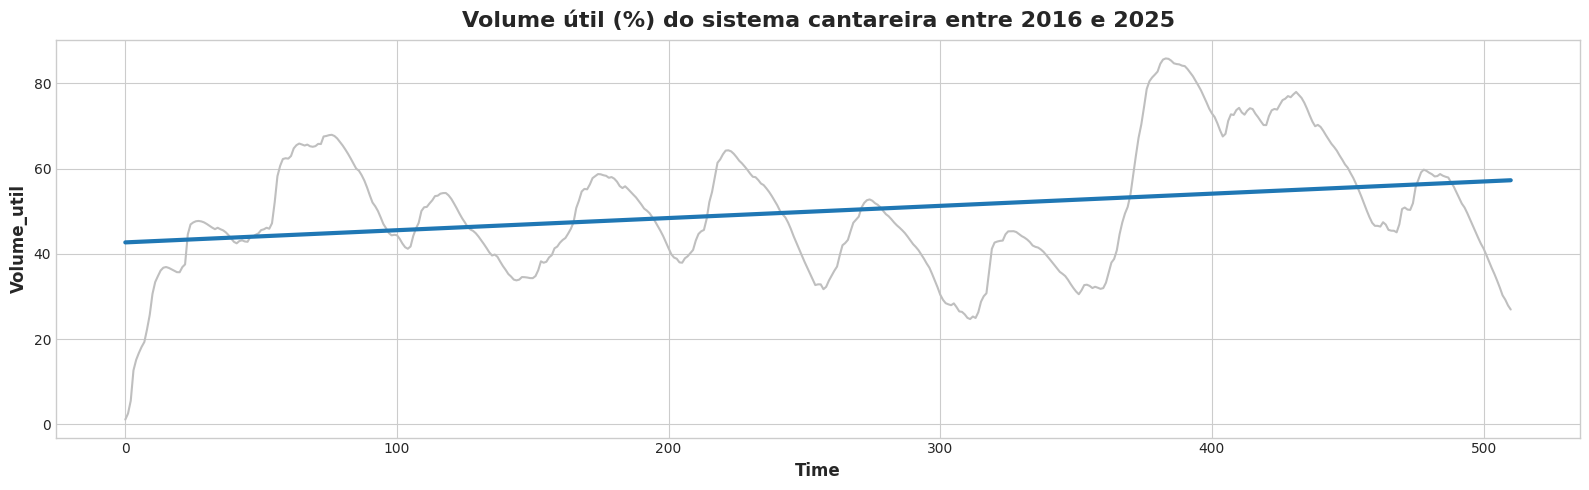

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rc(

    "figure",
    autolayout = True, 
    figsize = (11,4),
    titlesize = 18,
    titleweight = 'bold',

)

plt.rc(
    "axes",
    labelweight = 'bold',
    labelsize = "large",
    titleweight = "bold",
    titlesize = 16,
    titlepad = 10
    )

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(df_semanal['Time'], df_semanal['Volume_util'], data=df_semanal, color= '0.75')
ax.plot (df_semanal['Time'], df_semanal['y_pred'], color='tab:blue', linewidth=3, label='Regressão Linear', zorder=3)

ax.set_title('Volume útil (%) do sistema cantareira entre 2016 e 2025')
ax.set_xlabel('Time')
ax.set_ylabel('Volume_util')

#### Visualizando a tendência por médias móveis

<Axes: title={'center': 'Volume útil do sistema cantareira em médias móveis'}, xlabel='Data'>

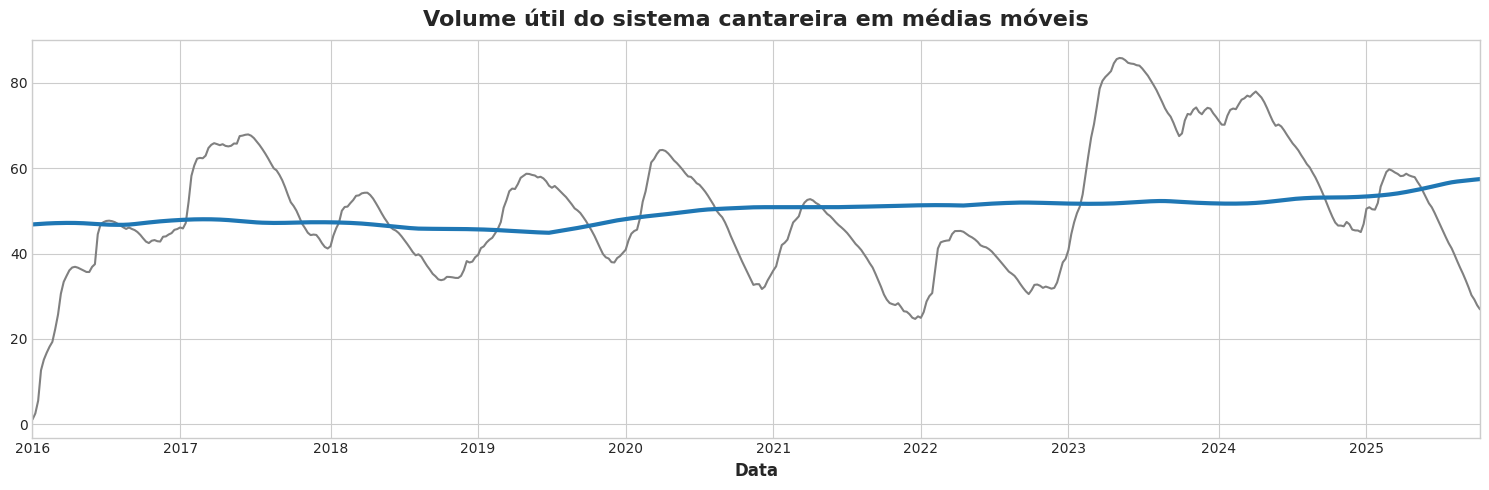

In [11]:
moving_average = df_semanal['Volume_util'].rolling(
    window = 365, 
    center = True, 
    min_periods = 182, 

).mean()

ax = df_semanal['Volume_util'].plot (style="-", color="0.5", figsize=(15,5))
moving_average.plot(
    ax=ax, linewidth=3, title = "Volume útil do sistema cantareira em médias móveis", legend=False
)

#### Tendência + Sazonalidade usando termos de Fourier 

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 5))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)

plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
    legend=False,
)

%config InlineBackend.figure_format = 'retina'

def seasonal_plot (X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors = X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )

    return ax 

def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs=pd.Timedelta("365D") / pd.Timedelta("1D")
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )

    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

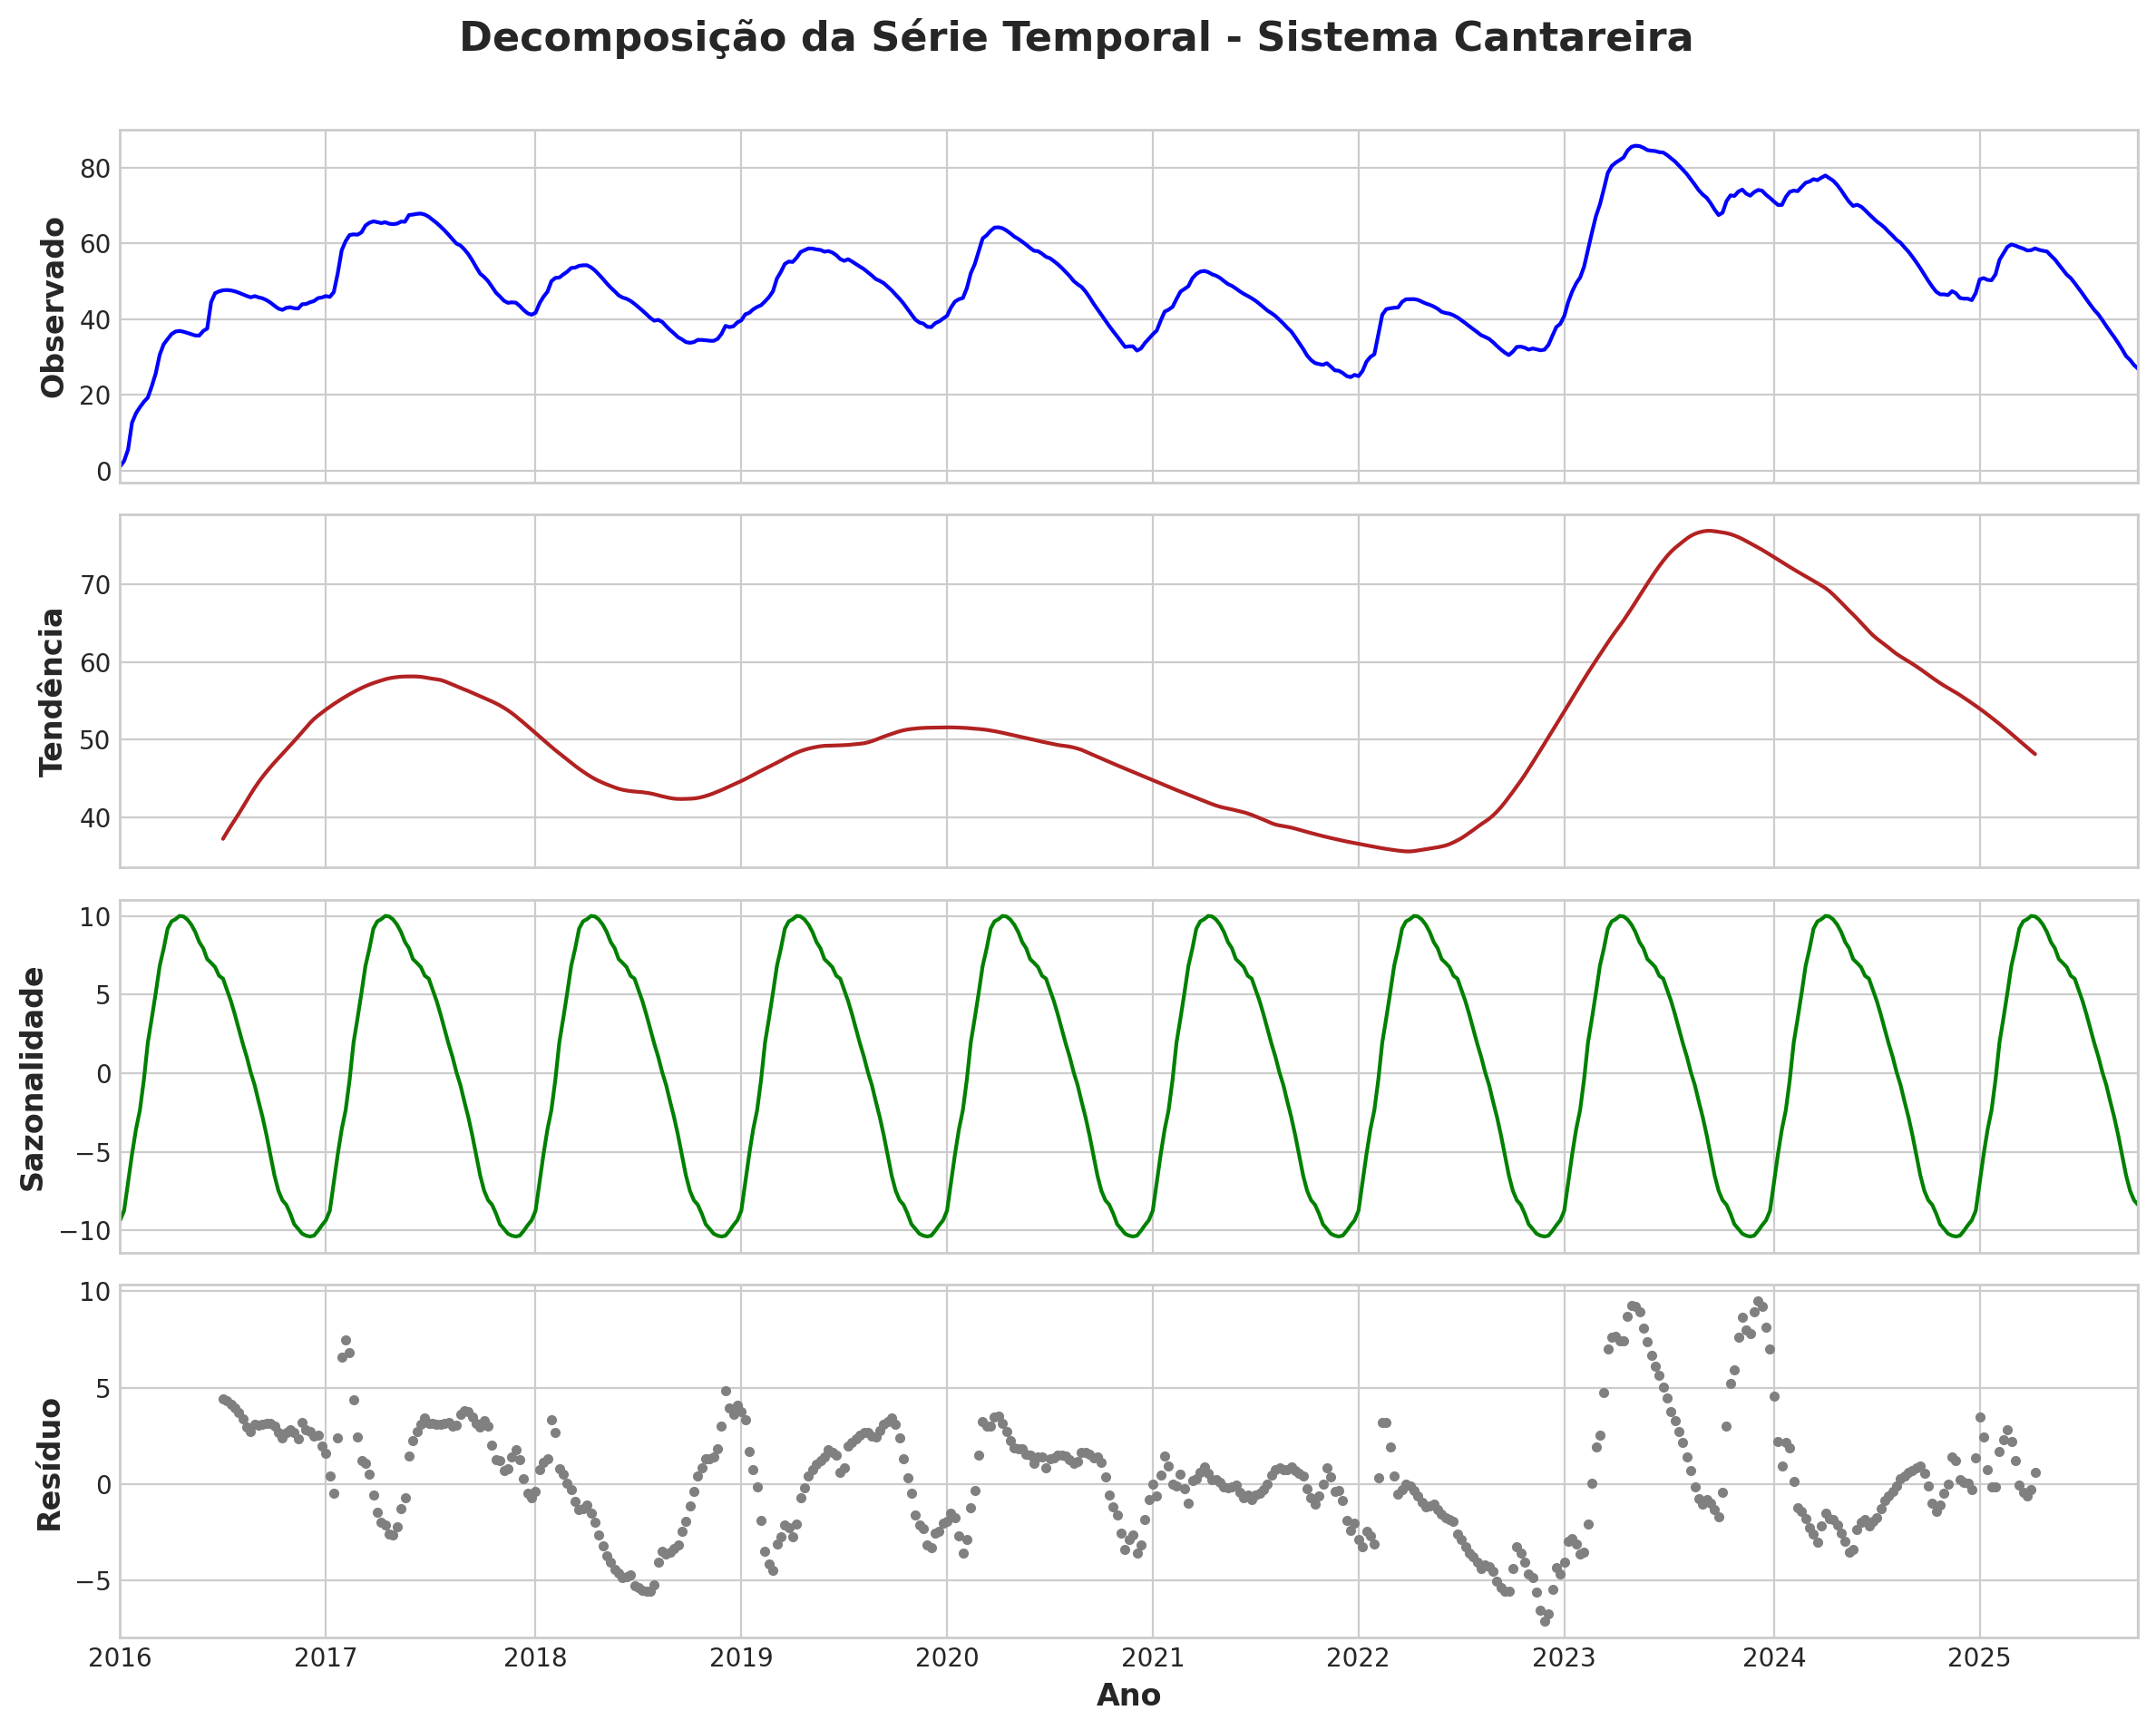

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(df_semanal['Volume_util'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

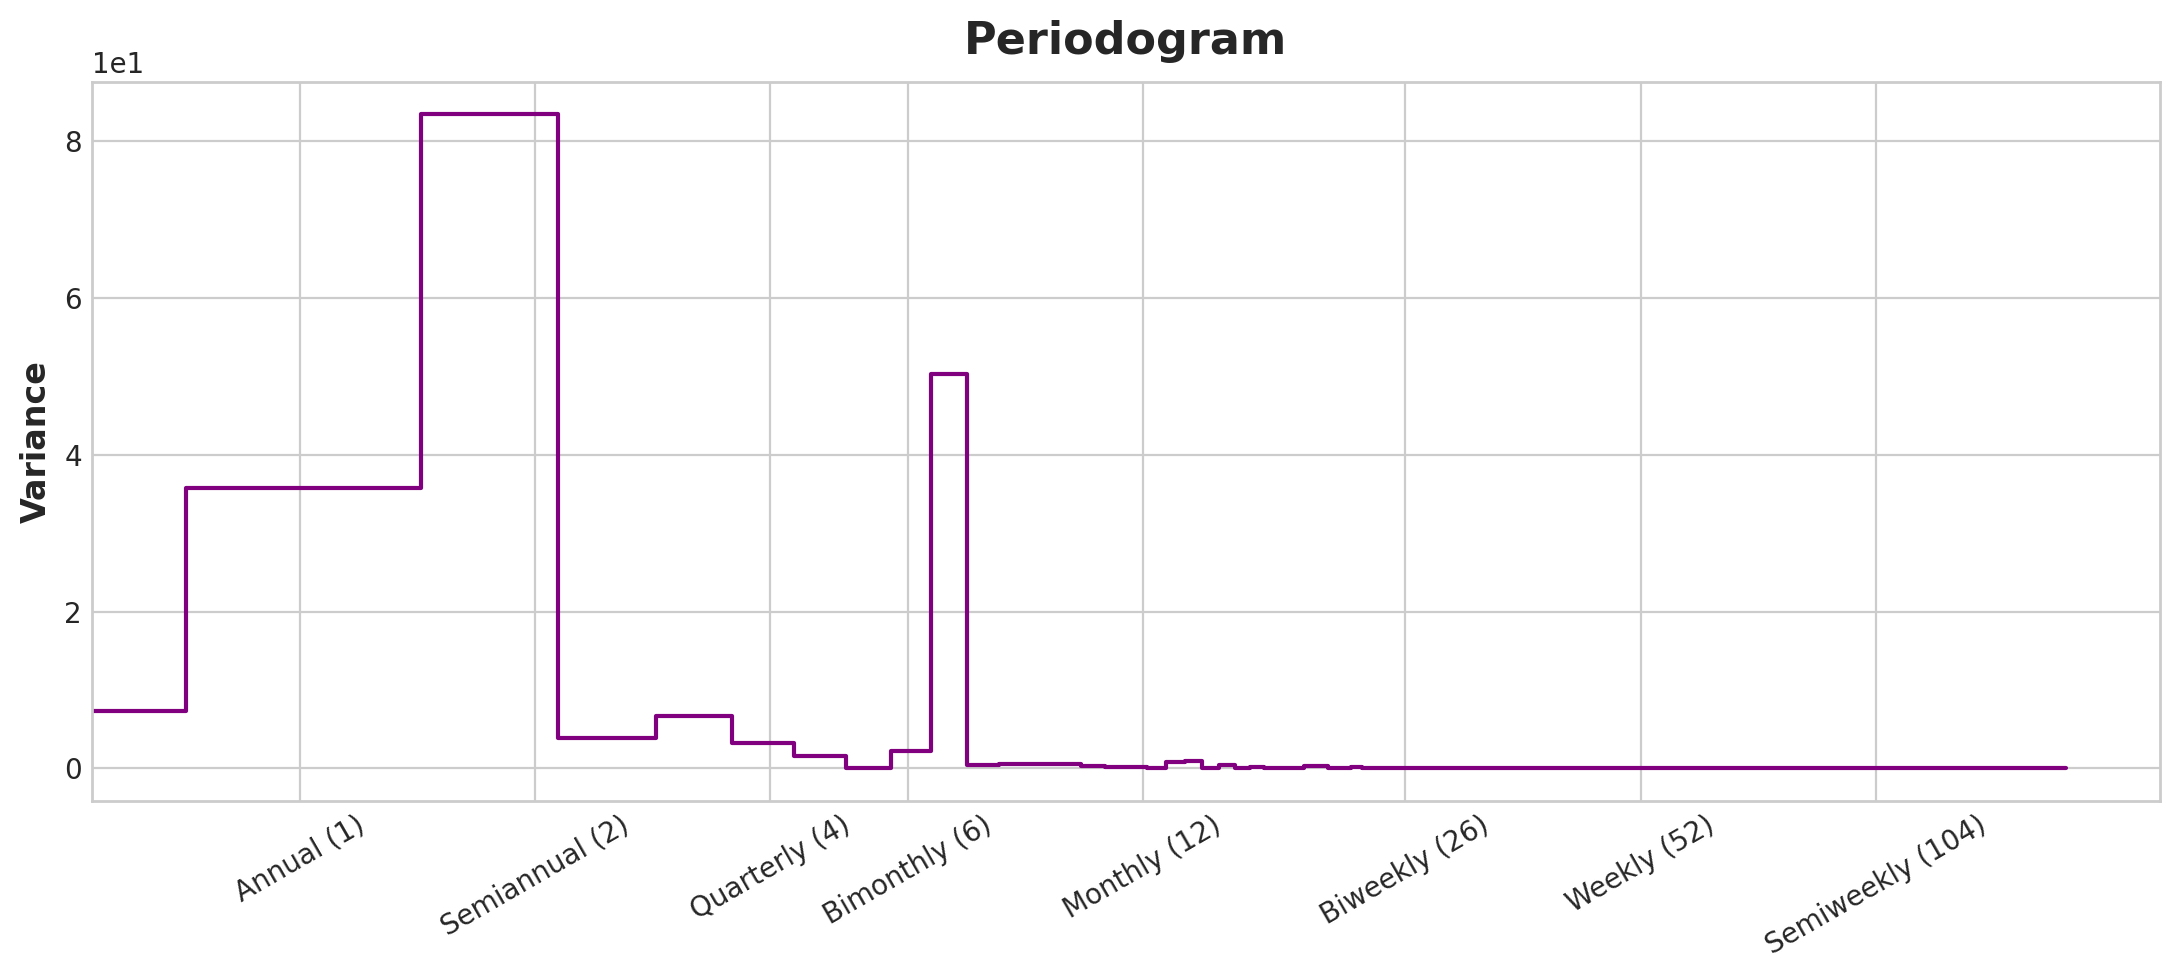

In [14]:
plot_periodogram(df_semanal.Volume_util);

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style="-.",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def lagplot(x, y=None, lag=1, standardize=False, ax=None, **kwargs):
    from matplotlib.offsetbox import AnchoredText
    x_ = x.shift(lag)
    if standardize:
        x_ = (x_ - x_.mean()) / x_.std()
    if y is not None:
        y_ = (y - y.mean()) / y.std() if standardize else y
    else:
        y_ = x
    corr = y_.corr(x_)
    if ax is None:
        fig, ax = plt.subplots()
    scatter_kws = dict(
        alpha=0.75,
        s=3,
    )
    line_kws = dict(color='C3', )
    ax = sns.regplot(x=x_,
                     y=y_,
                     scatter_kws=scatter_kws,
                     line_kws=line_kws,
                     lowess=True,
                     ax=ax,
                     **kwargs)
    at = AnchoredText(
        f"{corr:.2f}",
        prop=dict(size="large"),
        frameon=True,
        loc="upper left",
    )
    at.patch.set_boxstyle("square, pad=0.0")
    ax.add_artist(at)
    ax.set(title=f"Lag {lag}", xlabel=x_.name, ylabel=y_.name)
    return ax


def plot_lags(x, y=None, lags=6, nrows=1, lagplot_kwargs={}, **kwargs):
    import math
    kwargs.setdefault('nrows', nrows)
    kwargs.setdefault('ncols', math.ceil(lags / nrows))
    kwargs.setdefault('figsize', (kwargs['ncols'] * 2, nrows * 2 + 0.5))
    fig, axs = plt.subplots(sharex=True, sharey=True, squeeze=False, **kwargs)
    for ax, k in zip(fig.get_axes(), range(kwargs['nrows'] * kwargs['ncols'])):
        if k + 1 <= lags:
            ax = lagplot(x, y, lag=k + 1, ax=ax, **lagplot_kwargs)
            ax.set_title(f"Lag {k + 1}", fontdict=dict(fontsize=14))
            ax.set(xlabel="", ylabel="")
        else:
            ax.axis('off')
    plt.setp(axs[-1, :], xlabel=x.name)
    plt.setp(axs[:, 0], ylabel=y.name if y is not None else x.name)
    fig.tight_layout(w_pad=0.1, h_pad=0.1)
    return fig


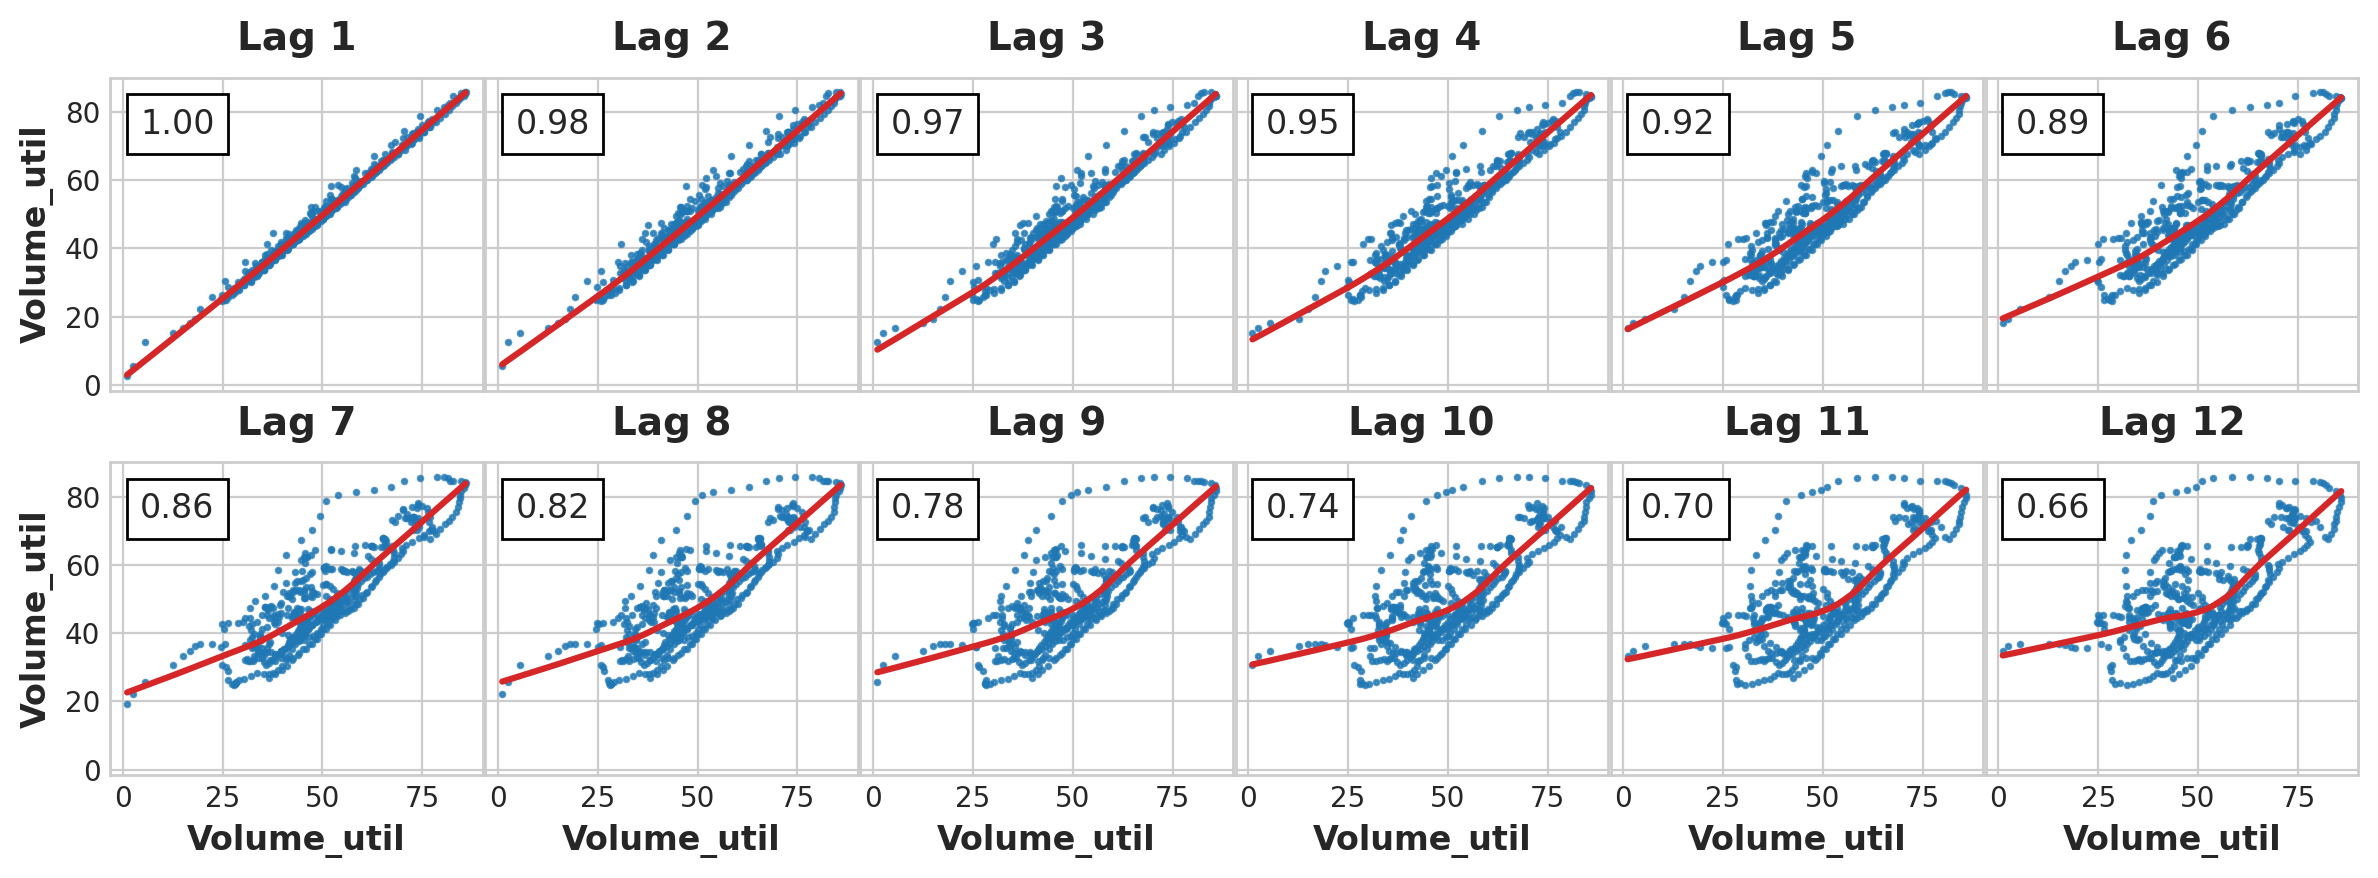

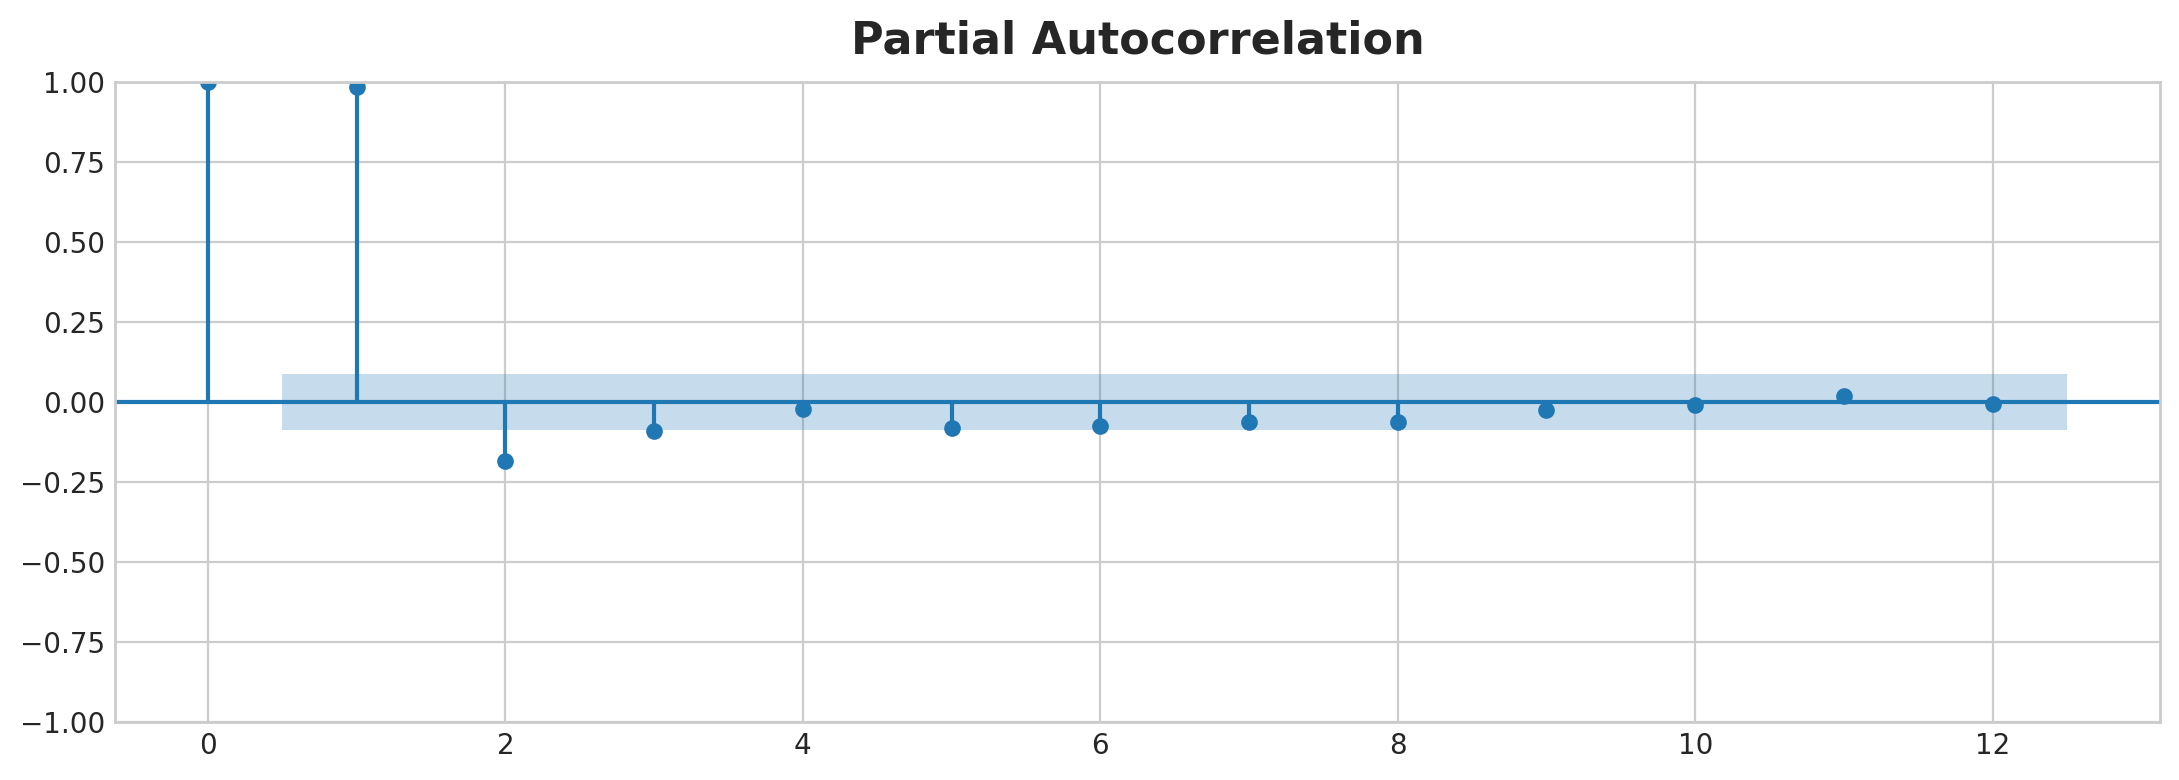

In [16]:
_ = plot_lags(df_semanal.Volume_util, lags=12, nrows=2)
_ = plot_pacf(df_semanal.Volume_util, lags=12)

#### Considerando apenas o periodo entre 2016 e 2023

#### Análise com a variável exógena de chuva

Através das análises de dados feitas até aqui, nóta-se um forte relação ciclica, causal entre a chuva e o volume útil do sistema cantareira, quando há periodos de chuva, sequentemente há periodos em que o volume do reservatório aumenta. Por isso, afim de tentar melhorar a previsão da volume que é nossa variável alvo, realizaremos a previsão da chuva

In [18]:
df.head()

,Data,Chuva (mm),Volume Útil Armazenado (%),Volume Útil Armazenado (hm³),Volume Total Armazenado (hm³),Vazão Captada (m³/s),Vazão Produzida (m³/s),Vazão Jusante (m³/s),Vazão Natural (m³/s),Vazão Afluente (m³/s),Variação do Volume Útil (%),Chuva Acumulada no Mês (mm),Chuva Média Historica (mm),Vazão Jusante no mês (m³/s),Vazão Jusante Média Histórica (m³/s),Vazão Natural no Mês (m³/s),Vazão Natural Media Historica (m³/s),Vazão Produzida no Mês (m³/s),Vazão Retirada no Mês (m³/s)
0,2000-01-01,"30,9","47,11254","365,50555","1072,05098","29,0",NaN,"10,16","70,885","70,885","0,32635","30,9","261,51618","10,16","22,55533","70,885",NaN,NaN,"29,0"
1,2000-01-02,"29,1","47,77519","370,64646","1077,1919","28,8",NaN,"10,18","94,864","94,864","0,66265","60,0","261,51618","10,17","22,55533","82,875",NaN,NaN,"28,9"
2,2000-01-03,"35,175","48,59438","377,00187","1083,5473","33,3",NaN,"7,29","108,208","108,208","0,81919","95,175","261,51618","9,21","22,55533","91,319",NaN,NaN,"30,36667"
3,2000-01-04,"18,725","49,9968","387,88206","1094,42749","32,4",NaN,"6,34","162,936","162,936","1,40242","113,9","261,51618","8,4925","22,55533","109,223",NaN,NaN,"30,875"
4,2000-01-05,"25,9","51,94578","403,00251","1109,54794","32,9",NaN,"6,33","211,604","211,604","1,94898","139,8","261,51618","8,06","22,55533","129,699",NaN,NaN,"31,28"


In [19]:
df_chuva = df[['Data', 'Chuva (mm)']].copy()
df_chuva = df_chuva.rename(columns= {'Chuva (mm)':'chuva'})
df_chuva['Data'] = pd.to_datetime(df_chuva['Data'])
df_chuva = df_chuva.set_index('Data')
df_chuva.head()

,chuva
Data,
2000-01-01,"30,9"
2000-01-02,"29,1"
2000-01-03,"35,175"
2000-01-04,"18,725"
2000-01-05,"25,9"


In [20]:
df_chuva['chuva'] = df_chuva['chuva'].str.strip()
df_chuva['chuva'] = df_chuva['chuva'].str.replace(',','.', regex=False)
df_chuva['chuva'] = pd.to_numeric(df_chuva['chuva'])

In [21]:
df_chuva['Time'] = np.arange(len(df_chuva.index))
df_chuva.head()

,chuva,Time
Data,,
2000-01-01,30.900,0
2000-01-02,29.100,1
2000-01-03,35.175,2
2000-01-04,18.725,3
2000-01-05,25.900,4


In [22]:
df_chuva = df_chuva.loc['2016-01-01':'2025-12-31'].copy()
df_semanal_chuva = df_chuva.resample('W').sum()

In [23]:
df_semanal_chuva['Time'] = np.arange(len(df_semanal_chuva.index))
df_semanal_chuva.head()

,chuva,Time
Data,,
2016-01-03,31.750,0
2016-01-10,19.825,1
2016-01-17,128.500,2
2016-01-24,0.575,3
2016-01-31,67.700,4


In [24]:
df_semanal_chuva2 = df_semanal_chuva.copy()

X_chuva = df_semanal_chuva2.loc[:, ['Time']]
y_chuva = df_semanal_chuva2.loc[:, ['chuva']]

model = LinearRegression()
model.fit(X_chuva,y_chuva)

y_pred = pd.Series(model.predict(X_chuva).flatten(), index=X.index)
df_semanal_chuva2['y_pred'] = y_pred

Text(0, 0.5, 'Chuva')

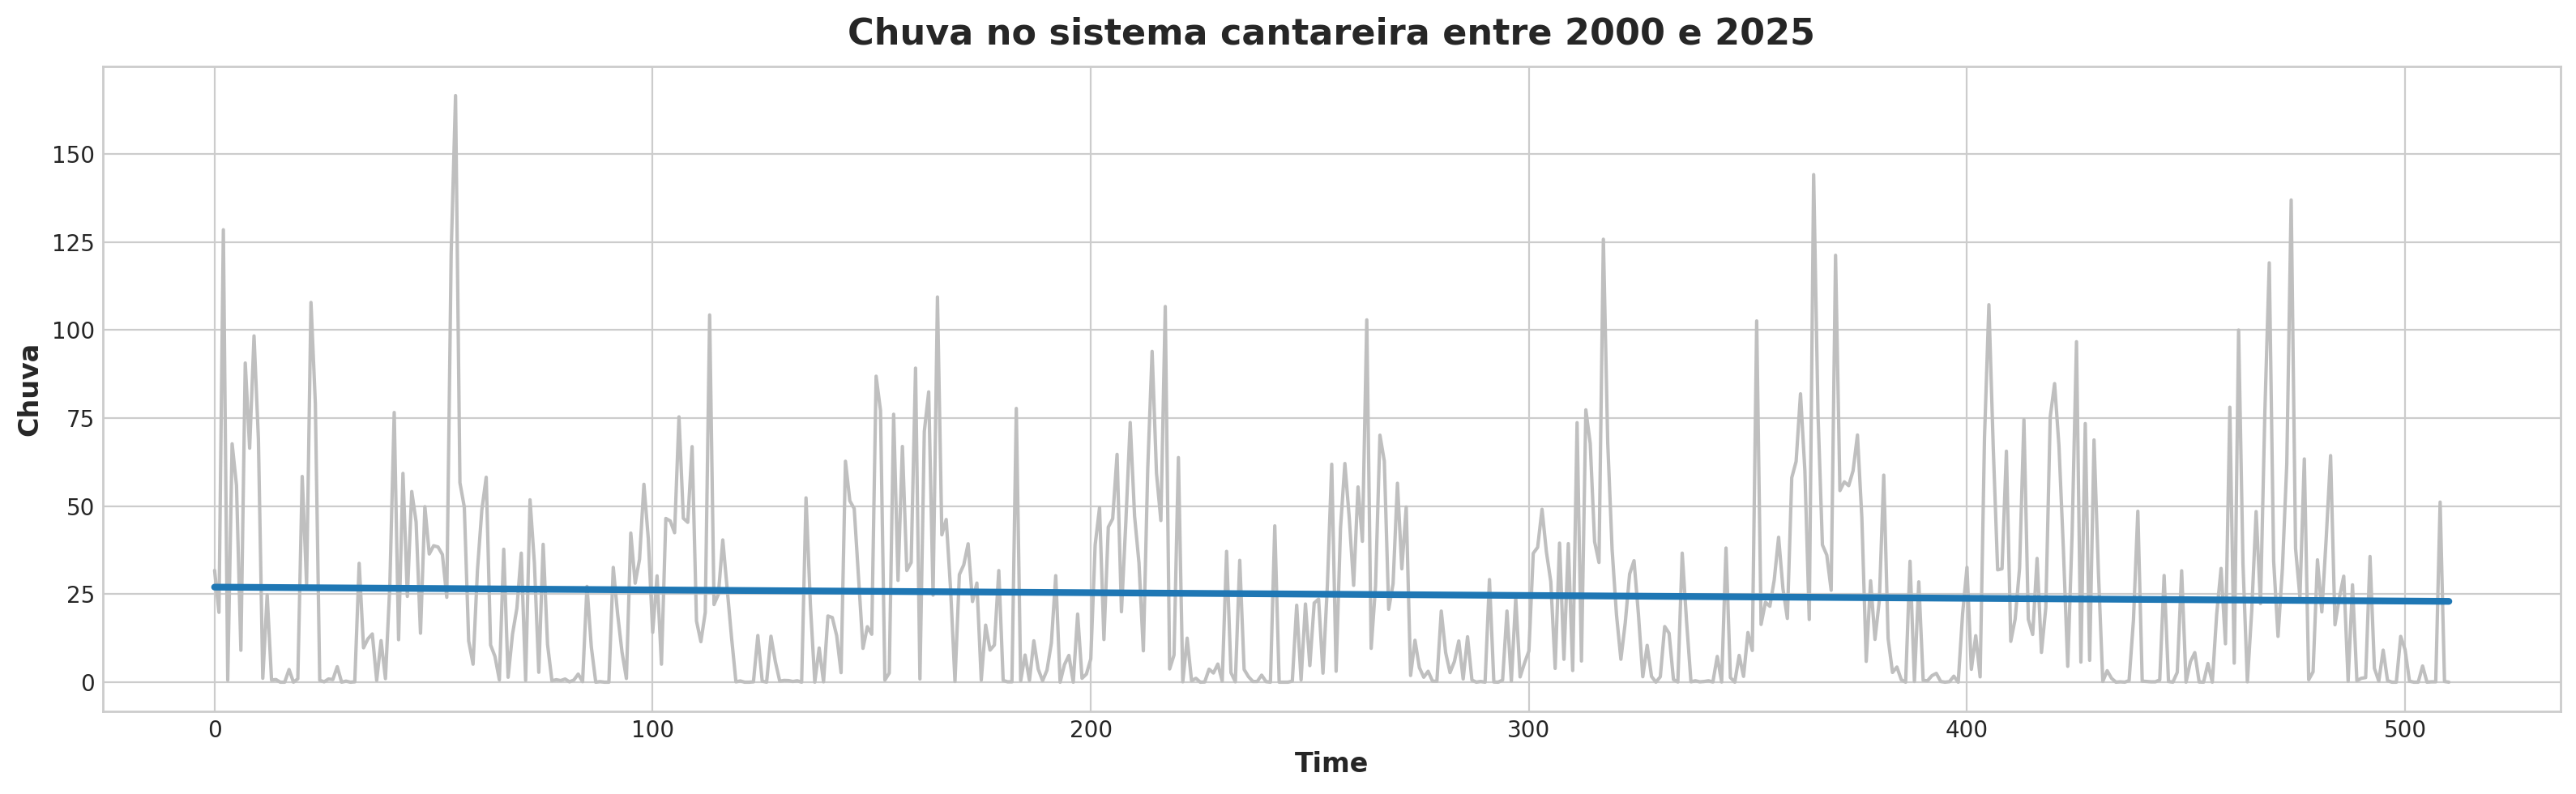

In [25]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rc(

    "figure",
    autolayout = True, 
    figsize = (11,4),
    titlesize = 18,
    titleweight = 'bold',

)

plt.rc(
    "axes",
    labelweight = 'bold',
    labelsize = "large",
    titleweight = "bold",
    titlesize = 16,
    titlepad = 10
    )

fig, ax = plt.subplots(figsize=(16,5))

ax.plot(df_semanal_chuva2['Time'], df_semanal_chuva2['chuva'], data=df_semanal, color= '0.75')
ax.plot (df_semanal_chuva2['Time'], df_semanal_chuva2['y_pred'], color='tab:blue', linewidth=3, label='Regressão Linear', zorder=3)

ax.set_title('Chuva no sistema cantareira entre 2000 e 2025')
ax.set_xlabel('Time')
ax.set_ylabel('Chuva')

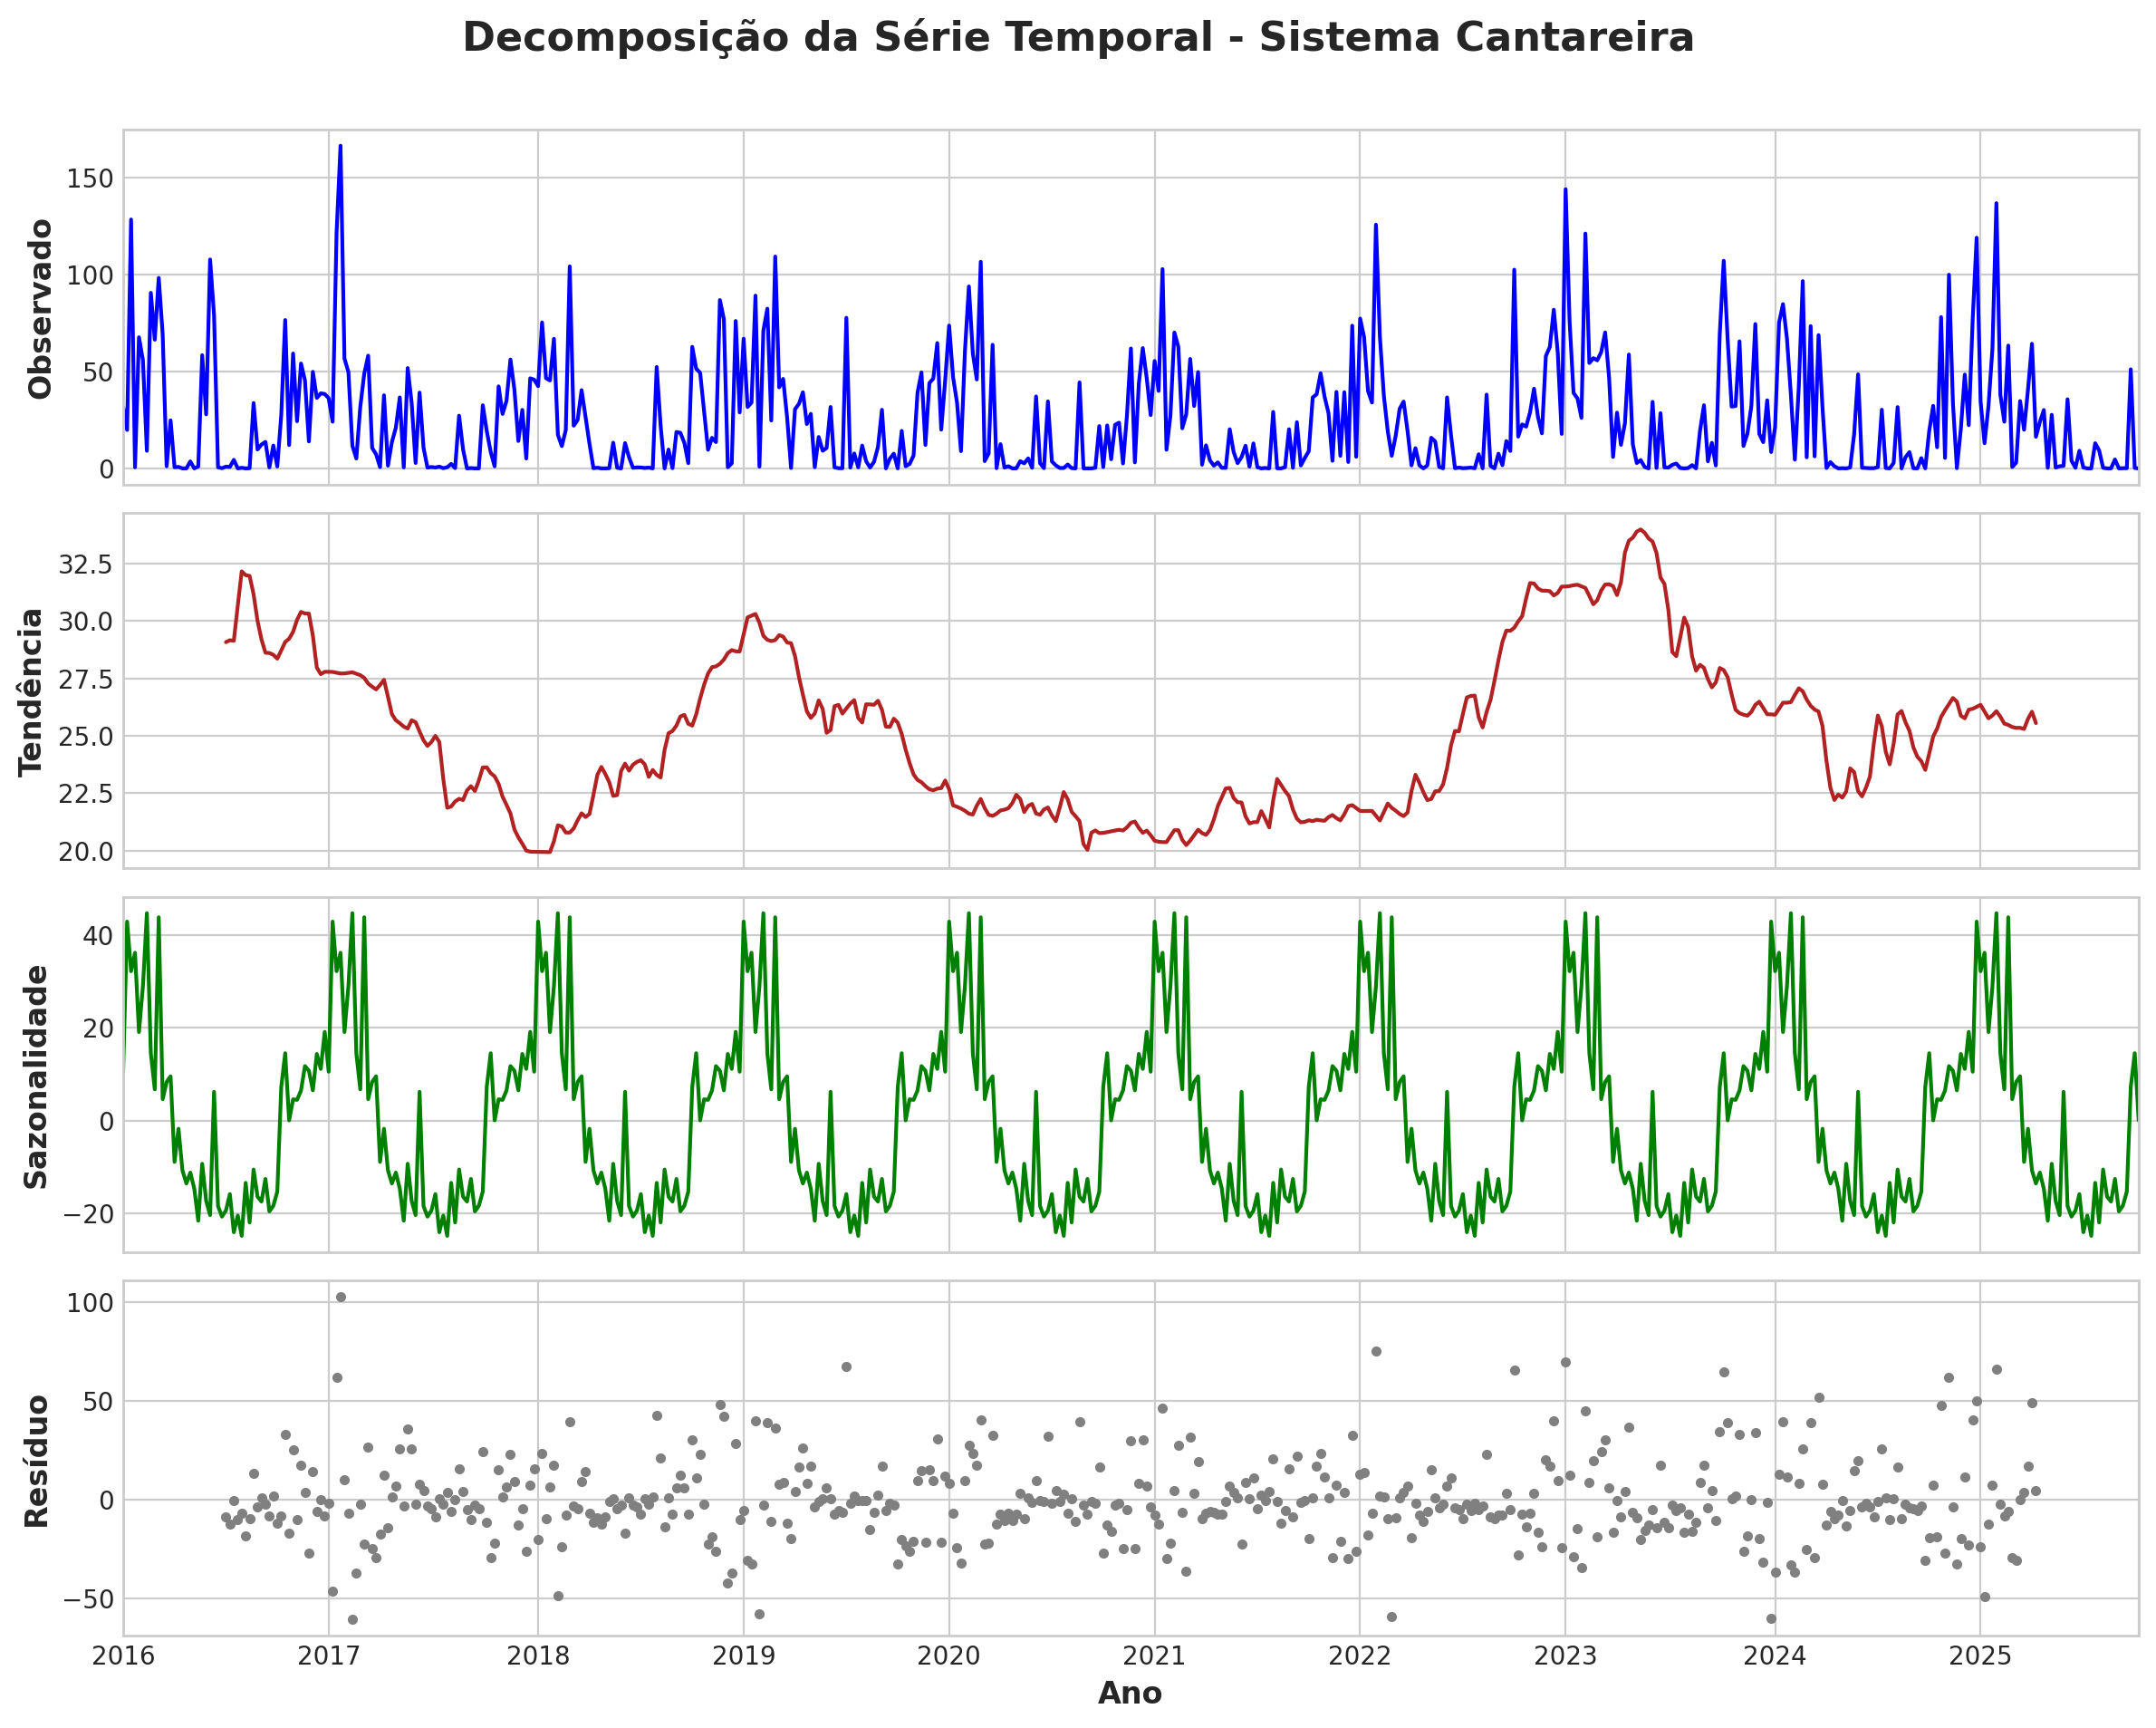

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposicao = seasonal_decompose(df_semanal_chuva['chuva'], model='additive', period=52)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))


decomposicao.observed.plot(ax=axes[0], color='blue', legend=False)
axes[0].set_ylabel('Observado')


decomposicao.trend.plot(ax=axes[1], color='firebrick', legend=False)
axes[1].set_ylabel('Tendência')


decomposicao.seasonal.plot(ax=axes[2], color='green', legend=False)
axes[2].set_ylabel('Sazonalidade')


decomposicao.resid.plot(ax=axes[3], color='gray', legend=False, style='.')
axes[3].set_ylabel('Resíduo')


fig.suptitle('Decomposição da Série Temporal - Sistema Cantareira', fontsize=16)
plt.xlabel('Ano')
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Ajusta o layout para o título principal não sobrepor os gráficos
plt.show()

/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  index = pd.date_range("2020-01-01", freq=freq, periods=1)


---------------------------------------------
   Avaliação do Modelo Híbrido Semanal com Chuva (2024-2025)
---------------------------------------------
MAE (Erro Médio Absoluto): 7.06
RMSE (Raiz do Erro Quadrático Médio): 9.98

Interpretação: Em média, as previsões semanais do modelo erraram em 7.06 pontos percentuais.
Para referência, o volume médio no período de teste foi de 56.64%.
---------------------------------------------


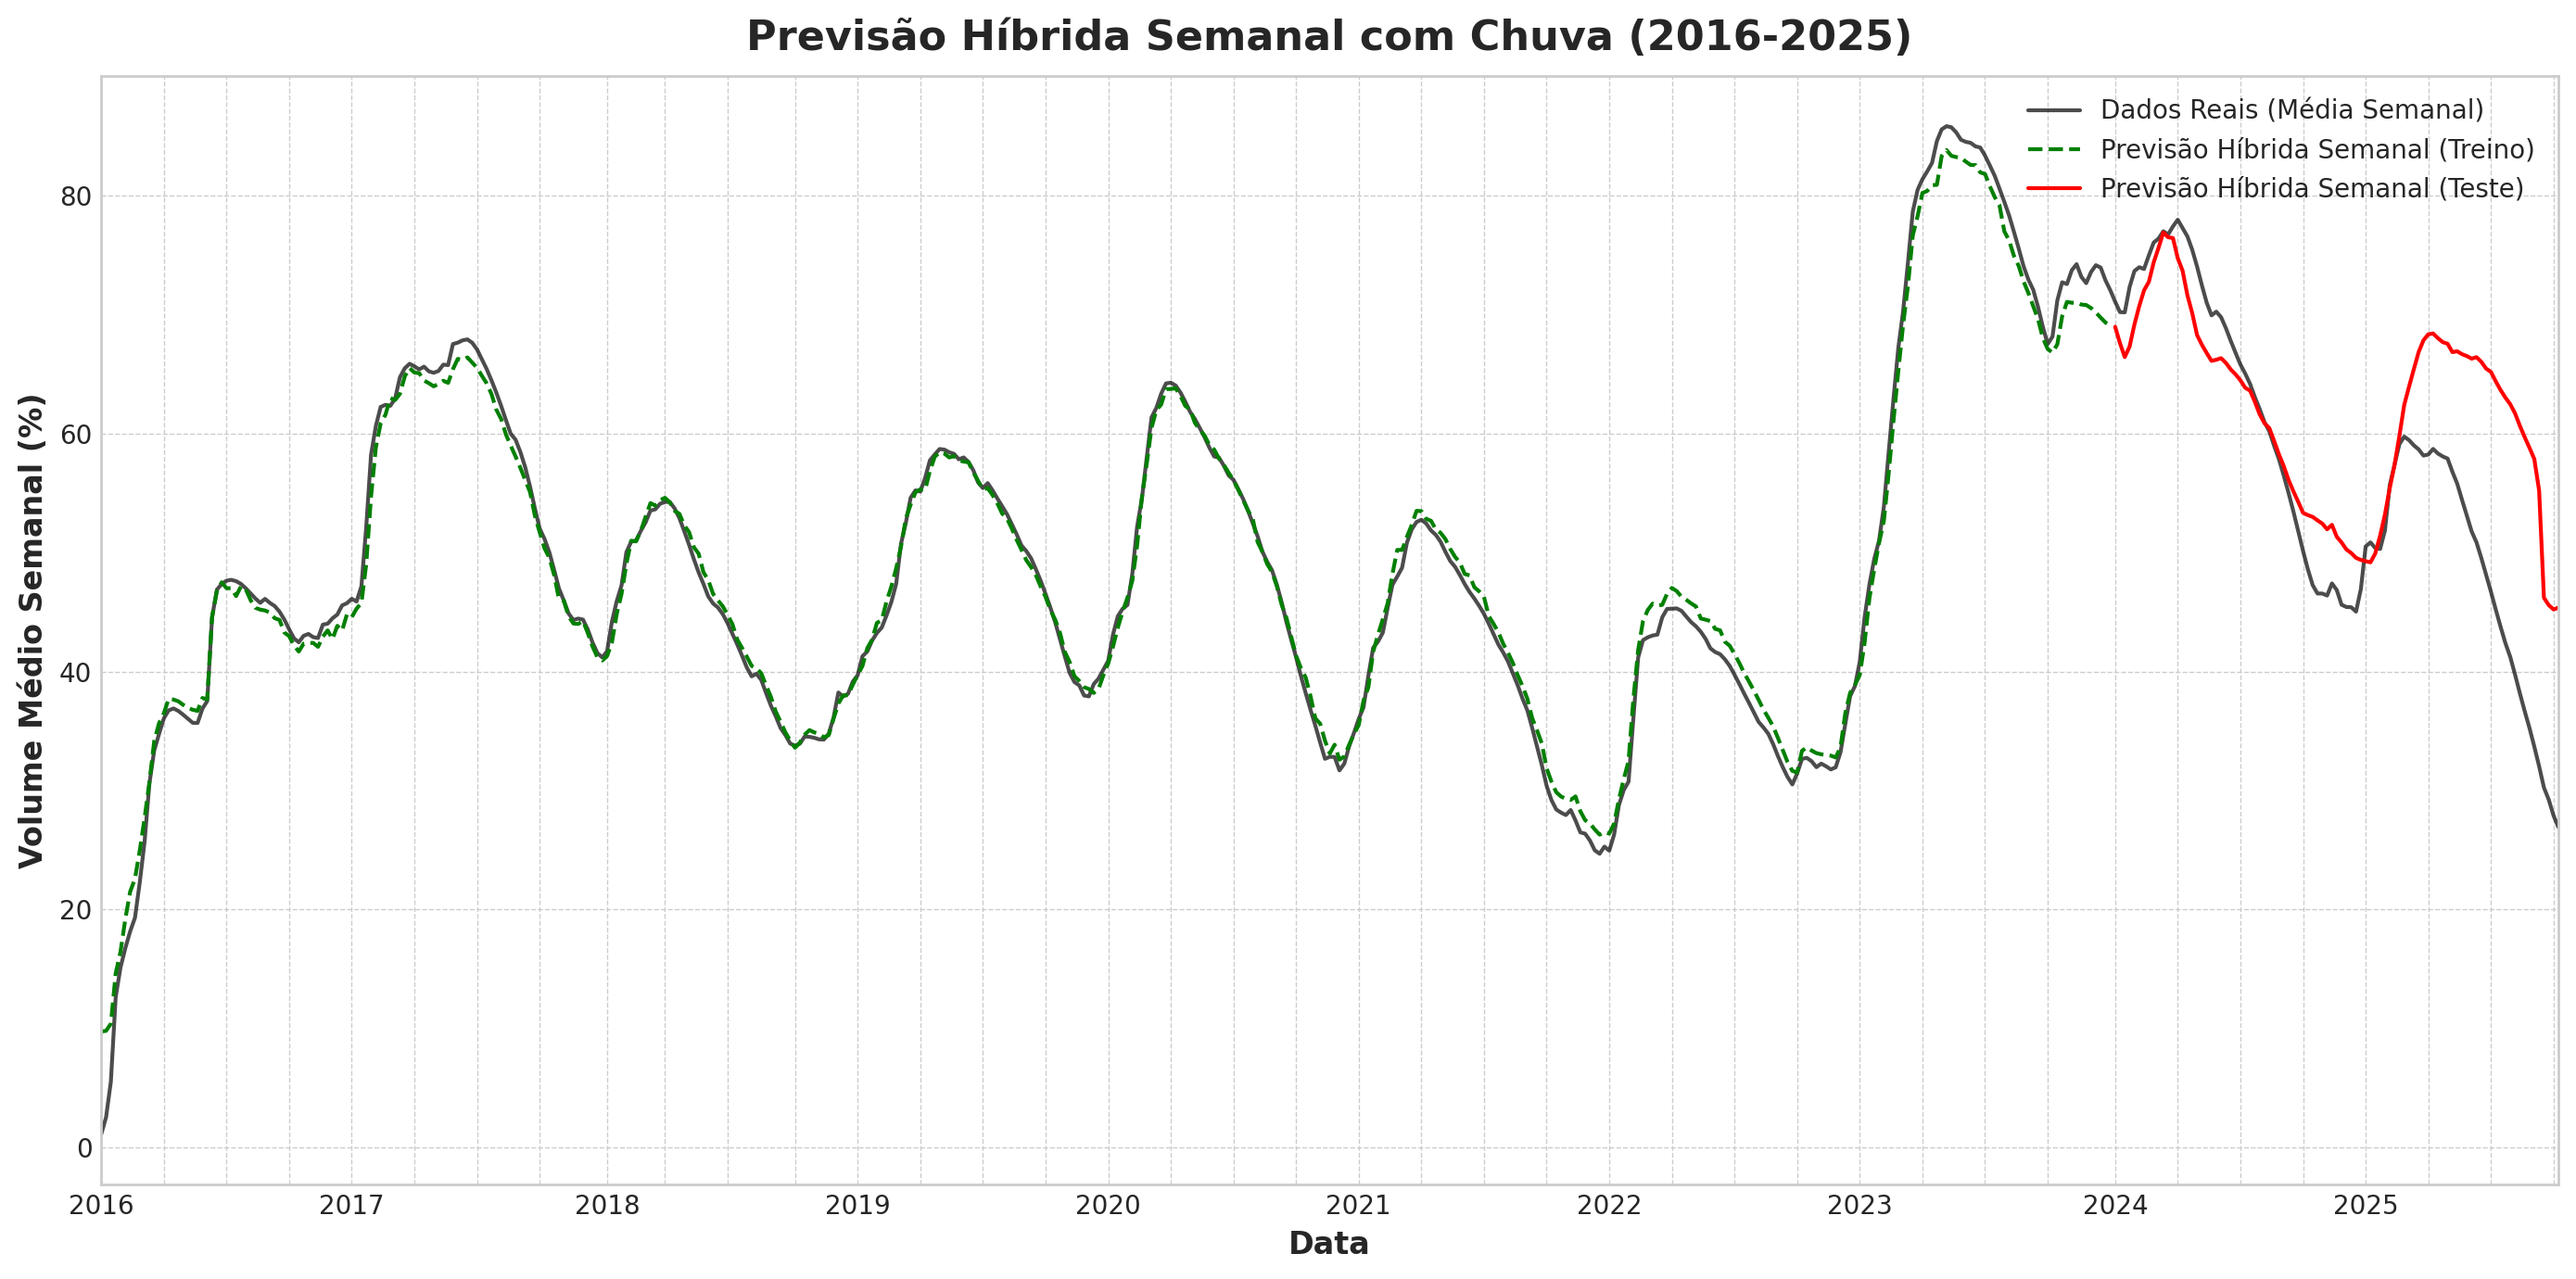

In [27]:
# --- 0. IMPORTAÇÕES E CONFIGURAÇÃO ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor

# --- 1. CARREGAMENTO, AGREGAÇÃO E ALINHAMENTO DE DADOS ---

# --- SUBSTITUA AQUI PELO CARREGAMENTO DOS SEUS DADOS ---
# Exemplo:
# dfv = pd.read_csv('seus_dados_de_volume.csv', parse_dates=['Date'], index_col='Date')
# df_chuva = pd.read_csv('seus_dados_de_chuva.csv', parse_dates=['Date'], index_col='Date')
# ---------------------------------------------------------

# Garantir a frequência diária antes de agregar
dfv = dfv.asfreq('D')
df_chuva = df_chuva.asfreq('D')

# Filtrar para o período de interesse (2016-2025)
df_periodo_vol = dfv.loc['2016-01-01':'2025-12-31'].copy()
df_periodo_chuva = df_chuva.loc['2016-01-01':'2025-12-31'].copy()

# Reamostrar para frequência semanal
# Volume: média da semana
df_semanal_volume = df_periodo_vol.resample('W').mean()
# Chuva: soma da semana
df_semanal_chuva = df_periodo_chuva.resample('W').sum()

# Juntar em um DataFrame final para garantir alinhamento
y1 = df_semanal_volume["Volume_util"].interpolate(method='linear')
chuva = df_semanal_chuva['chuva'].fillna(0.0)
df_final = pd.DataFrame({'Volume_util': y1, 'Chuva': chuva})


# --- 2. FEATURE ENGINEERING (MODELO 1: TENDÊNCIA E SAZONALIDADE) ---

fourier = CalendarFourier(freq="A", order=4)
dp = DeterministicProcess(
    index=df_final.index,
    constant=True,
    order=1,
    additional_terms=[fourier],
    drop=True,
)
x1 = dp.in_sample()


# --- 3. DIVISÃO EM DADOS DE TREINO E TESTE ---

split_date = '2024-01-01'

# Divisão para o Modelo 1
X_train = x1.loc[x1.index < split_date]
X_test = x1.loc[x1.index >= split_date]
y_train = df_final['Volume_util'].loc[df_final.index < split_date]
y_test = df_final['Volume_util'].loc[df_final.index >= split_date]


# --- 4. TREINAMENTO DO MODELO 1 E CÁLCULO DOS RESÍDUOS ---

model1 = LinearRegression()
model1.fit(X_train, y_train)

# Previsões da tendência e sazonalidade
y_pred_train = pd.Series(model1.predict(X_train), index=X_train.index)
y_pred_test = pd.Series(model1.predict(X_test), index=X_test.index)

# Cálculo dos resíduos
y_res_train = y_train - y_pred_train
y_res_test = y_test - y_pred_test
y_res = pd.concat([y_res_train, y_res_test])


# --- 5. FEATURE ENGINEERING (MODELO 2: RESÍDUOS E CHUVA) ---

def make_lags(ts, lags, name='y'):
    return pd.concat(
        {f'{name}_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

# Lags dos resíduos
x2_residuos = make_lags(y_res, lags=2, name='res')

# Lags da chuva (variável exógena)
x2_chuva = make_lags(df_final['Chuva'], lags=4, name='chuva')

# Combinar todas as features para o Modelo 2
x2_final = pd.concat([x2_residuos, x2_chuva], axis=1)
x2_final = x2_final.fillna(0.0)

# Divisão das features do Modelo 2
X2_train = x2_final.loc[x2_final.index < split_date]
X2_test = x2_final.loc[x2_final.index >= split_date]


# --- 6. TREINAMENTO E PREVISÃO DO MODELO 2 (XGBOOST) ---

model2 = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2.fit(X2_train, y_res_train)

# Previsão dos resíduos no conjunto de treino
y_pred_res_train = pd.Series(model2.predict(X2_train), index=X2_train.index)

# Previsão RECURSIVA para os resíduos no conjunto de teste
X2_test_recursive = X2_test.copy()
y_pred_res_test_list = []

for index in X2_test_recursive.index:
    features_hoje = X2_test_recursive.loc[[index]]
    pred_hoje = model2.predict(features_hoje)[0]
    y_pred_res_test_list.append(pred_hoje)

    try:
        proximo_index = X2_test_recursive.index[X2_test_recursive.index.get_loc(index) + 1]
        # Atualiza o lag de resíduo para o próximo passo com a PREVISÃO de hoje
        X2_test_recursive.loc[proximo_index, 'res_lag_1'] = pred_hoje
        if 'res_lag_2' in X2_test_recursive.columns:
            X2_test_recursive.loc[proximo_index, 'res_lag_2'] = features_hoje['res_lag_1'].values[0]
    except IndexError:
        break # Fim do loop

y_pred_res_test = pd.Series(y_pred_res_test_list, index=X2_test.index)


# --- 7. COMBINAÇÃO FINAL E AVALIAÇÃO DO MODELO ---

# Previsão Híbrida Final
y_final_train = y_pred_train + y_pred_res_train
y_final_test = y_pred_test + y_pred_res_test

# Métricas de Avaliação
mae = mean_absolute_error(y_test, y_final_test)
rmse = np.sqrt(mean_squared_error(y_test, y_final_test))

print("---" * 15)
print("   Avaliação do Modelo Híbrido Semanal com Chuva (2024-2025)")
print("---" * 15)
print(f"MAE (Erro Médio Absoluto): {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.2f}\n")
print(f"Interpretação: Em média, as previsões semanais do modelo erraram em {mae:.2f} pontos percentuais.")
print(f"Para referência, o volume médio no período de teste foi de {y_test.mean():.2f}%.")
print("---" * 15)


# --- 8. VISUALIZAÇÃO FINAL ---

fig, ax = plt.subplots(figsize=(14, 7))

df_final['Volume_util'].plot(ax=ax, color='black', alpha=0.7, style='-', label='Dados Reais (Média Semanal)')
y_final_train.plot(ax=ax, color='green', linestyle='--', label='Previsão Híbrida Semanal (Treino)')
y_final_test.plot(ax=ax, color='red', linestyle='-', label='Previsão Híbrida Semanal (Teste)')

ax.set_title('Previsão Híbrida Semanal com Chuva (2016-2025)')
ax.set_ylabel('Volume Médio Semanal (%)')
ax.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [28]:
df_semanal_chuva['Time'] = np.arange(len(df_semanal_chuva.index))
df_semanal_chuva

,chuva,Time
Data,,
2016-01-03,31.750,0
2016-01-10,19.825,1
2016-01-17,128.500,2
2016-01-24,0.575,3
2016-01-31,67.700,4
...,...,...
2025-09-14,0.100,506
2025-09-21,0.100,507
2025-09-28,51.150,508


In [40]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go  # <-- Importação necessária

# --- 1. Preparação dos Dados para Plotagem ---
# (Assumindo que 'df_semanal_chuva' já existe)
df_plot_interactive = df_semanal_chuva.copy()

# 1. Criar coluna 'Year' (como string)
df_plot_interactive['Year'] = df_plot_interactive.index.year.astype(str)

# 2. Criar coluna 'Week'
df_plot_interactive['Week'] = df_plot_interactive.index.isocalendar().week

# --- 2. CORREÇÃO DO PROBLEMA DA SEMANA 52 ---
# (Seu código de limpeza, que está perfeito, continua aqui)

# 1. Obter o número da semana da *primeira* entrada de cada ano
first_week_of_year = df_plot_interactive.groupby('Year')['Week'].first()

# 2. Identificar os anos "problemáticos"
problem_years = first_week_of_year[first_week_of_year > 50].index

# 3. Para cada ano problemático, removemos a primeira linha
for year in problem_years:
    first_row_index = df_plot_interactive[df_plot_interactive['Year'] == year].index[0]
    df_plot_interactive = df_plot_interactive.drop(first_row_index)
    
print("DataFrame corrigido (primeira semana de 2023 removida).")

# 4. Agora, podemos lidar com a semana 53 (rara) no final do ano
df_plot_interactive['Week'] = df_plot_interactive['Week'].replace(53, 52)

# --- 3. CALCULAR MÉTRICAS DE TENDÊNCIA CENTRAL ---
print("Calculando Média, Mediana e Moda por semana...")

# Agrupa o DataFrame limpo por semana
df_grouped_by_week = df_plot_interactive.groupby('Week')['chuva']

# O resultado será uma Série com a Semana (1-52) como índice
df_avg_data = df_grouped_by_week.mean()
df_median_data = df_grouped_by_week.median()
# Para a moda, pegamos o primeiro valor (mais comum), que provavelmente será 0
df_mode_data = df_grouped_by_week.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)


# --- 4. Criação do Gráfico Interativo (Corrigido) ---
print("\nGerando gráfico interativo com Média, Mediana e Moda...")

# 1. Usamos px.line para criar o gráfico base com as linhas dos anos
fig = px.line(
    df_plot_interactive,
    x='Week',
    y='chuva',
    color='Year',      # Cria uma linha por ano
    
    # Adiciona títulos e labels
    title='Sobreposição Sazonal da Chuva (com Métricas Centrais)',
    labels={
        "Week": "Semana do Ano",
        "chuva": "Chuva Acumulada Semanal (mm)",
        "Year": "Ano"
    },
    
    # Adiciona informações ao passar o mouse
    hover_name="Year",
    hover_data={"Week": True, "chuva": ":.2f"}
)

# --- 5. ADICIONAR OS TRAÇOS DE MÉTRICAS (COM CORES ATUALIZADAS) ---

# Adicionar Média Histórica (Preta, Pontilhada, Grossa)
fig.add_trace(
    go.Scatter(
        x=df_avg_data.index,
        y=df_avg_data.values,
        mode='lines',
        name='Média Histórica',
        line=dict(color='black', width=4, dash='dot') # Estilo base
    )
)

# Adicionar Mediana (Azul Escuro, Pontilhada, Grossa)
fig.add_trace(
    go.Scatter(
        x=df_median_data.index,
        y=df_median_data.values,
        mode='lines',
        name='Mediana',
        # --- COR E ESTILO ATUALIZADOS ---
        line=dict(color='darkred', width=4, dash='dot') 
    )
)

# Adicionar Moda (Verde Escuro, Pontilhada, Grossa)
fig.add_trace(
    go.Scatter(
        x=df_mode_data.index,
        y=df_mode_data.values,
        mode='lines',
        name='Moda',
        # --- COR E ESTILO ATUALIZADOS ---
        line=dict(color='darkgreen', width=4, dash='dot') 
    )
)

# --- 6. Finalizar e Mostrar o Gráfico (CORRIGIDO) ---

# 2. Melhora a aparência
fig.update_layout(
    template='plotly_white', 
    legend_title_text='Selecionar Ano'
)

# 3. Atualiza os traços para mostrar marcadores E linhas
#    Primeiro, aplicamos o modo "lines+markers" a TODOS os traços
fig.update_traces(
    mode="lines+markers"
)

#    AGORA, usamos o seletor corretamente para MUDAR DE VOLTA
#    APENAS os traços de métricas para não terem marcadores.
fig.update_traces(mode="lines", selector=dict(name='Média Histórica'))
fig.update_traces(mode="lines", selector=dict(name='Mediana'))
fig.update_traces(mode="lines", selector=dict(name='Moda'))

# Adiciona as linhas 'spikes' que seguem o mouse
fig.update_xaxes(showspikes=True)
fig.update_yaxes(showspikes=True)

# 4. Mostrar o gráfico
fig.show()

DataFrame corrigido (primeira semana de 2023 removida).
Calculando Média, Mediana e Moda por semana...

Gerando gráfico interativo com Média, Mediana e Moda...


In [41]:
import pandas as pd
import numpy as np

# --- 1. Preparação dos Dados (Aplicando a Correção da Semana) ---
# (Assumindo que 'df_semanal_chuva' já existe na memória)

print("Passo 1: Preparando e limpando dados para a tabela...")

# Copia para não alterar o original
df_pivot_source = df_semanal_chuva.copy()

# Cria as colunas 'Year' e 'Week'
df_pivot_source['Year'] = df_pivot_source.index.year.astype(str)
df_pivot_source['Week'] = df_pivot_source.index.isocalendar().week

# --- Aplica a mesma lógica de filtro que descobrimos para o gráfico ---
# Remove as semanas "órfãs" do início do ano (ex: Semana 52 em 1º de Jan)
first_week_of_year = df_pivot_source.groupby('Year')['Week'].first()
problem_years = first_week_of_year[first_week_of_year > 50].index

indices_to_drop = []
for year in problem_years:
    first_row_index = df_pivot_source[df_pivot_source['Year'] == year].index[0]
    indices_to_drop.append(first_row_index)

# Dataframe fonte limpo
df_pivot_source_clean = df_pivot_source.drop(indices_to_drop)

# Mapeia a semana 53 (rara) para a 52
df_pivot_source_clean['Week'] = df_pivot_source_clean['Week'].replace(53, 52)

print("Dados limpos e prontos para pivotar.")


# --- 2. Criação da Tabela Pivot ---
print("Passo 2: Criando a tabela comparativa...")

df_comparativo_semanal = pd.pivot_table(
    df_pivot_source_clean,
    index='Week',      # Linhas: Semanas (1 a 52)
    columns='Year',    # Colunas: Anos (2016, 2017, ...)
    values='chuva',    # Valores: A chuva acumulada
    aggfunc='mean'     # Usamos mean aqui, mas poderia ser 'first'
)

# --- 3. Adição das Métricas Históricas (Média, Mediana, Moda) ---
print("Passo 3: Calculando Média, Mediana e Moda por semana...")

# Média: axis=1 calcula a média ao longo das colunas (anos)
df_comparativo_semanal['Média_Histórica'] = df_comparativo_semanal.mean(axis=1)

# Mediana: Calculamos a partir dos dados limpos agrupados por semana
df_comparativo_semanal['Mediana_Histórica'] = df_pivot_source_clean.groupby('Week')['chuva'].median()

# Moda: Calculamos a partir dos dados limpos agrupados por semana
# Pegamos o primeiro valor (mais comum), que provavelmente será 0 em muitas semanas
# Usamos .reindex para garantir que o resultado tenha o mesmo índice (1-52) da tabela principal
weekly_mode = df_pivot_source_clean.groupby('Week')['chuva'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df_comparativo_semanal['Moda_Histórica'] = weekly_mode.reindex(df_comparativo_semanal.index)


# --- 4. Limpeza e Apresentação ---
# Preenche qualquer possível NaN com 0.0 (inclusive na moda)
# e arredonda para 2 casas decimais para facilitar a leitura.
df_comparativo_semanal_final = df_comparativo_semanal.fillna(0.0).round(2)

print("\n--- Tabela Comparativa Semanal com Métricas ---")
# Mostra a tabela completa (até 52 linhas)
print(df_comparativo_semanal_final.to_string()) # Usar to_string para garantir que mostre todas as linhas

Passo 1: Preparando e limpando dados para a tabela...
Dados limpos e prontos para pivotar.
Passo 2: Criando a tabela comparativa...
Passo 3: Calculando Média, Mediana e Moda por semana...

--- Tabela Comparativa Semanal com Métricas ---
Year    2016    2017    2018    2019    2020    2021    2022    2023    2024    2025  Média_Histórica  Mediana_Histórica  Moda_Histórica
Week                                                                                                                                    
1      19.82   24.10   42.45   66.95   73.75   40.00   67.80   75.90   21.25   34.45            46.65              41.22           19.82
2     128.50  121.78   75.35   31.70   47.10  102.90   39.90   39.00   75.30   13.00            67.45              61.20           13.00
3       0.57  166.60   46.55   34.00   33.90    9.60   34.00   36.10   84.80   32.30            47.84              34.00           34.00
4      67.70   56.65   45.40   89.20    8.90   27.30  125.80   26.10   67.00  

In [32]:

df_semanal['Time'] = np.arange(len(df_semanal.index))
df_semanal.head()

,Volume_util,Time,y_pred
Data,,,
2016-01-03,1.112363,0,42.677288
2016-01-10,2.530224,1,42.705878
2016-01-17,5.531559,2,42.734469
2016-01-24,12.642724,3,42.763059
2016-01-31,15.129069,4,42.791649


In [33]:
df_semanal_chuva

,chuva,Time
Data,,
2016-01-03,31.750,0
2016-01-10,19.825,1
2016-01-17,128.500,2
2016-01-24,0.575,3
2016-01-31,67.700,4
...,...,...
2025-09-14,0.100,506
2025-09-21,0.100,507
2025-09-28,51.150,508


Correlação entre Volume(t) e Lags de Chuva(t-k):
              Correlação
chuva_lag_1       -0.052
chuva_lag_2       -0.005
chuva_lag_3        0.033
chuva_lag_4        0.070
chuva_lag_5        0.098
chuva_lag_6        0.138
chuva_lag_7        0.170
chuva_lag_8        0.201
chuva_lag_9        0.229
chuva_lag_10       0.240
chuva_lag_11       0.266
chuva_lag_12       0.279


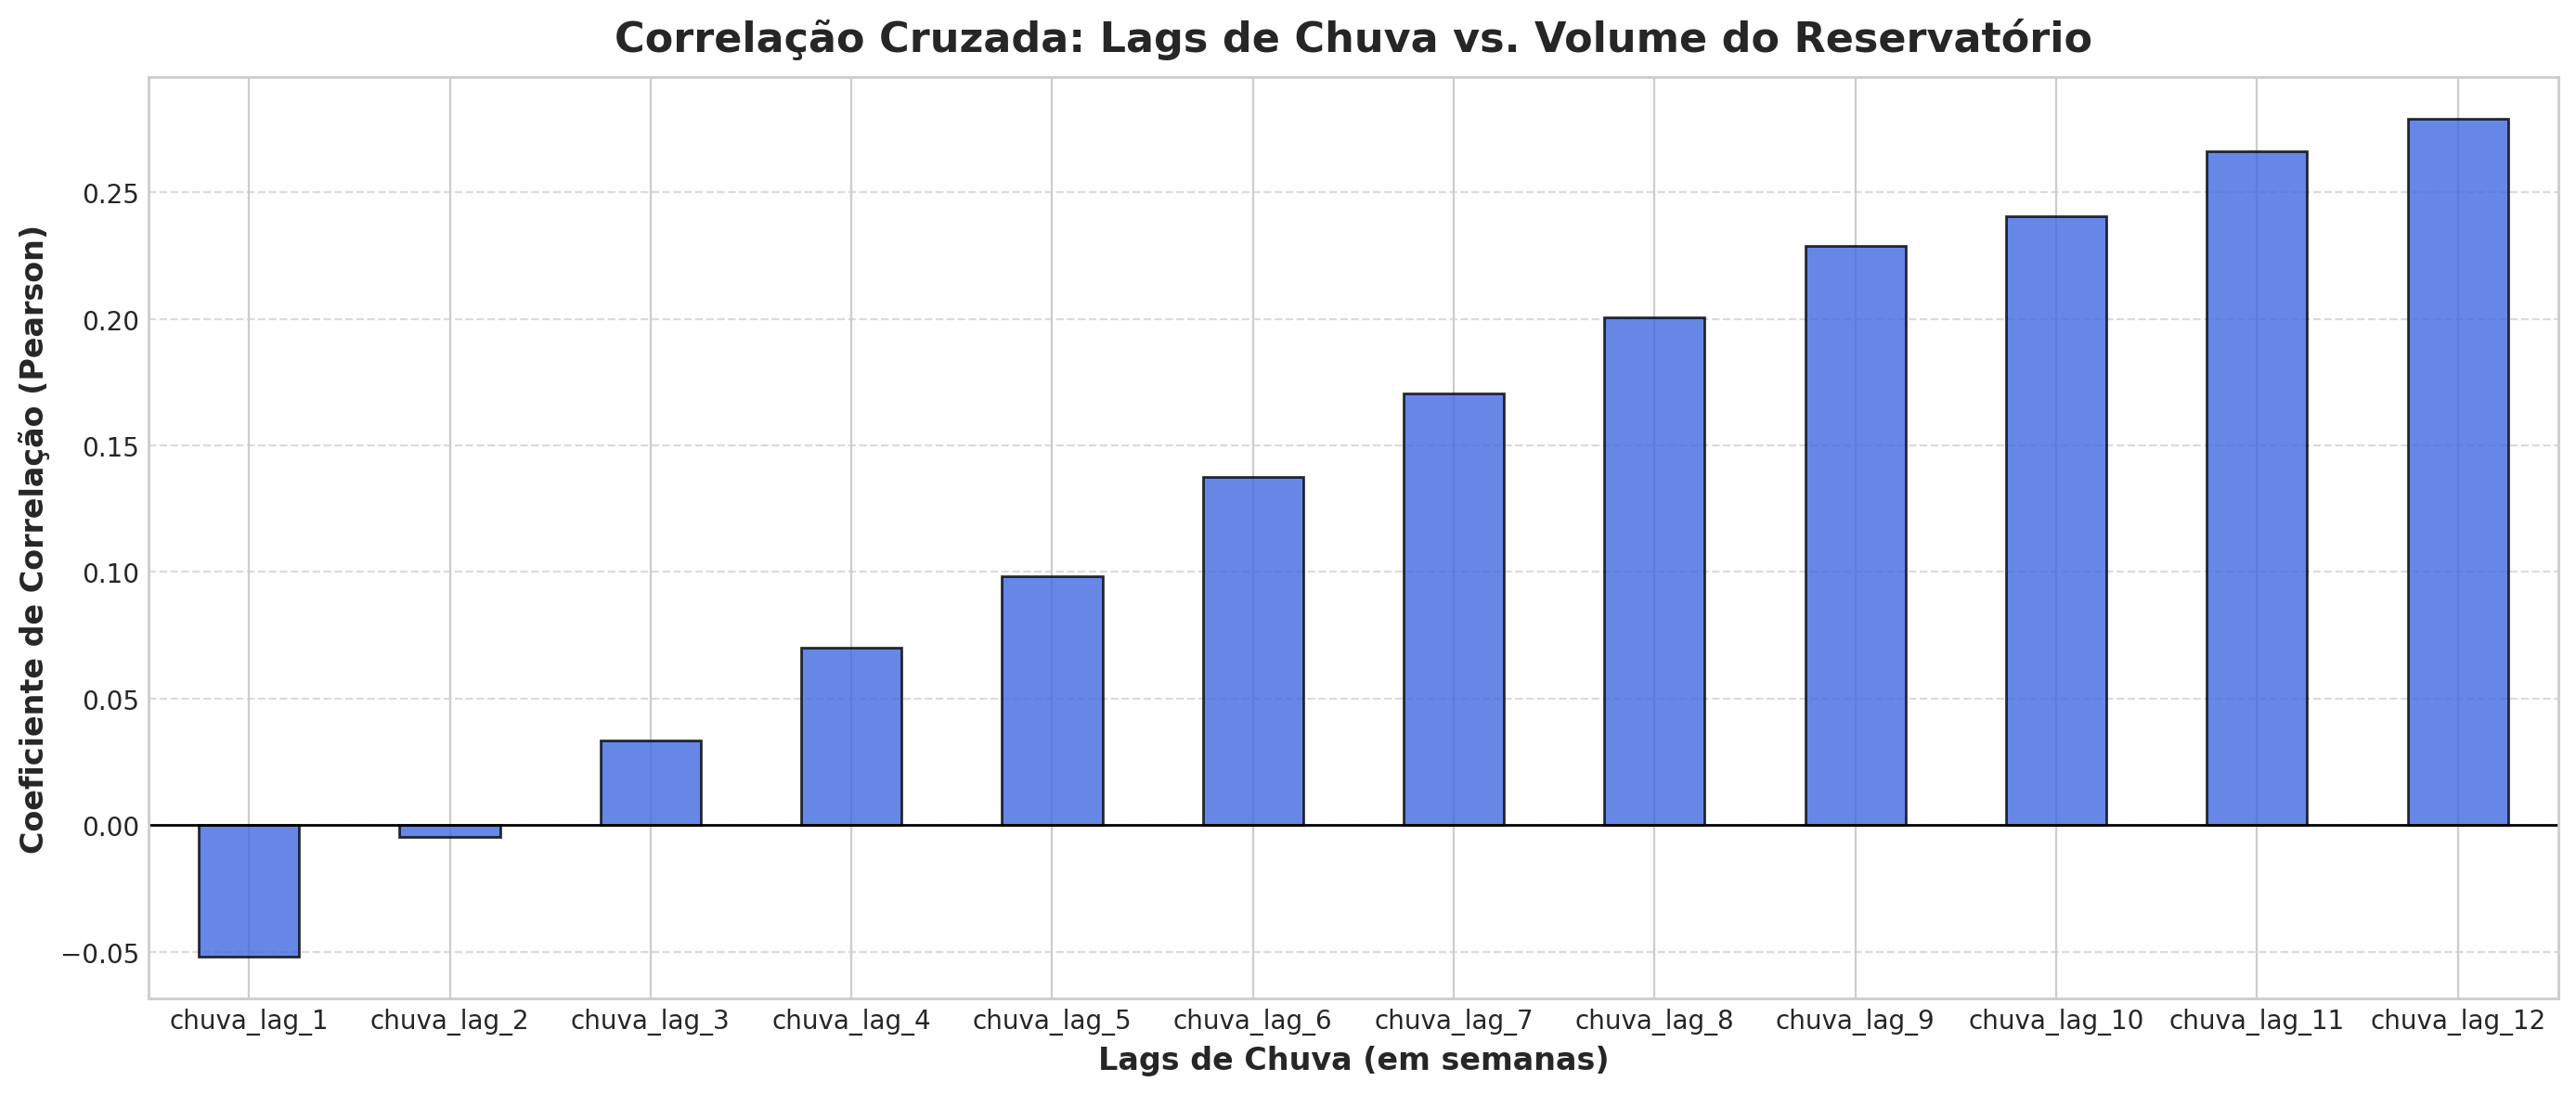

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Preparar o DataFrame para Análise de Correlação ---
# (Assumindo que 'df_final' existe e tem as colunas 'Volume_util' e 'Chuva')

# Vamos criar um DataFrame de análise focado apenas nos dados de TREINO.
# Isso evita que o período de teste "contamine" nossa análise de causalidade.
df_analise_correlacao = df_final.loc[df_final.index < split_date].copy()

# O número máximo de semanas que queremos testar o impacto
max_lags = 12 

# Criar colunas de lag para a chuva
for i in range(1, max_lags + 1):
    df_analise_correlacao[f'chuva_lag_{i}'] = df_analise_correlacao['Chuva'].shift(i)

# Remover os NaNs iniciais criados pelo shift
df_analise_correlacao = df_analise_correlacao.dropna()


# --- 2. Calcular as Correlações ---

# Calcula a matriz de correlação de todas as colunas
corr_matrix = df_analise_correlacao.corr()

# Extrai apenas a linha/coluna que nos interessa:
# a correlação de todas as 'chuva_lag_...' com o 'Volume_util'
corr_com_volume = corr_matrix.loc['Volume_util']

# Filtrar para manter apenas os lags de chuva (e remover o 'Volume_util' = 1.0)
corr_lags_chuva = corr_com_volume.filter(like='chuva_lag_')


# --- 3. Visualizar os Resultados ---

print("Correlação entre Volume(t) e Lags de Chuva(t-k):")
print(corr_lags_chuva.to_frame(name='Correlação').round(3))

# Plotar as correlações como um gráfico de barras
plt.figure(figsize=(14, 6))
ax = corr_lags_chuva.plot(
    kind='bar', 
    color='royalblue', 
    alpha=0.8,
    edgecolor='black'
)

ax.set_title('Correlação Cruzada: Lags de Chuva vs. Volume do Reservatório', fontsize=16)
ax.set_xlabel('Lags de Chuva (em semanas)', fontsize=12)
ax.set_ylabel('Coeficiente de Correlação (Pearson)', fontsize=12)
ax.axhline(0, color='black', linewidth=1) # Linha do zero
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0) # Mantém os nomes dos lags na horizontal
plt.show()

In [43]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots # <-- Precisamos disso para o eixo duplo

# --- 1. Preparar os Dados para Plotagem ---
# (Assumindo que 'df_final' já existe, limpo e com as colunas 'Volume_util' e 'Chuva')

# Filtra para o período de histórico que você pediu (2016-2023)
# Usamos .loc para ser explícito
df_plot_dual = df_final.loc['2016-01-01':'2023-12-31'].copy()

print("Dados de 2016-2023 prontos para plotagem.")

# --- 2. Criar o Gráfico Interativo de Eixo Duplo ---
print("Gerando gráfico interativo...")

# 1. Criar uma figura que suporta um eixo Y secundário
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 2. Adicionar o traço do VOLUME (Eixo Y Primário - Esquerda)
fig.add_trace(
    go.Scatter(
        x=df_plot_dual.index,
        y=df_plot_dual['Volume_util'],
        name='Volume do Reservatório (%)', # Nome na legenda
        mode='lines',
        line=dict(color='royalblue', width=3) # Linha azul e mais grossa
    ),
    secondary_y=False, # <-- Dizendo que este é o eixo primário
)

# 3. Adicionar o traço da CHUVA (Eixo Y Secundário - Direita)
fig.add_trace(
    go.Scatter(
        x=df_plot_dual.index,
        y=df_plot_dual['Chuva'],
        name='Chuva Semanal (mm)', # Nome na legenda
        mode='lines',
        line=dict(color='gray', width=1.5, dash='dot') # Linha cinza, fina e pontilhada
    ),
    secondary_y=True, # <-- Dizendo que este é o eixo secundário
)

# --- 3. Configurar Títulos e Layout ---

# Adicionar título principal e títulos dos eixos
fig.update_layout(
    title_text='Volume do Reservatório vs. Chuva Semanal (2016-2023)',
    template='plotly_white'
)

# Configurar o eixo Y da esquerda (Volume)
fig.update_yaxes(
    title_text="<b>Volume do Reservatório (%)</b>", 
    color='royalblue',
    secondary_y=False
)

# Configurar o eixo Y da direita (Chuva)
fig.update_yaxes(
    title_text="<b>Chuva Semanal (mm)</b>", 
    color='gray',
    secondary_y=True
)

# Configurar o eixo X (Data)
fig.update_xaxes(title_text="Data (Semanas)")

# 4. Mostrar o gráfico
fig.show()

Dados de 2016-2023 prontos para plotagem.
Gerando gráfico interativo...


Passo 1: Preparando dados base (Volume e Chuva Real)...
Passo 2: Criando cenário de chuva da 'Média Histórica'...
Cenário de chuva média concluído.

--- Início do Experimento 6: Modelo Híbrido com Chuva Média ---
Passo 3: Treinando Modelo 1 (Regressão Linear)...
Passo 4: Treinando Modelo 2 (XGBoost nos Resíduos)...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Passo 5: Executando loop de previsão recursiva...
Passo 6: Calculando resultados finais...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido com Chuva Média (Experimento 6)
---------------------------------------------
MAE (Erro Médio Absoluto): 8.06
RMSE (Raiz do Erro Quadrático Médio): 11.59
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


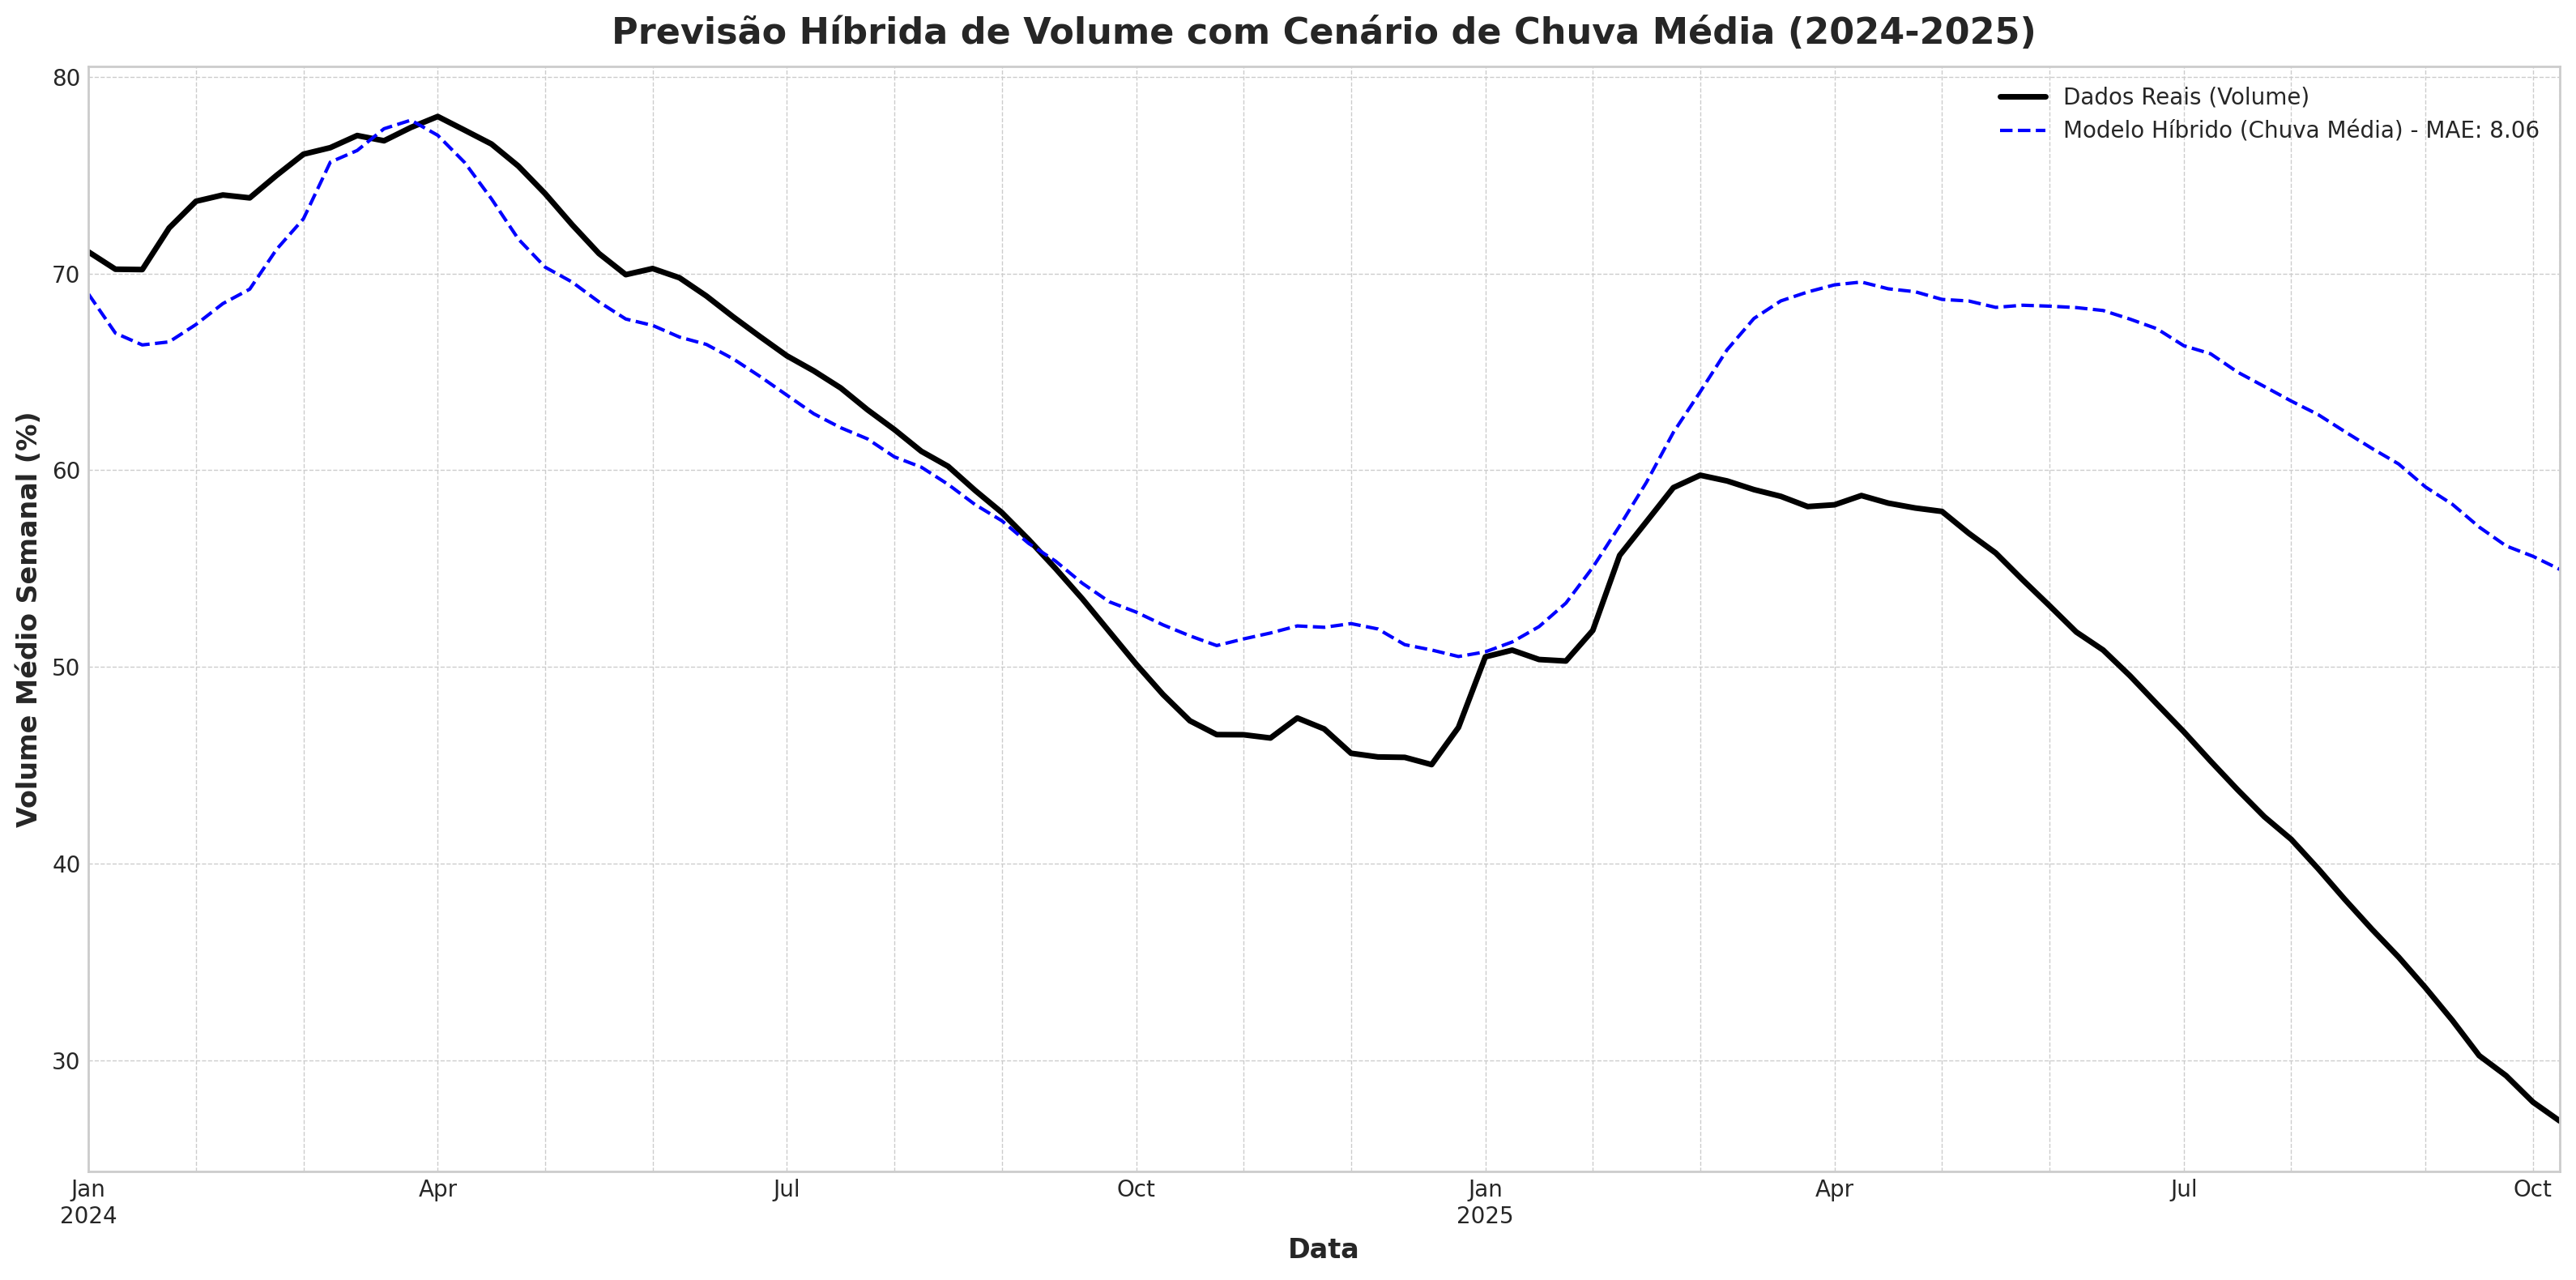

--- Fim do Experimento 6 ---


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---
# (Esta função é comum e não precisa de sufixo)
def make_lags(ts, lags, name='y'):
    """Cria colunas de lag para uma série temporal."""
    return pd.concat(
        {f'{name}_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base (Volume e Chuva Real)...")

# (Assumindo que dfv e df_chuva estão carregados e limpos)
# Filtra período
df_periodo_vol = dfv.loc['2016-01-01':'2025-12-31'].copy()
df_periodo_chuva = df_chuva.loc['2016-01-01':'2025-12-31'].copy()

# Reamostragem para dados semanais
df_semanal_volume = df_periodo_vol.resample('W').mean()
df_semanal_chuva = df_periodo_chuva.resample('W').sum()

# DataFrame final com DADOS REAIS
df_final = pd.DataFrame({
    'Volume_util': df_semanal_volume["Volume_util"].interpolate(method='linear'),
    'Chuva': df_semanal_chuva['chuva'].fillna(0.0)
})

# Datas de corte e dados reais de teste (comuns a todos)
split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']
# (Vamos definir os target_cols aqui para o passo 2)
target_cols = ['chuva_t+1', 'chuva_t+2', 'chuva_t+3', 'chuva_t+4', 'chuva_t+5', 
              'chuva_t+6', 'chuva_t+7', 'chuva_t+8', 'chuva_t+9', 'chuva_t+10', 
              'chuva_t+11', 'chuva_t+12']


# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MÉDIA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva da 'Média Histórica'...")

# 1. Calcular a média histórica da chuva
df_train = df_final.loc[df_final.index < split_date].copy()
df_train['week_of_year'] = df_train.index.isocalendar().week
seasonal_avg_rain = df_train.groupby('week_of_year')['Chuva'].mean()
if 53 in seasonal_avg_rain.index and 52 in seasonal_avg_rain.index:
    seasonal_avg_rain[53] = seasonal_avg_rain[52]

# 2. Criar DataFrame de previsões da média (agora até 12 semanas)
df_chuva_forecasts_avg = pd.DataFrame(index=test_index, columns=target_cols)

for t in test_index:
    for i in range(1, 13): # <-- ATUALIZADO para 12 semanas
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        avg_value = seasonal_avg_rain.get(future_week if future_week != 53 else 52, df_train['Chuva'].mean())
        df_chuva_forecasts_avg.loc[t, f'chuva_t+{i}'] = avg_value

df_chuva_forecasts_avg = df_chuva_forecasts_avg.astype(float)
print("Cenário de chuva média concluído.")


# --- 3. MODELO 1 (LR): PREVISÃO DA TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 6: Modelo Híbrido com Chuva Média ---")
print("Passo 3: Treinando Modelo 1 (Regressão Linear)...")

y1_vol_hybrid_avg = df_final['Volume_util']
real_rain_hybrid_avg = df_final['Chuva']

dp_vol_hybrid_avg = DeterministicProcess(
    index=y1_vol_hybrid_avg.index,
    constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)],
    drop=True
)
x1_vol_hybrid_avg = dp_vol_hybrid_avg.in_sample()

# Divisão para Modelo 1
X1_train_vol_hybrid_avg = x1_vol_hybrid_avg.loc[x1_vol_hybrid_avg.index < split_date]
y1_train_vol_hybrid_avg = y1_vol_hybrid_avg.loc[y1_vol_hybrid_avg.index < split_date]
X1_test_vol_hybrid_avg = x1_vol_hybrid_avg.loc[x1_vol_hybrid_avg.index >= split_date]

# Treinar Modelo 1
model1_lr_vol_hybrid_avg = LinearRegression()
model1_lr_vol_hybrid_avg.fit(X1_train_vol_hybrid_avg, y1_train_vol_hybrid_avg)

# Obter previsões (base) e resíduos (alvo do Modelo 2)
y_pred_train_lr_hybrid_avg = pd.Series(model1_lr_vol_hybrid_avg.predict(X1_train_vol_hybrid_avg), index=X1_train_vol_hybrid_avg.index)
y_pred_test_lr_hybrid_avg = pd.Series(model1_lr_vol_hybrid_avg.predict(X1_test_vol_hybrid_avg), index=X1_test_vol_hybrid_avg.index)
y_res_train_vol_hybrid_avg = y1_train_vol_hybrid_avg - y_pred_train_lr_hybrid_avg


# --- 4. MODELO 2 (XGB): PREVISÃO DOS RESÍDUOS ---
print("Passo 4: Treinando Modelo 2 (XGBoost nos Resíduos)...")

# Features de lag de resíduo (para treino)
x2_res_lags_train_hybrid_avg = make_lags(y_res_train_vol_hybrid_avg, lags=2, name='res_vol')

# Features de lag de chuva (para treino - USA CHUVA REAL)
# --- ATUALIZADO PARA 12 LAGS (Sua descoberta!) ---
x2_chuva_lags_train_hybrid_avg = make_lags(real_rain_hybrid_avg, lags=12, name='chuva')

# Combinar features de treino do Modelo 2
X2_train_vol_hybrid_avg = pd.concat([x2_res_lags_train_hybrid_avg, x2_chuva_lags_train_hybrid_avg], axis=1)
X2_train_vol_hybrid_avg = X2_train_vol_hybrid_avg.dropna()
y_res_train_aligned_hybrid_avg = y_res_train_vol_hybrid_avg.loc[X2_train_vol_hybrid_avg.index]

# Treinar Modelo 2
model2_xgb_vol_hybrid_avg = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_avg.fit(X2_train_vol_hybrid_avg, y_res_train_aligned_hybrid_avg)


# --- 5. LOOP DE PREVISÃO RECURSIVA ---
print("Passo 5: Executando loop de previsão recursiva...")

# 1. Criar a "história" da chuva: Real até 2023, Média Prevista a partir de 2024
forecasted_rain_t1_series_avg = df_chuva_forecasts_avg['chuva_t+1'].shift(1)
rain_history_hybrid_avg = pd.concat([
    real_rain_hybrid_avg.loc[real_rain_hybrid_avg.index < split_date],
    forecasted_rain_t1_series_avg.loc[forecasted_rain_t1_series_avg.index >= split_date]
])

# 2. Criar os lags de chuva para o período de teste
X2_chuva_lags_test_hybrid_avg = make_lags(rain_history_hybrid_avg, lags=12, name='chuva')
X2_chuva_lags_test_hybrid_avg = X2_chuva_lags_test_hybrid_avg.loc[test_index]

# 3. Preparar o DataFrame recursivo
X2_test_recursive_hybrid_avg = X2_chuva_lags_test_hybrid_avg.copy()
X2_test_recursive_hybrid_avg['res_vol_lag_1'] = np.nan
X2_test_recursive_hybrid_avg['res_vol_lag_2'] = np.nan

# 4. Preencher os lags iniciais de resíduo (do final do treino)
first_test_date = X2_test_recursive_hybrid_avg.index[0]
last_train_res = y_res_train_aligned_hybrid_avg.loc[y_res_train_aligned_hybrid_avg.index < first_test_date]
if not last_train_res.empty:
    X2_test_recursive_hybrid_avg.loc[first_test_date, 'res_vol_lag_1'] = last_train_res.iloc[-1]
    if len(last_train_res) > 1:
        X2_test_recursive_hybrid_avg.loc[first_test_date, 'res_vol_lag_2'] = last_train_res.iloc[-2]

X2_test_recursive_hybrid_avg = X2_test_recursive_hybrid_avg.fillna(0.0)
X2_test_recursive_hybrid_avg = X2_test_recursive_hybrid_avg[X2_train_vol_hybrid_avg.columns] # Garante ordem das colunas

# 5. Executar o loop
y_pred_res_test_list_hybrid_avg = []
for index in X2_test_recursive_hybrid_avg.index:
    features_hoje = X2_test_recursive_hybrid_avg.loc[[index]]
    pred_hoje = model2_xgb_vol_hybrid_avg.predict(features_hoje)[0]
    y_pred_res_test_list_hybrid_avg.append(pred_hoje)
    
    try:
        proximo_index = X2_test_recursive_hybrid_avg.index[X2_test_recursive_hybrid_avg.index.get_loc(index) + 1]
        X2_test_recursive_hybrid_avg.loc[proximo_index, 'res_vol_lag_1'] = pred_hoje
        X2_test_recursive_hybrid_avg.loc[proximo_index, 'res_vol_lag_2'] = features_hoje['res_vol_lag_1'].values[0]
    except IndexError:
        break
        
y_pred_res_test_xgb_hybrid_avg = pd.Series(y_pred_res_test_list_hybrid_avg, index=test_index)


# --- 6. RESULTADOS FINAIS E AVALIAÇÃO ---
print("Passo 6: Calculando resultados finais...")

# Previsão Final = Previsão_LR (Base) + Previsão_XGB (Resíduo)
y_final_vol_hybrid_avg = y_pred_test_lr_hybrid_avg + y_pred_res_test_xgb_hybrid_avg

mae_vol_hybrid_avg = mean_absolute_error(y_test_truth_volume, y_final_vol_hybrid_avg)
rmse_vol_hybrid_avg = np.sqrt(mean_squared_error(y_test_truth_volume, y_final_vol_hybrid_avg))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido com Chuva Média (Experimento 6)")
print("---" * 15)
print(f"MAE (Erro Médio Absoluto): {mae_vol_hybrid_avg:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_vol_hybrid_avg:.2f}")
print("---" * 15)


# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

fig, ax = plt.subplots(figsize=(16, 8))

# Dados Reais
y_test_truth_volume.plot(ax=ax, color='black', style='-', linewidth=2.5, label='Dados Reais (Volume)')

# Modelo Híbrido
y_final_vol_hybrid_avg.plot(ax=ax, color='blue', linestyle='--', label=f'Modelo Híbrido (Chuva Média) - MAE: {mae_vol_hybrid_avg:.2f}')

ax.set_title('Previsão Híbrida de Volume com Cenário de Chuva Média (2024-2025)')
ax.set_ylabel('Volume Médio Semanal (%)')
ax.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("--- Fim do Experimento 6 ---")

Passo 1: Preparando dados base (Volume e Chuva Real)...
Passo 2: Criando cenário de chuva da 'Mediana Histórica'...
Cenário de chuva mediana concluído.

--- Início do Experimento 8: Modelo Híbrido com Chuva Mediana ---
Passo 3: Treinando Modelo 1 (Regressão Linear)...
Passo 4: Treinando Modelo 2 (XGBoost nos Resíduos)...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Passo 5: Executando loop de previsão recursiva...
Passo 6: Calculando resultados finais...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido com Chuva Mediana (Experimento 8)
---------------------------------------------
MAE (Erro Médio Absoluto): 7.97
RMSE (Raiz do Erro Quadrático Médio): 11.49
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


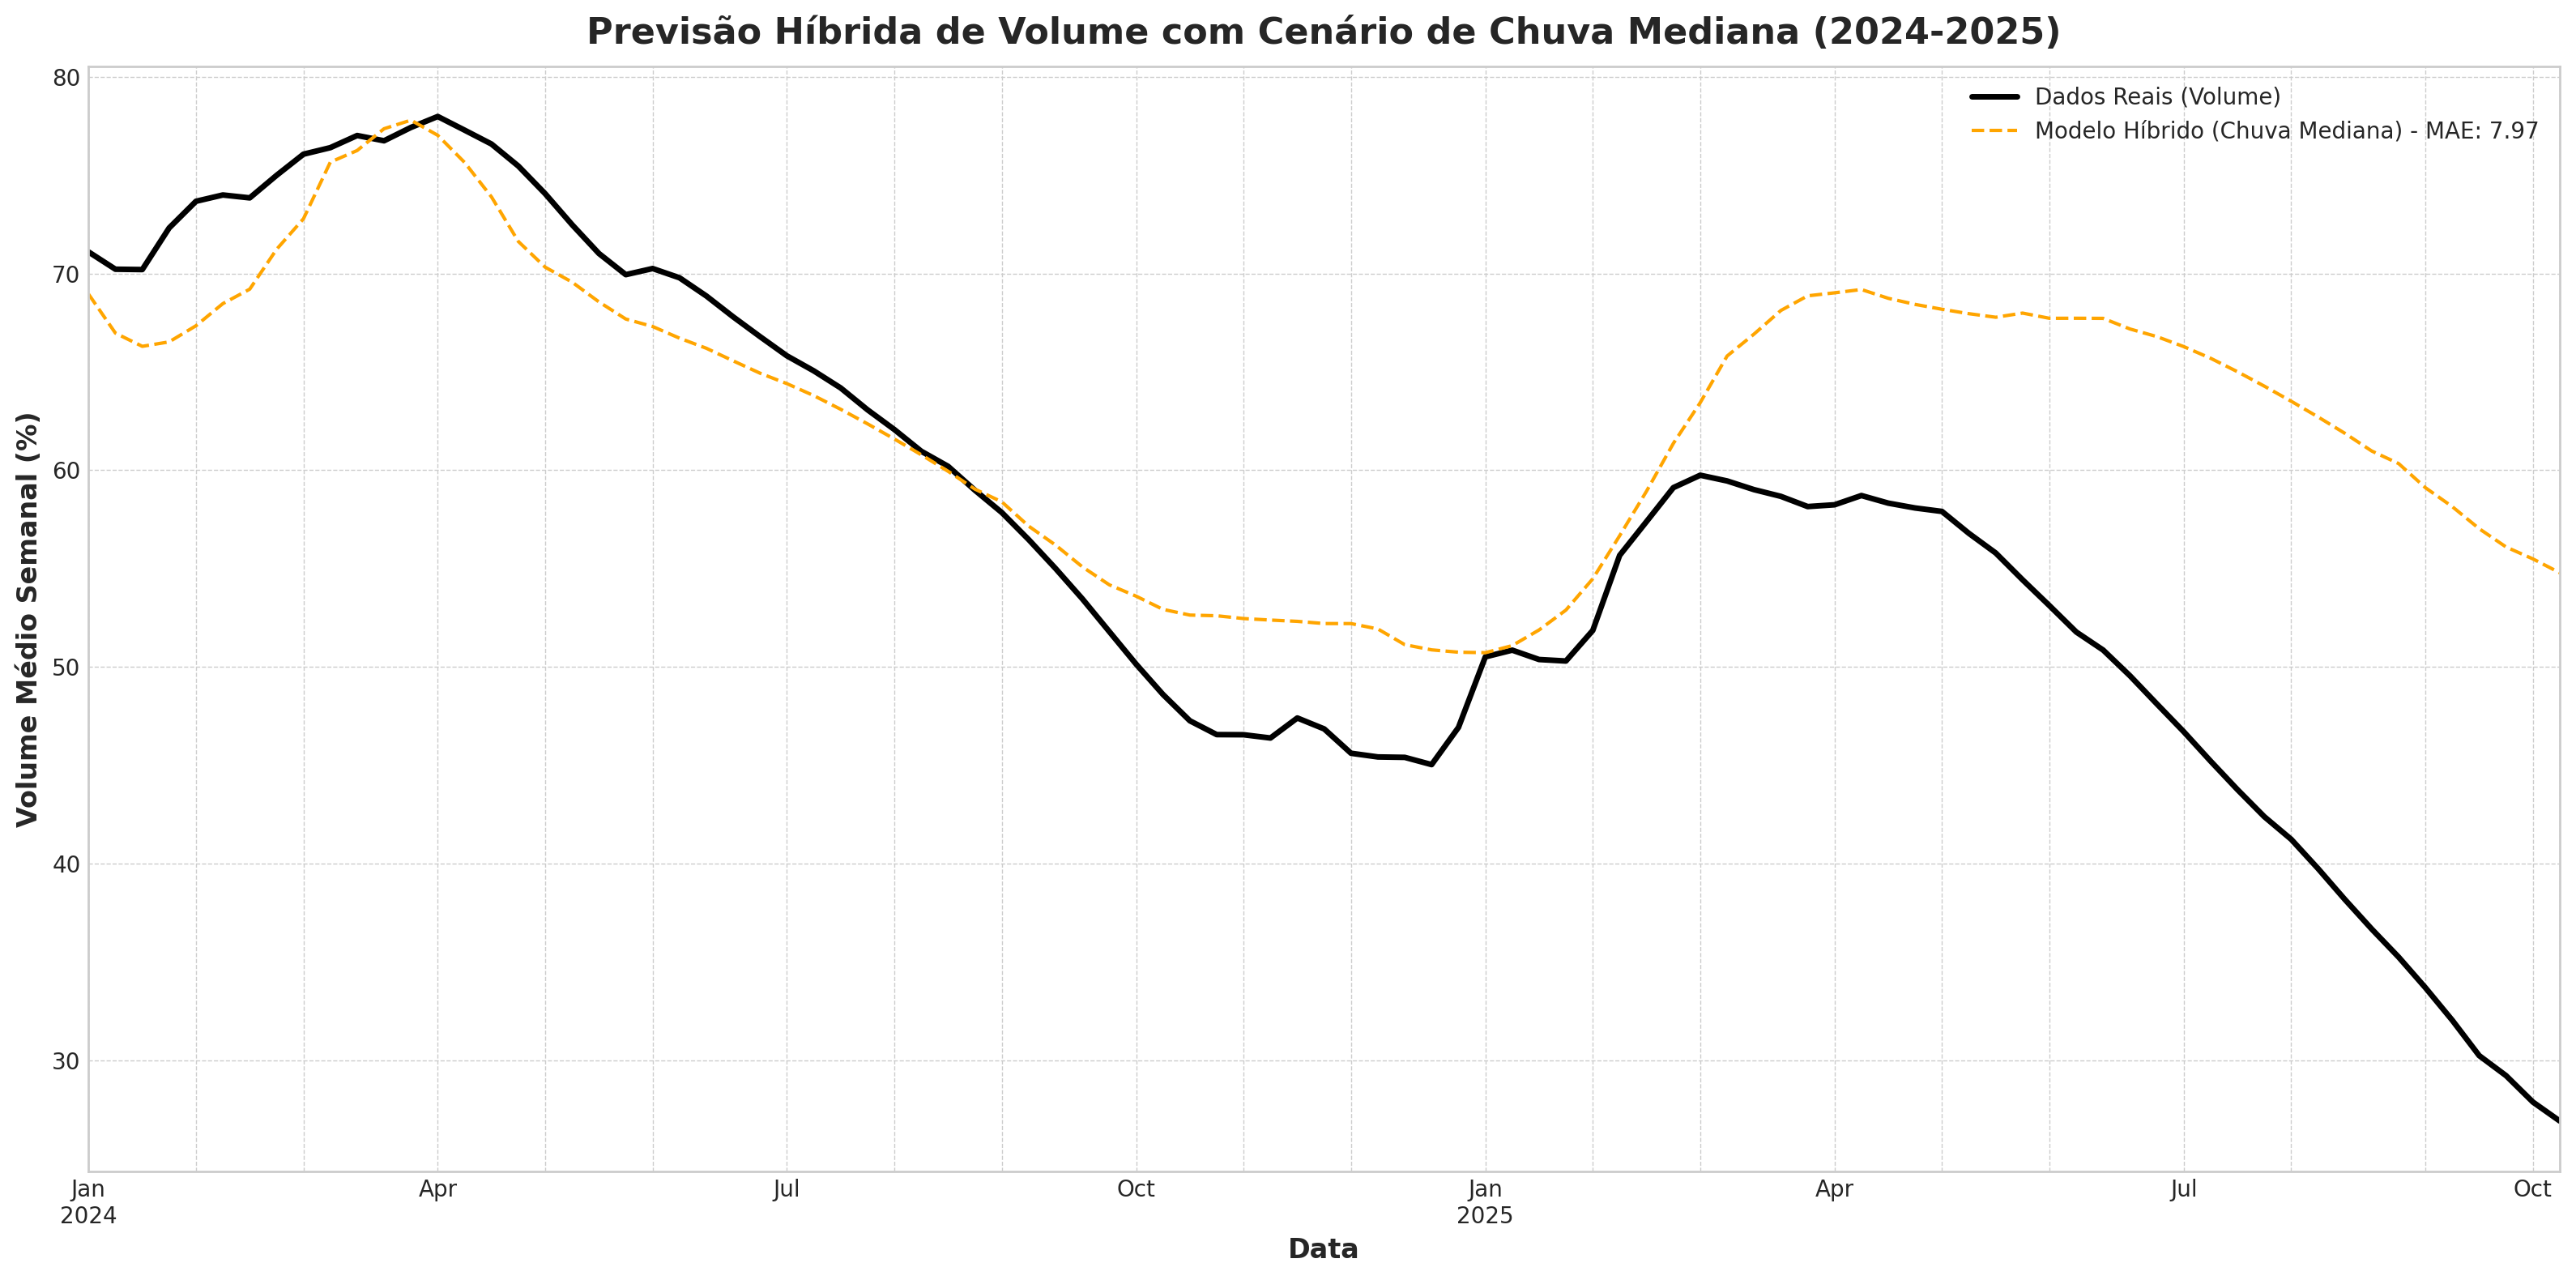

--- Fim do Experimento


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---
# (Esta função é comum e não precisa de sufixo)
def make_lags(ts, lags, name='y'):
    """Cria colunas de lag para uma série temporal."""
    return pd.concat(
        {f'{name}_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base (Volume e Chuva Real)...")

# (Assumindo que dfv e df_chuva estão carregados e limpos)
# Filtra período
df_periodo_vol = dfv.loc['2016-01-01':'2025-12-31'].copy()
df_periodo_chuva = df_chuva.loc['2016-01-01':'2025-12-31'].copy()

# Reamostragem para dados semanais
df_semanal_volume = df_periodo_vol.resample('W').mean()
df_semanal_chuva = df_periodo_chuva.resample('W').sum()

# DataFrame final com DADOS REAIS
df_final = pd.DataFrame({
    'Volume_util': df_semanal_volume["Volume_util"].interpolate(method='linear'),
    'Chuva': df_semanal_chuva['chuva'].fillna(0.0)
})

# Datas de corte e dados reais de teste (comuns a todos)
split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']
# (Definindo target_cols para o passo 2)
target_cols = ['chuva_t+1', 'chuva_t+2', 'chuva_t+3', 'chuva_t+4', 'chuva_t+5', 
              'chuva_t+6', 'chuva_t+7', 'chuva_t+8', 'chuva_t+9', 'chuva_t+10', 
              'chuva_t+11', 'chuva_t+12']


# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MEDIANA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva da 'Mediana Histórica'...")

# 1. Calcular a MEDIANA histórica da chuva
df_train = df_final.loc[df_final.index < split_date].copy()
df_train['week_of_year'] = df_train.index.isocalendar().week
# --- MUDANÇA AQUI ---
seasonal_median_rain = df_train.groupby('week_of_year')['Chuva'].median() 
if 53 in seasonal_median_rain.index and 52 in seasonal_median_rain.index:
    seasonal_median_rain[53] = seasonal_median_rain[52]

# 2. Criar DataFrame de previsões da MEDIANA (agora até 12 semanas)
# --- MUDANÇA NO NOME DA VARIÁVEL ---
df_chuva_forecasts_median = pd.DataFrame(index=test_index, columns=target_cols)

for t in test_index:
    for i in range(1, 13): # 12 semanas
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        # --- MUDANÇA AQUI ---
        median_value = seasonal_median_rain.get(future_week if future_week != 53 else 52, df_train['Chuva'].median()) # Usa mediana geral como fallback
        df_chuva_forecasts_median.loc[t, f'chuva_t+{i}'] = median_value

df_chuva_forecasts_median = df_chuva_forecasts_median.astype(float)
print("Cenário de chuva mediana concluído.")


# --- 3. MODELO 1 (LR): PREVISÃO DA TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 8: Modelo Híbrido com Chuva Mediana ---")
print("Passo 3: Treinando Modelo 1 (Regressão Linear)...")

# --- Sufixo _vol_hybrid_median ---
y1_vol_hybrid_median = df_final['Volume_util']
real_rain_hybrid_median = df_final['Chuva']

dp_vol_hybrid_median = DeterministicProcess(
    index=y1_vol_hybrid_median.index,
    constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)],
    drop=True
)
x1_vol_hybrid_median = dp_vol_hybrid_median.in_sample()

# Divisão para Modelo 1
X1_train_vol_hybrid_median = x1_vol_hybrid_median.loc[x1_vol_hybrid_median.index < split_date]
y1_train_vol_hybrid_median = y1_vol_hybrid_median.loc[y1_vol_hybrid_median.index < split_date]
X1_test_vol_hybrid_median = x1_vol_hybrid_median.loc[x1_vol_hybrid_median.index >= split_date]

# Treinar Modelo 1
model1_lr_vol_hybrid_median = LinearRegression()
model1_lr_vol_hybrid_median.fit(X1_train_vol_hybrid_median, y1_train_vol_hybrid_median)

# Obter previsões (base) e resíduos (alvo do Modelo 2)
y_pred_train_lr_hybrid_median = pd.Series(model1_lr_vol_hybrid_median.predict(X1_train_vol_hybrid_median), index=X1_train_vol_hybrid_median.index)
y_pred_test_lr_hybrid_median = pd.Series(model1_lr_vol_hybrid_median.predict(X1_test_vol_hybrid_median), index=X1_test_vol_hybrid_median.index)
y_res_train_vol_hybrid_median = y1_train_vol_hybrid_median - y_pred_train_lr_hybrid_median


# --- 4. MODELO 2 (XGB): PREVISÃO DOS RESÍDUOS ---
print("Passo 4: Treinando Modelo 2 (XGBoost nos Resíduos)...")

# Features de lag de resíduo (para treino)
x2_res_lags_train_hybrid_median = make_lags(y_res_train_vol_hybrid_median, lags=2, name='res_vol')

# Features de lag de chuva (para treino - USA CHUVA REAL, com 12 lags)
x2_chuva_lags_train_hybrid_median = make_lags(real_rain_hybrid_median, lags=12, name='chuva')

# Combinar features de treino do Modelo 2
X2_train_vol_hybrid_median = pd.concat([x2_res_lags_train_hybrid_median, x2_chuva_lags_train_hybrid_median], axis=1)
X2_train_vol_hybrid_median = X2_train_vol_hybrid_median.dropna()
y_res_train_aligned_hybrid_median = y_res_train_vol_hybrid_median.loc[X2_train_vol_hybrid_median.index]

# Treinar Modelo 2
model2_xgb_vol_hybrid_median = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_median.fit(X2_train_vol_hybrid_median, y_res_train_aligned_hybrid_median)


# --- 5. LOOP DE PREVISÃO RECURSIVA ---
print("Passo 5: Executando loop de previsão recursiva...")

# 1. Criar a "história" da chuva: Real até 2023, MEDIANA Prevista a partir de 2024
# --- MUDANÇA AQUI ---
forecasted_rain_t1_series_median = df_chuva_forecasts_median['chuva_t+1'].shift(1)
rain_history_hybrid_median = pd.concat([
    real_rain_hybrid_median.loc[real_rain_hybrid_median.index < split_date],
    # --- MUDANÇA AQUI ---
    forecasted_rain_t1_series_median.loc[forecasted_rain_t1_series_median.index >= split_date] 
])

# 2. Criar os lags de chuva para o período de teste (usando história com mediana)
X2_chuva_lags_test_hybrid_median = make_lags(rain_history_hybrid_median, lags=12, name='chuva')
X2_chuva_lags_test_hybrid_median = X2_chuva_lags_test_hybrid_median.loc[test_index]

# 3. Preparar o DataFrame recursivo
X2_test_recursive_hybrid_median = X2_chuva_lags_test_hybrid_median.copy()
X2_test_recursive_hybrid_median['res_vol_lag_1'] = np.nan
X2_test_recursive_hybrid_median['res_vol_lag_2'] = np.nan

# 4. Preencher os lags iniciais de resíduo (do final do treino)
first_test_date = X2_test_recursive_hybrid_median.index[0]
last_train_res = y_res_train_aligned_hybrid_median.loc[y_res_train_aligned_hybrid_median.index < first_test_date]
if not last_train_res.empty:
    X2_test_recursive_hybrid_median.loc[first_test_date, 'res_vol_lag_1'] = last_train_res.iloc[-1]
    if len(last_train_res) > 1:
        X2_test_recursive_hybrid_median.loc[first_test_date, 'res_vol_lag_2'] = last_train_res.iloc[-2]

X2_test_recursive_hybrid_median = X2_test_recursive_hybrid_median.fillna(0.0)
X2_test_recursive_hybrid_median = X2_test_recursive_hybrid_median[X2_train_vol_hybrid_median.columns] # Garante ordem das colunas

# 5. Executar o loop
y_pred_res_test_list_hybrid_median = []
for index in X2_test_recursive_hybrid_median.index:
    features_hoje = X2_test_recursive_hybrid_median.loc[[index]]
    pred_hoje = model2_xgb_vol_hybrid_median.predict(features_hoje)[0]
    y_pred_res_test_list_hybrid_median.append(pred_hoje)
    
    try:
        proximo_index = X2_test_recursive_hybrid_median.index[X2_test_recursive_hybrid_median.index.get_loc(index) + 1]
        X2_test_recursive_hybrid_median.loc[proximo_index, 'res_vol_lag_1'] = pred_hoje
        X2_test_recursive_hybrid_median.loc[proximo_index, 'res_vol_lag_2'] = features_hoje['res_vol_lag_1'].values[0]
    except IndexError:
        break
        
y_pred_res_test_xgb_hybrid_median = pd.Series(y_pred_res_test_list_hybrid_median, index=test_index)


# --- 6. RESULTADOS FINAIS E AVALIAÇÃO ---
print("Passo 6: Calculando resultados finais...")

# Previsão Final = Previsão_LR (Base) + Previsão_XGB (Resíduo)
y_final_vol_hybrid_median = y_pred_test_lr_hybrid_median + y_pred_res_test_xgb_hybrid_median

mae_vol_hybrid_median = mean_absolute_error(y_test_truth_volume, y_final_vol_hybrid_median)
rmse_vol_hybrid_median = np.sqrt(mean_squared_error(y_test_truth_volume, y_final_vol_hybrid_median))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido com Chuva Mediana (Experimento 8)")
print("---" * 15)
print(f"MAE (Erro Médio Absoluto): {mae_vol_hybrid_median:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_vol_hybrid_median:.2f}")
print("---" * 15)


# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

fig, ax = plt.subplots(figsize=(16, 8))

# Dados Reais
y_test_truth_volume.plot(ax=ax, color='black', style='-', linewidth=2.5, label='Dados Reais (Volume)')

# Modelo Híbrido com Mediana
y_final_vol_hybrid_median.plot(ax=ax, color='orange', linestyle='--', label=f'Modelo Híbrido (Chuva Mediana) - MAE: {mae_vol_hybrid_median:.2f}')

ax.set_title('Previsão Híbrida de Volume com Cenário de Chuva Mediana (2024-2025)')
ax.set_ylabel('Volume Médio Semanal (%)')
ax.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("--- Fim do Experimento")

In [45]:
X1_train_vol_hybrid_avg 

,const,trend,"sin(1,freq=YE-DEC)","cos(1,freq=YE-DEC)","sin(2,freq=YE-DEC)","cos(2,freq=YE-DEC)","sin(3,freq=YE-DEC)","cos(3,freq=YE-DEC)","sin(4,freq=YE-DEC)","cos(4,freq=YE-DEC)"
Data,,,,,,,,,,
2016-01-03,1.0,1.0,0.034328,0.999411,0.068615,0.997643,0.102821,0.994700,0.136906,0.990584
2016-01-10,1.0,2.0,0.153891,0.988088,0.304115,0.952635,0.447094,0.894487,0.579421,0.815028
2016-01-17,1.0,3.0,0.271234,0.962513,0.522133,0.852864,0.733885,0.679273,0.890617,0.454755
2016-01-24,1.0,4.0,0.384665,0.923056,0.710135,0.704066,0.926324,0.376728,0.999963,-0.008583
2016-01-31,1.0,5.0,0.492548,0.870285,0.857315,0.514793,0.999668,0.025748,0.882679,-0.469977
...,...,...,...,...,...,...,...,...,...,...
2023-12-03,1.0,414.0,-0.478734,0.877960,-0.840618,0.541628,-0.997325,0.073095,-0.910605,-0.413279
2023-12-10,1.0,415.0,-0.369725,0.929141,-0.687053,0.726608,-0.907014,0.421101,-0.998435,0.055917
2023-12-17,1.0,416.0,-0.255353,0.966848,-0.493776,0.869589,-0.699458,0.714673,-0.858764,0.512371


In [37]:
X2_test_recursive_hybrid_avg

,res_vol_lag_1,res_vol_lag_2,chuva_lag_1,chuva_lag_2,chuva_lag_3,chuva_lag_4,chuva_lag_5,chuva_lag_6,chuva_lag_7,chuva_lag_8,chuva_lag_9,chuva_lag_10,chuva_lag_11,chuva_lag_12
Data,,,,,,,,,,,,,,
2024-01-07,26.191602,26.761769,8.450000,35.150000,13.550000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000,31.90000,66.41500
2024-01-14,23.083923,26.191602,0.000000,8.450000,35.150000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000,31.90000
2024-01-21,20.699263,23.083923,73.278125,0.000000,8.450000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000
2024-01-28,19.223543,20.699263,45.165625,73.278125,0.000000,8.45000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000
2024-02-04,18.006371,19.223543,55.881250,45.165625,73.278125,0.00000,8.45000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-14,2.260711,2.439507,11.506250,8.000000,14.593750,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125,4.73750,1.85000
2025-09-21,2.403336,2.260711,5.956250,11.506250,8.000000,14.59375,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125,4.73750
2025-09-28,2.260711,2.403336,5.775000,5.956250,11.506250,8.00000,14.59375,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125


Passo 1: Preparando dados base (Volume e Chuva Real)...
Passo 2: Criando cenário de chuva da 'Média Histórica'...

--- Início do Experimento 7: Modelo Híbrido-Direto (Sem Lags de Resíduo) ---
Passo 3: Treinando Modelo 1 (Regressão Linear)...
Passo 4: Treinando Modelo 2 (XGBoost) - Estratégia Direta...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Treinamento do Modelo 2 (XGBoost) concluído.
Passo 5: Executando previsão (Estratégia Direta)...
Passo 6: Calculando resultados finais...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido-Direto (Experimento 7)
---------------------------------------------
MAE (Erro Médio Absoluto): 10.67
RMSE (Raiz do Erro Quadrático Médio): 12.27
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


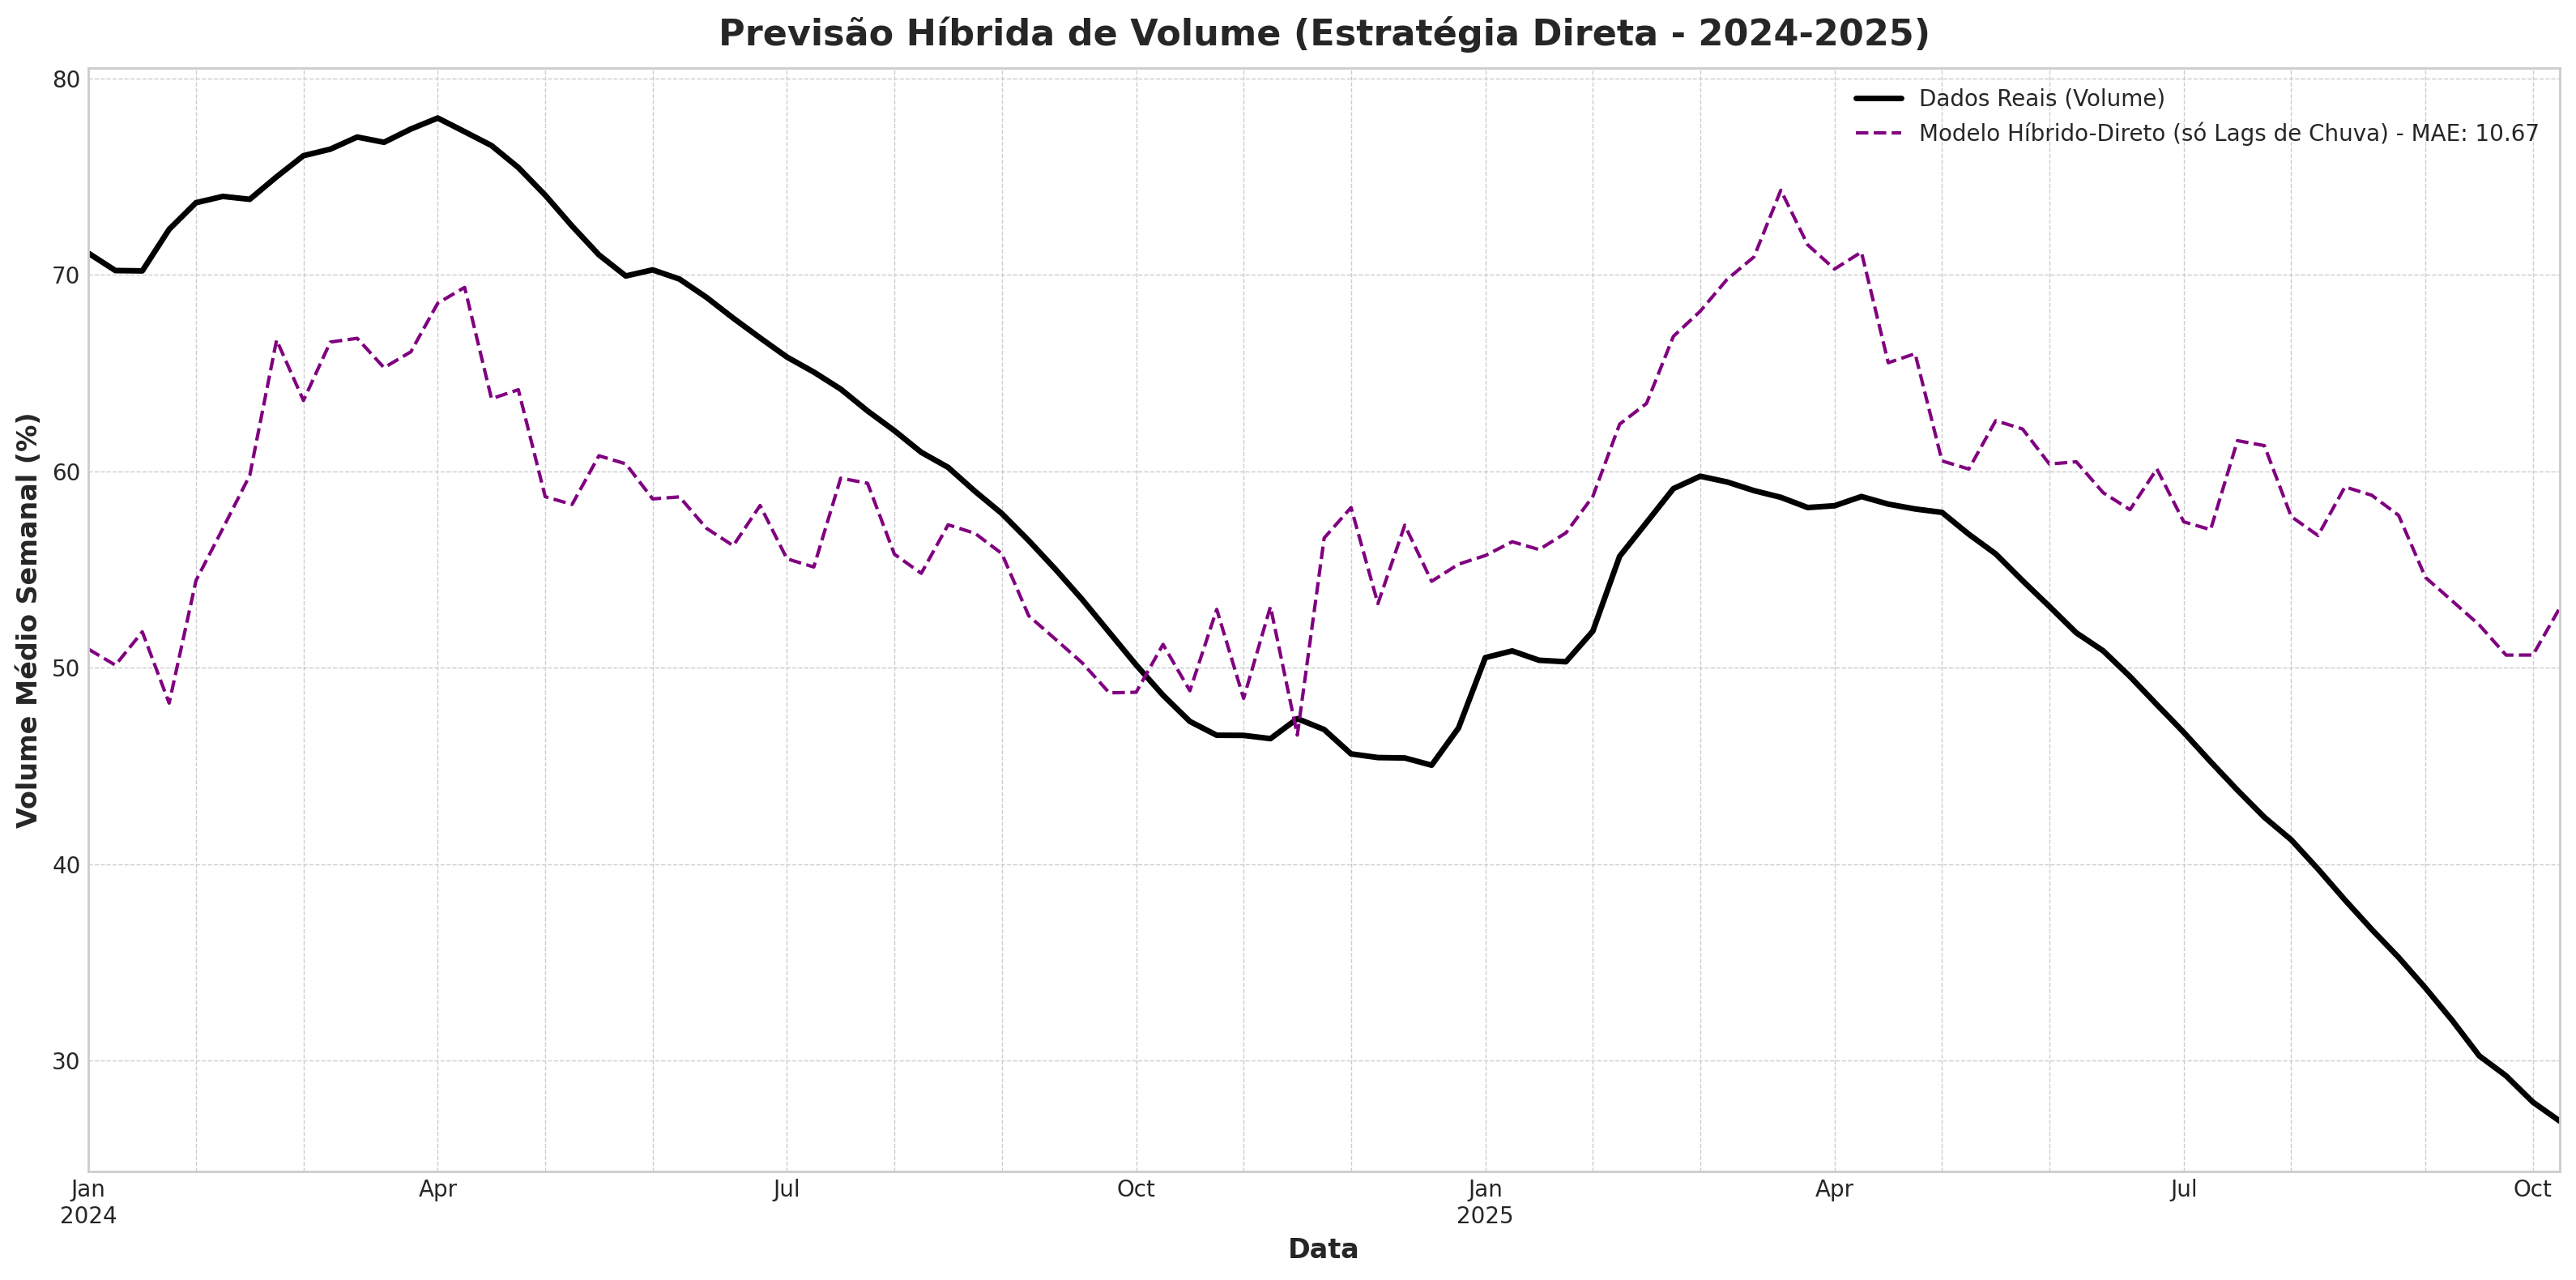

--- Fim do Experimento 7 ---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---
# (Esta função é comum e não precisa de sufixo)
def make_lags(ts, lags, name='y'):
    """Cria colunas de lag para uma série temporal."""
    return pd.concat(
        {f'{name}_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base (Volume e Chuva Real)...")
# (Assumindo que df_final e target_cols já existem das execuções anteriores)
# (df_final contém 'Volume_util' e 'Chuva' reais)
# (target_cols contém a lista de 'chuva_t+1' a 'chuva_t+12')

# Datas de corte e dados reais de teste (comuns a todos)
split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']

# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MÉDIA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva da 'Média Histórica'...")
# (Assumindo que df_chuva_forecasts_avg foi criado no Experimento 6)
# (Se não, o código para criá-lo precisaria estar aqui)
# ... (código para criar df_chuva_forecasts_avg) ...
# (Vou copiá-lo para garantir que o script seja completo)

df_train_para_media = df_final.loc[df_final.index < split_date].copy()
df_train_para_media['week_of_year'] = df_train_para_media.index.isocalendar().week
seasonal_avg_rain = df_train_para_media.groupby('week_of_year')['Chuva'].mean()
if 53 in seasonal_avg_rain.index and 52 in seasonal_avg_rain.index:
    seasonal_avg_rain[53] = seasonal_avg_rain[52]

df_chuva_forecasts_avg_direct = pd.DataFrame(index=test_index, columns=target_cols)
for t in test_index:
    for i in range(1, 13): # 12 semanas
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        avg_value = seasonal_avg_rain.get(future_week if future_week != 53 else 52, df_train_para_media['Chuva'].mean())
        df_chuva_forecasts_avg_direct.loc[t, f'chuva_t+{i}'] = avg_value
df_chuva_forecasts_avg_direct = df_chuva_forecasts_avg_direct.astype(float)


# --- 3. MODELO 1 (LR): PREVISÃO DA TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 7: Modelo Híbrido-Direto (Sem Lags de Resíduo) ---")
print("Passo 3: Treinando Modelo 1 (Regressão Linear)...")

# --- Sufixo _vol_hybrid_direct ---
y1_vol_hybrid_direct = df_final['Volume_util']
real_rain_hybrid_direct = df_final['Chuva']

dp_vol_hybrid_direct = DeterministicProcess(
    index=y1_vol_hybrid_direct.index,
    constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)],
    drop=True
)
x1_vol_hybrid_direct = dp_vol_hybrid_direct.in_sample()

X1_train_vol_hybrid_direct = x1_vol_hybrid_direct.loc[x1_vol_hybrid_direct.index < split_date]
y1_train_vol_hybrid_direct = y1_vol_hybrid_direct.loc[y1_vol_hybrid_direct.index < split_date]
X1_test_vol_hybrid_direct = x1_vol_hybrid_direct.loc[x1_vol_hybrid_direct.index >= split_date]

model1_lr_vol_hybrid_direct = LinearRegression()
model1_lr_vol_hybrid_direct.fit(X1_train_vol_hybrid_direct, y1_train_vol_hybrid_direct)

y_pred_train_lr_hybrid_direct = pd.Series(model1_lr_vol_hybrid_direct.predict(X1_train_vol_hybrid_direct), index=X1_train_vol_hybrid_direct.index)
y_pred_test_lr_hybrid_direct = pd.Series(model1_lr_vol_hybrid_direct.predict(X1_test_vol_hybrid_direct), index=X1_test_vol_hybrid_direct.index)
y_res_train_vol_hybrid_direct = y1_train_vol_hybrid_direct - y_pred_train_lr_hybrid_direct


# --- 4. MODELO 2 (XGB): PREVISÃO DOS RESÍDUOS (ESTRATÉGIA DIRETA) ---
print("Passo 4: Treinando Modelo 2 (XGBoost) - Estratégia Direta...")

# --- MUDANÇA PRINCIPAL: FEATURES (X) ---
# Criamos os lags para o dataset INTEIRO
x2_chuva_lags_hybrid_direct = make_lags(real_rain_hybrid_direct, lags=12, name='chuva')

# --- INÍCIO DA CORREÇÃO ---
# 1. Primeiro, filtramos as features de chuva para o período de TREINO
X2_train_vol_hybrid_direct = x2_chuva_lags_hybrid_direct.loc[x2_chuva_lags_hybrid_direct.index < split_date].copy()

# 2. SÓ AGORA nós removemos os NaNs (que estão no início do período de treino)
X2_train_vol_hybrid_direct = X2_train_vol_hybrid_direct.dropna()

# 3. Agora, alinhamos o alvo (resíduos de treino) com as features de treino limpas.
#    Ambos os DataFrames agora terminam em 2023-12-31 e não há mais "KeyError".
y_res_train_aligned_hybrid_direct = y_res_train_vol_hybrid_direct.loc[X2_train_vol_hybrid_direct.index]
# --- FIM DA CORREÇÃO ---

# Treinar Modelo 2
model2_xgb_vol_hybrid_direct = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_direct.fit(X2_train_vol_hybrid_direct, y_res_train_aligned_hybrid_direct)

print("Treinamento do Modelo 2 (XGBoost) concluído.")

# --- 5. PREVISÃO (ESTRATÉGIA DIRETA - SEM LOOP) ---
print("Passo 5: Executando previsão (Estratégia Direta)...")

# 1. Criar a "história" da chuva: Real até 2023, Média Prevista a partir de 2024
forecasted_rain_t1_series_avg = df_chuva_forecasts_avg_direct['chuva_t+1'].shift(1)
rain_history_hybrid_direct = pd.concat([
    real_rain_hybrid_direct.loc[real_rain_hybrid_direct.index < split_date],
    forecasted_rain_t1_series_avg.loc[forecasted_rain_t1_series_avg.index >= split_date]
])

# 2. Criar os lags de chuva para o período de teste (as únicas features necessárias)
X2_test_vol_hybrid_direct = make_lags(rain_history_hybrid_direct, lags=12, name='chuva')
X2_test_vol_hybrid_direct = X2_test_vol_hybrid_direct.loc[test_index]

# 3. Preencher quaisquer NaNs (caso o histórico não seja suficiente no início do teste)
X2_test_vol_hybrid_direct = X2_test_vol_hybrid_direct.fillna(0.0)

# 4. Fazer a previsão de UMA SÓ VEZ (sem loop)
y_pred_res_test_xgb_hybrid_direct = pd.Series(
    model2_xgb_vol_hybrid_direct.predict(X2_test_vol_hybrid_direct),
    index=test_index
)


# --- 6. RESULTADOS FINAIS E AVALIAÇÃO ---
print("Passo 6: Calculando resultados finais...")

# Previsão Final = Previsão_LR (Base) + Previsão_XGB (Resíduo)
y_final_vol_hybrid_direct = y_pred_test_lr_hybrid_direct + y_pred_res_test_xgb_hybrid_direct

mae_vol_hybrid_direct = mean_absolute_error(y_test_truth_volume, y_final_vol_hybrid_direct)
rmse_vol_hybrid_direct = np.sqrt(mean_squared_error(y_test_truth_volume, y_final_vol_hybrid_direct))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido-Direto (Experimento 7)")
print("---" * 15)
print(f"MAE (Erro Médio Absoluto): {mae_vol_hybrid_direct:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_vol_hybrid_direct:.2f}")
print("---" * 15)


# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

fig, ax = plt.subplots(figsize=(16, 8))

# Dados Reais
y_test_truth_volume.plot(ax=ax, color='black', style='-', linewidth=2.5, label='Dados Reais (Volume)')

# Modelo Híbrido-Direto
y_final_vol_hybrid_direct.plot(ax=ax, color='purple', linestyle='--', label=f'Modelo Híbrido-Direto (só Lags de Chuva) - MAE: {mae_vol_hybrid_direct:.2f}')

ax.set_title('Previsão Híbrida de Volume (Estratégia Direta - 2024-2025)')
ax.set_ylabel('Volume Médio Semanal (%)')
ax.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("--- Fim do Experimento 7 ---")

In [44]:
X2_test_vol_hybrid_direct

,chuva_lag_1,chuva_lag_2,chuva_lag_3,chuva_lag_4,chuva_lag_5,chuva_lag_6,chuva_lag_7,chuva_lag_8,chuva_lag_9,chuva_lag_10,chuva_lag_11,chuva_lag_12
Data,,,,,,,,,,,,
2024-01-07,8.450000,35.150000,13.550000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000,31.90000,66.41500
2024-01-14,0.000000,8.450000,35.150000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000,31.90000
2024-01-21,73.278125,0.000000,8.450000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000,32.20000
2024-01-28,45.165625,73.278125,0.000000,8.45000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000,65.60000
2024-02-04,55.881250,45.165625,73.278125,0.00000,8.45000,35.15000,13.55000,17.85000,74.55000,32.30000,17.95000,11.60000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-14,11.506250,8.000000,14.593750,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125,4.73750,1.85000
2025-09-21,5.956250,11.506250,8.000000,14.59375,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125,4.73750
2025-09-28,5.775000,5.956250,11.506250,8.00000,14.59375,7.90625,8.23750,8.58125,4.75625,1.08125,1.31875,10.63125


Passo 1: Preparando dados base (Volume e Chuva Real)...
Passo 2: Criando cenário de chuva da 'Mediana Histórica'...
Cenário de chuva mediana concluído.

--- Início do Experimento 8: Modelo Híbrido-Direto (Chuva Mediana) ---
Passo 3: Treinando Modelo 1 (Regressão Linear)...
Passo 4: Treinando Modelo 2 (XGBoost) - Estratégia Direta...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Treinamento do Modelo 2 (XGBoost) concluído.
Passo 5: Executando previsão (Estratégia Direta)...
Passo 6: Calculando resultados finais...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido-Direto com Chuva Mediana (Experimento 8)
---------------------------------------------
MAE (Erro Médio Absoluto): 10.29
RMSE (Raiz do Erro Quadrático Médio): 12.44
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


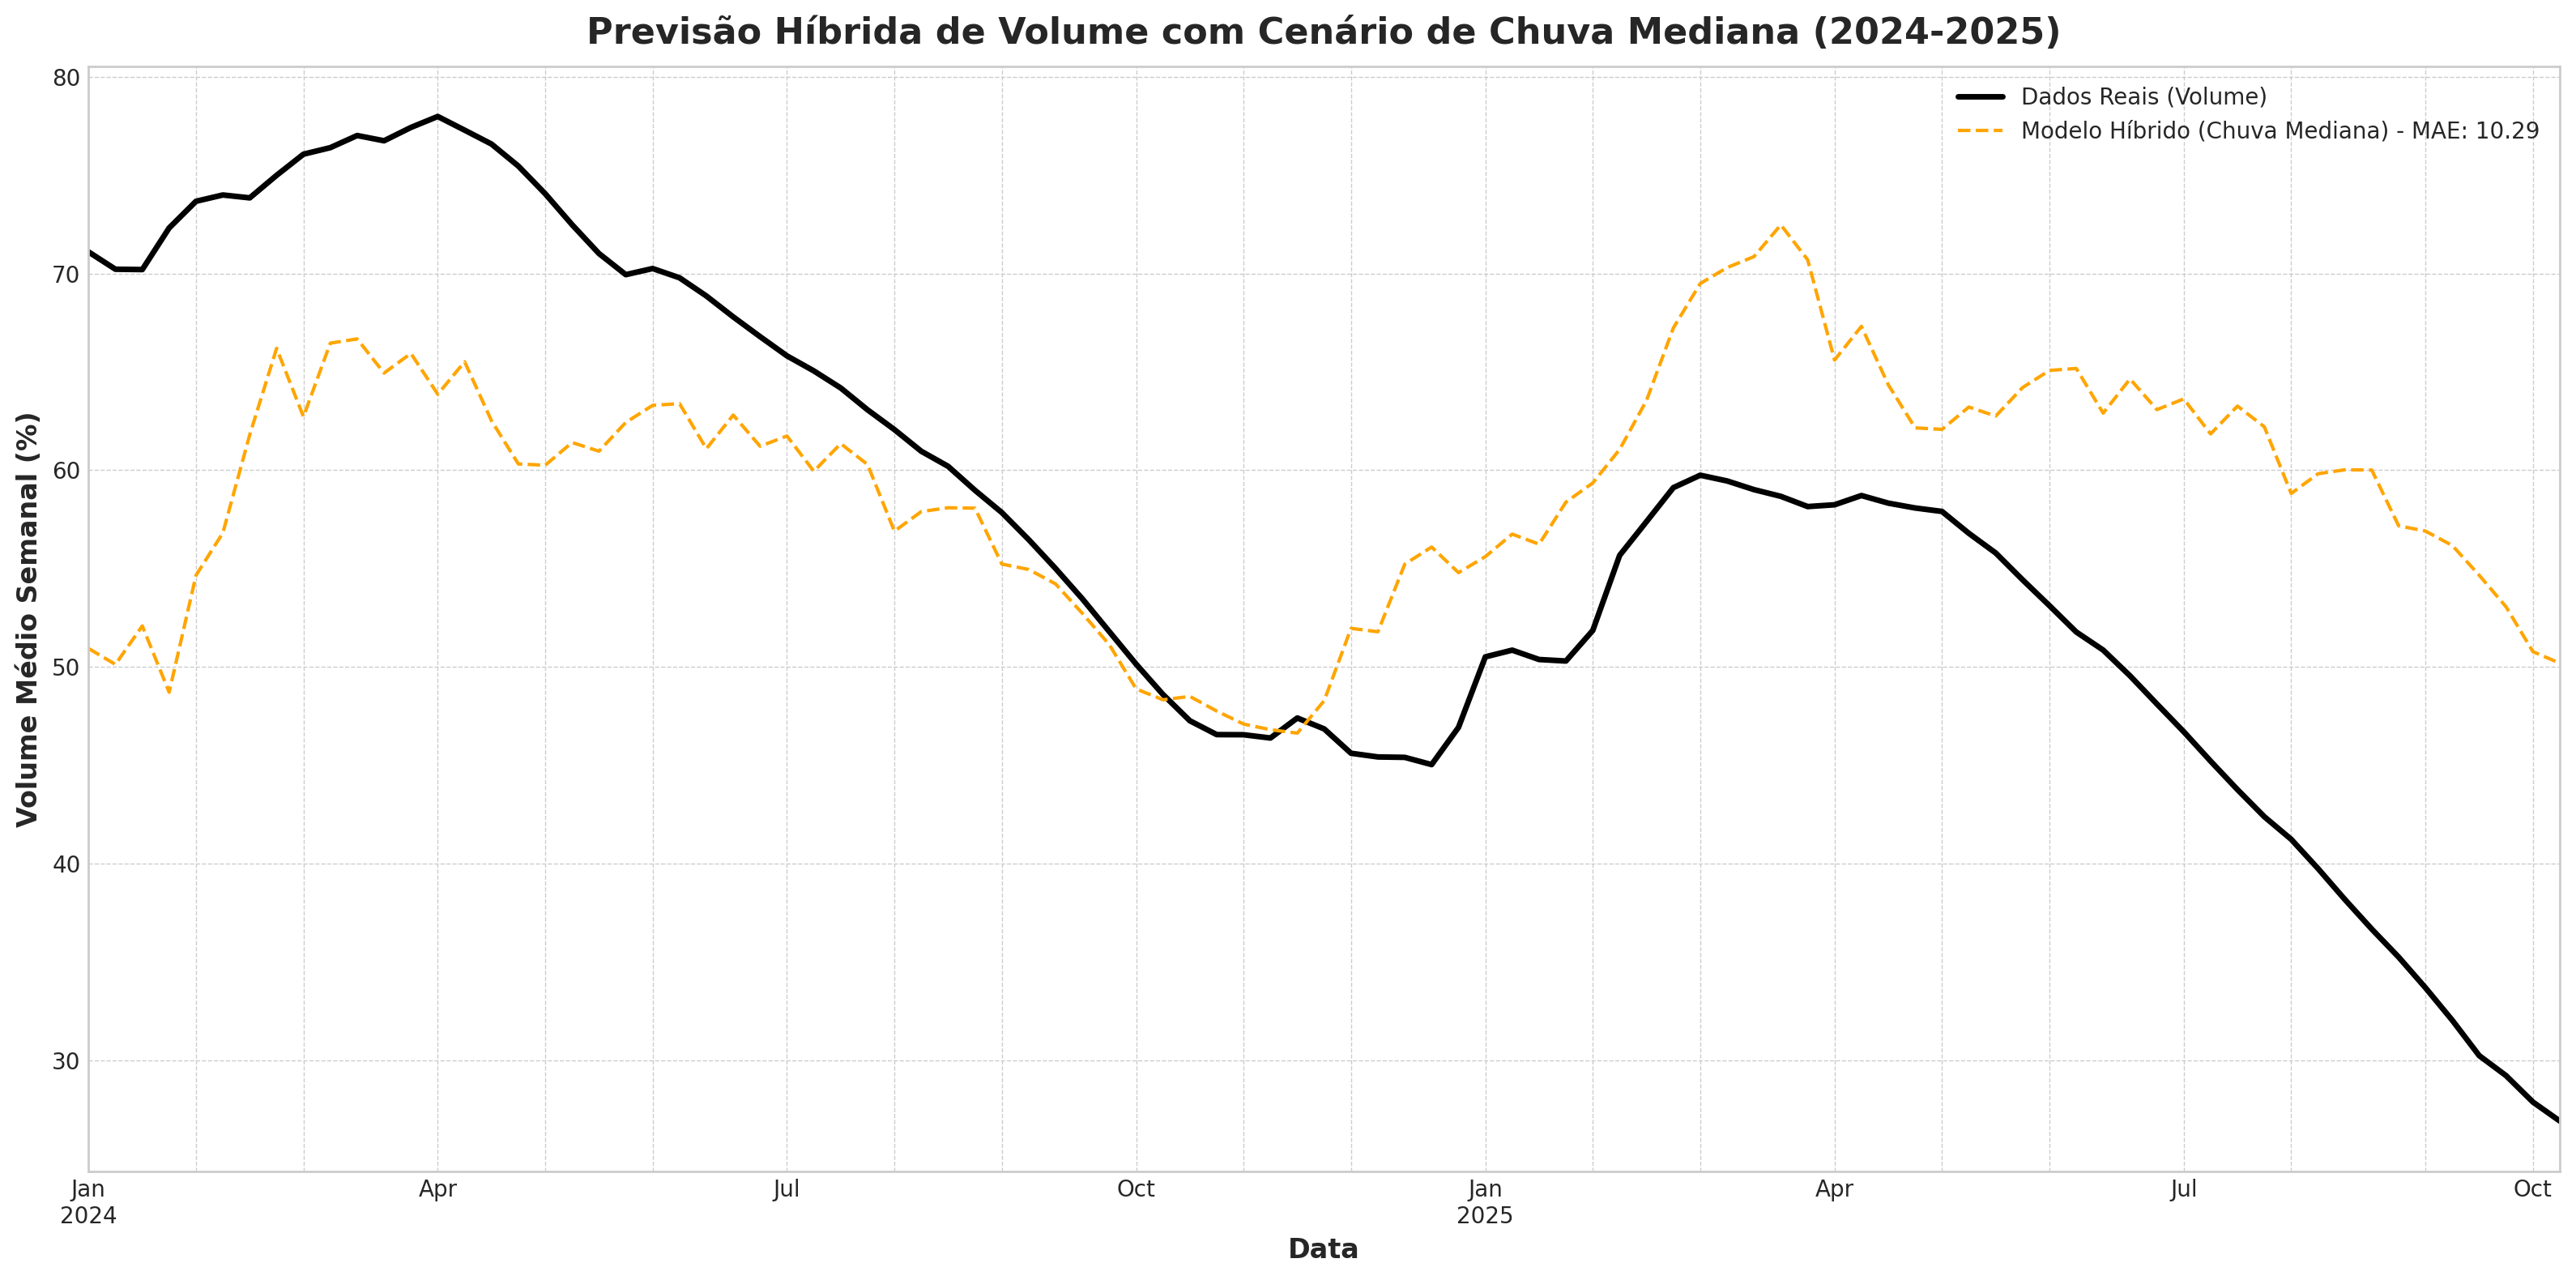

--- Fim do Experimento 8 ---


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---
# (Esta função é comum e não precisa de sufixo)
def make_lags(ts, lags, name='y'):
    """Cria colunas de lag para uma série temporal."""
    return pd.concat(
        {f'{name}_lag_{i}': ts.shift(i) for i in range(1, lags + 1)},
        axis=1)

# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base (Volume e Chuva Real)...")
# (Assumindo que df_final e target_cols já existem das execuções anteriores)
# (df_final contém 'Volume_util' e 'Chuva' reais)
# (target_cols contém a lista de 'chuva_t+1' a 'chuva_t+12')

# Datas de corte e dados reais de teste (comuns a todos)
split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']

# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MEDIANA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva da 'Mediana Histórica'...")

# 1. Calcular a MEDIANA histórica da chuva
df_train_para_mediana = df_final.loc[df_final.index < split_date].copy()
df_train_para_mediana['week_of_year'] = df_train_para_mediana.index.isocalendar().week
# --- MUDANÇA: Usar .median() em vez de .mean() ---
seasonal_median_rain = df_train_para_mediana.groupby('week_of_year')['Chuva'].median()
if 53 in seasonal_median_rain.index and 52 in seasonal_median_rain.index:
    seasonal_median_rain[53] = seasonal_median_rain[52] # Lida com a semana 53

# 2. Criar DataFrame de previsões (cenário) da mediana
# --- Variável renomeada para _Median ---
df_chuva_forecasts_median_direct = pd.DataFrame(index=test_index, columns=target_cols)
for t in test_index:
    for i in range(1, 13): # 12 semanas
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        # --- Usa a MEDIANA sazonal ---
        median_value = seasonal_median_rain.get(future_week if future_week != 53 else 52, df_train_para_mediana['Chuva'].median()) # Fallback para mediana geral se semana não encontrada
        df_chuva_forecasts_median_direct.loc[t, f'chuva_t+{i}'] = median_value
df_chuva_forecasts_median_direct = df_chuva_forecasts_median_direct.astype(float)
print("Cenário de chuva mediana concluído.")


# --- 3. MODELO 1 (LR): PREVISÃO DA TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 8: Modelo Híbrido-Direto (Chuva Mediana) ---")
print("Passo 3: Treinando Modelo 1 (Regressão Linear)...")

# --- Sufixo _vol_hybrid_median ---
y1_vol_hybrid_median = df_final['Volume_util']
real_rain_hybrid_median = df_final['Chuva'] # Chuva real ainda é usada no treino do XGB

dp_vol_hybrid_median = DeterministicProcess(
    index=y1_vol_hybrid_median.index,
    constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)],
    drop=True
)
x1_vol_hybrid_median = dp_vol_hybrid_median.in_sample()

X1_train_vol_hybrid_median = x1_vol_hybrid_median.loc[x1_vol_hybrid_median.index < split_date]
y1_train_vol_hybrid_median = y1_vol_hybrid_median.loc[y1_vol_hybrid_median.index < split_date]
X1_test_vol_hybrid_median = x1_vol_hybrid_median.loc[x1_vol_hybrid_median.index >= split_date]

model1_lr_vol_hybrid_median = LinearRegression()
model1_lr_vol_hybrid_median.fit(X1_train_vol_hybrid_median, y1_train_vol_hybrid_median)

y_pred_train_lr_hybrid_median = pd.Series(model1_lr_vol_hybrid_median.predict(X1_train_vol_hybrid_median), index=X1_train_vol_hybrid_median.index)
y_pred_test_lr_hybrid_median = pd.Series(model1_lr_vol_hybrid_median.predict(X1_test_vol_hybrid_median), index=X1_test_vol_hybrid_median.index)
y_res_train_vol_hybrid_median = y1_train_vol_hybrid_median - y_pred_train_lr_hybrid_median


# --- 4. MODELO 2 (XGB): PREVISÃO DOS RESÍDUOS (ESTRATÉGIA DIRETA) ---
print("Passo 4: Treinando Modelo 2 (XGBoost) - Estratégia Direta...")

# Features são os lags da chuva REAL (para treino)
x2_chuva_lags_train_hybrid_median = make_lags(real_rain_hybrid_median, lags=12, name='chuva')
X2_train_vol_hybrid_median = x2_chuva_lags_train_hybrid_median.loc[x2_chuva_lags_train_hybrid_median.index < split_date].copy()
X2_train_vol_hybrid_median = X2_train_vol_hybrid_median.dropna()

# Alinhar o alvo (resíduos)
y_res_train_aligned_hybrid_median = y_res_train_vol_hybrid_median.loc[X2_train_vol_hybrid_median.index]

# Treinar Modelo 2
model2_xgb_vol_hybrid_median = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_median.fit(X2_train_vol_hybrid_median, y_res_train_aligned_hybrid_median)

print("Treinamento do Modelo 2 (XGBoost) concluído.")

# --- 5. PREVISÃO (ESTRATÉGIA DIRETA - SEM LOOP) ---
print("Passo 5: Executando previsão (Estratégia Direta)...")

# 1. Criar a "história" da chuva: Real até 2023, MEDIANA Prevista a partir de 2024
# --- USA O CENÁRIO DE MEDIANA ---
forecasted_rain_t1_series_median = df_chuva_forecasts_median_direct['chuva_t+1'].shift(1)
rain_history_hybrid_median = pd.concat([
    real_rain_hybrid_median.loc[real_rain_hybrid_median.index < split_date],
    forecasted_rain_t1_series_median.loc[forecasted_rain_t1_series_median.index >= split_date]
])

# 2. Criar os lags de chuva para o período de teste
X2_test_vol_hybrid_median = make_lags(rain_history_hybrid_median, lags=12, name='chuva')
X2_test_vol_hybrid_median = X2_test_vol_hybrid_median.loc[test_index]
X2_test_vol_hybrid_median = X2_test_vol_hybrid_median.fillna(0.0)

# 3. Fazer a previsão de UMA SÓ VEZ
y_pred_res_test_xgb_hybrid_median = pd.Series(
    model2_xgb_vol_hybrid_median.predict(X2_test_vol_hybrid_median),
    index=test_index
)


# --- 6. RESULTADOS FINAIS E AVALIAÇÃO ---
print("Passo 6: Calculando resultados finais...")

# Previsão Final = Previsão_LR (Base) + Previsão_XGB (Resíduo)
y_final_vol_hybrid_median = y_pred_test_lr_hybrid_median + y_pred_res_test_xgb_hybrid_median

mae_vol_hybrid_median = mean_absolute_error(y_test_truth_volume, y_final_vol_hybrid_median)
rmse_vol_hybrid_median = np.sqrt(mean_squared_error(y_test_truth_volume, y_final_vol_hybrid_median))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido-Direto com Chuva Mediana (Experimento 8)")
print("---" * 15)
print(f"MAE (Erro Médio Absoluto): {mae_vol_hybrid_median:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_vol_hybrid_median:.2f}")
print("---" * 15)


# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

fig, ax = plt.subplots(figsize=(16, 8))

# Dados Reais
y_test_truth_volume.plot(ax=ax, color='black', style='-', linewidth=2.5, label='Dados Reais (Volume)')

# Modelo Híbrido-Mediana
y_final_vol_hybrid_median.plot(ax=ax, color='orange', linestyle='--', label=f'Modelo Híbrido (Chuva Mediana) - MAE: {mae_vol_hybrid_median:.2f}')

ax.set_title('Previsão Híbrida de Volume com Cenário de Chuva Mediana (2024-2025)')
ax.set_ylabel('Volume Médio Semanal (%)')
ax.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("--- Fim do Experimento 8 ---")

Passo 1: Preparando dados base...
Passo 2: Criando cenário de chuva mediana...

--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---
Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...
Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Passo 5: Gerando previsões finais (Híbrido MIMO)...
Passo 6: Avaliando o modelo (Híbrido MIMO)...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)
---------------------------------------------
TREINO - MAE: 1.21, RMSE: 1.56
TESTE  - MAE: 2.16, RMSE: 2.89
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


AttributeError: '_process_plot_var_args' object has no attribute 'prop_cycler'

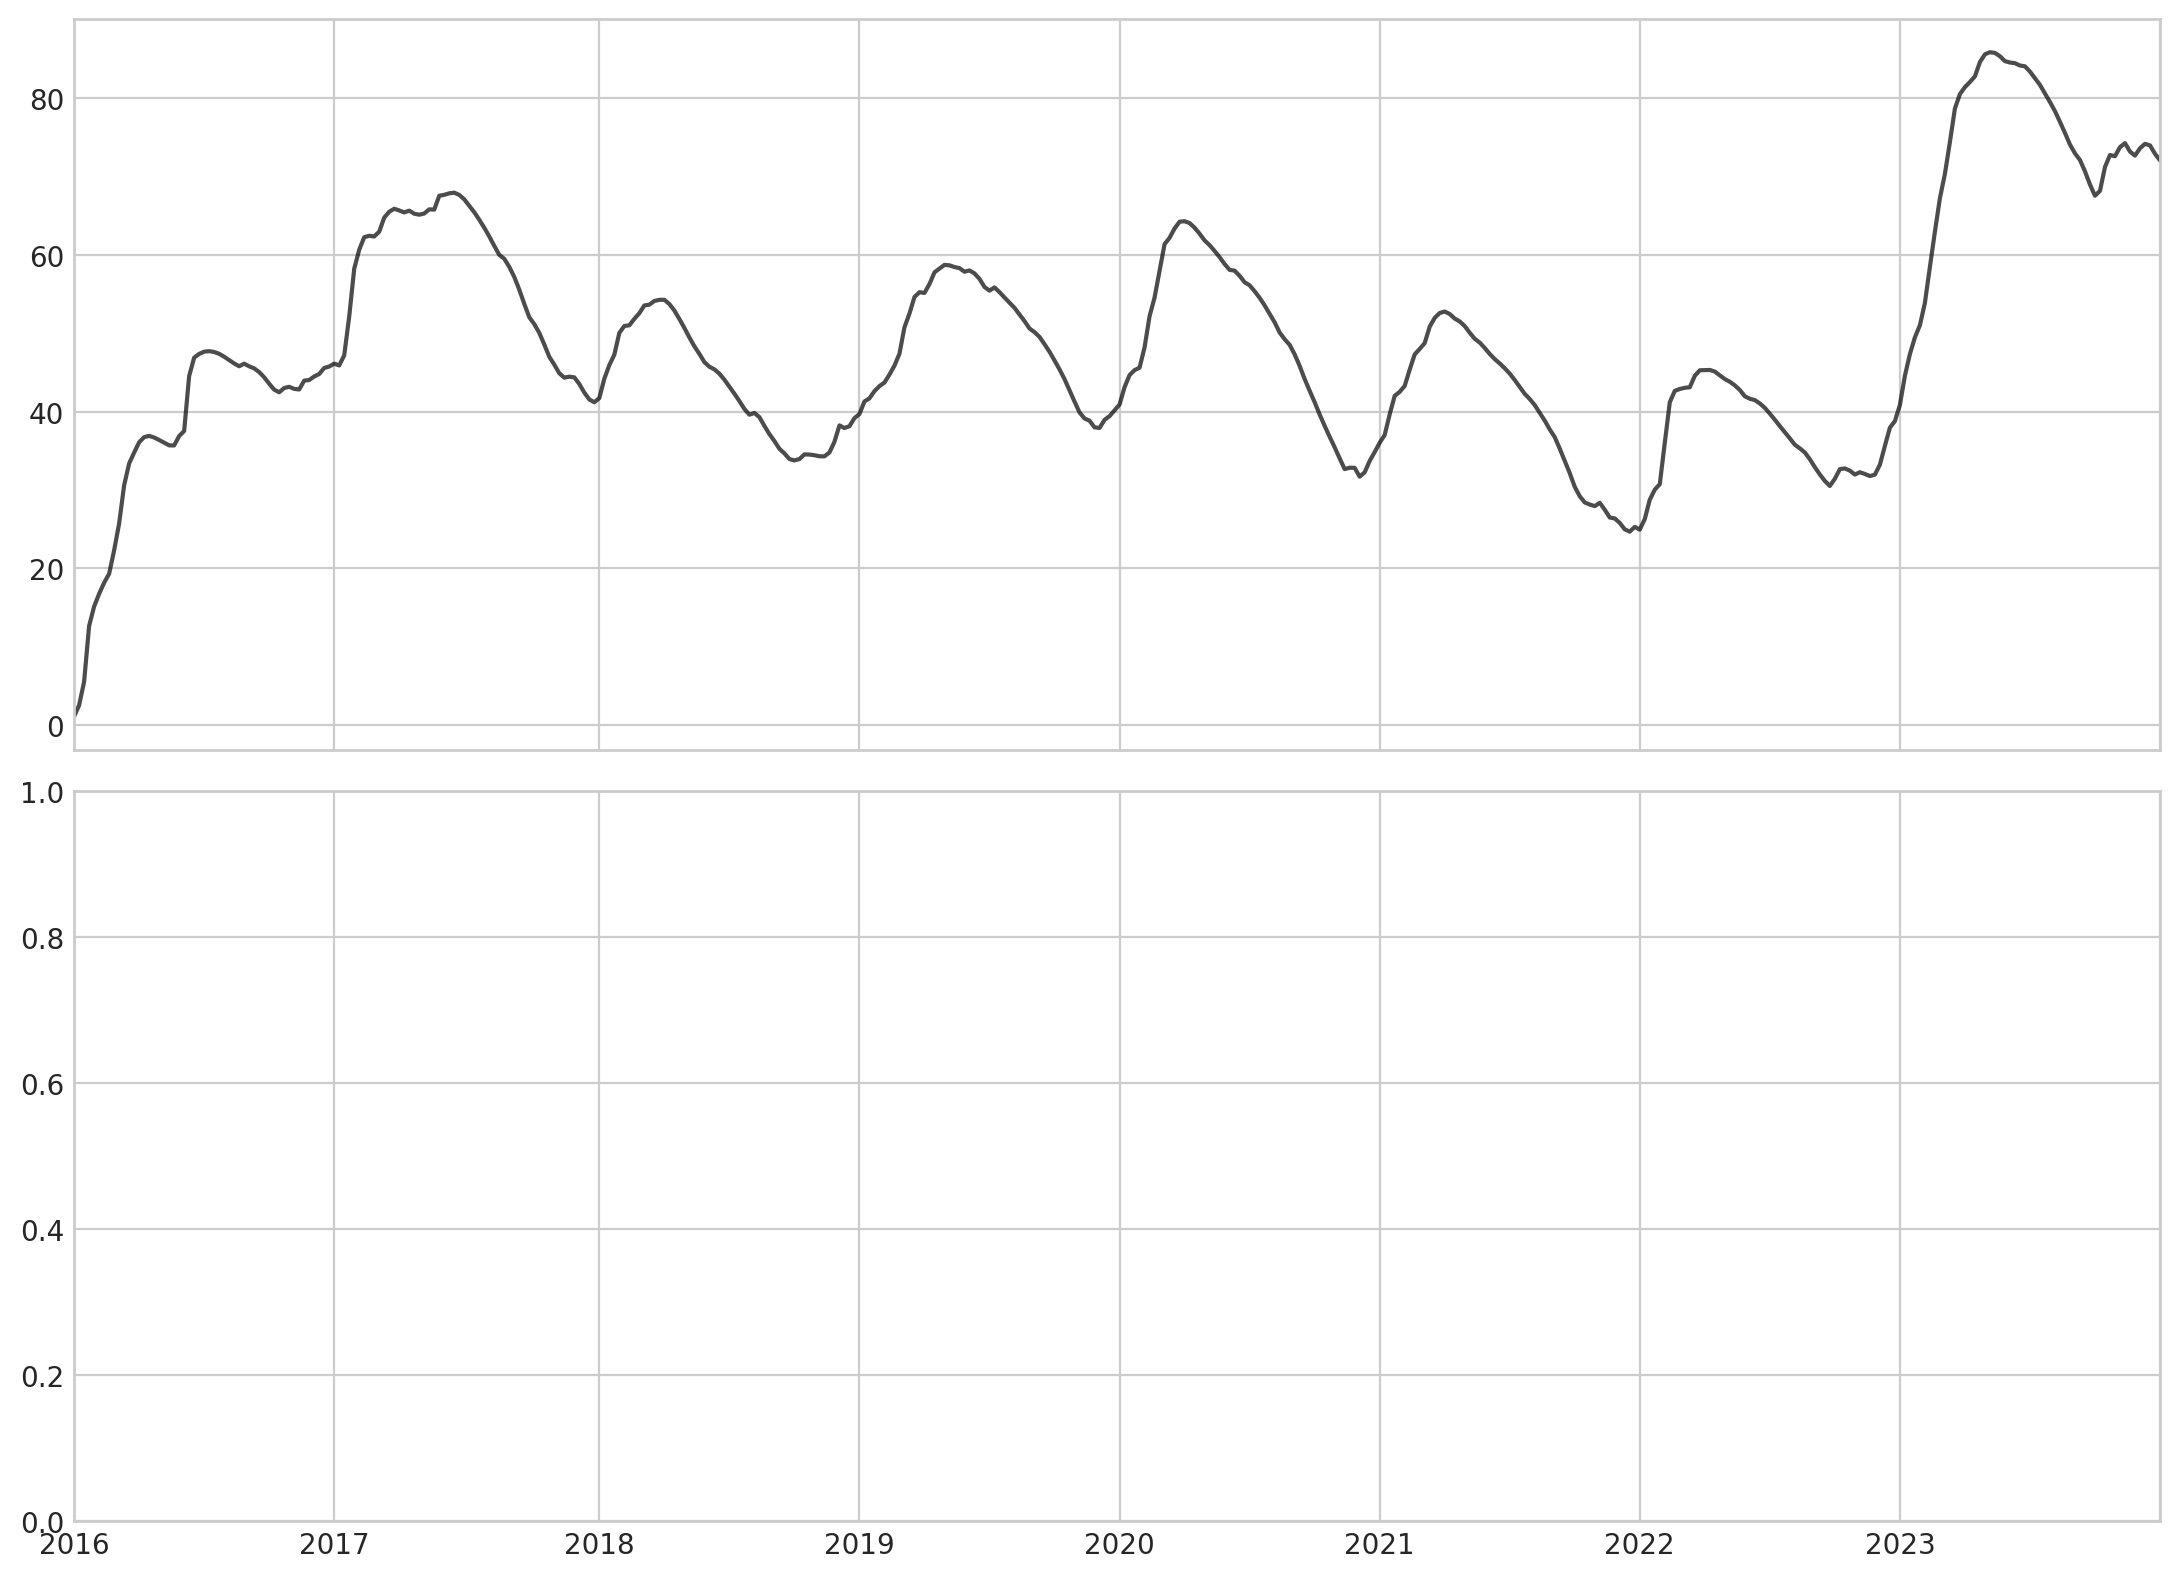

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor # Importante para MIMO

# --- 0. FUNÇÕES UTILITÁRIAS ---

# --- VERSÃO ATUALIZADA de make_lags ---
def make_lags(ts, lags, lead_time=1, name='value'): # Adicionado 'name', default 'value'
    """Cria colunas de lag com lead_time opcional e nome personalizável."""
    # Garante que ts seja uma Série para podermos pegar o nome se necessário
    if isinstance(ts, pd.DataFrame):
        # Se for um DataFrame, exige nome explícito
        if name == 'value':
             raise ValueError("Se 'ts' for DataFrame, forneça um 'name' explícito.")
        series_name = name
    elif isinstance(ts, pd.Series):
         # Usa o nome da Série se 'name' não for dado, senão usa 'name'
         series_name = name if name != 'value' else (ts.name if ts.name else 'value')
    else:
        # Se for outro tipo, exige nome explícito
        if name == 'value':
             raise ValueError("Tipo de 'ts' não suportado sem 'name' explícito.")
        series_name = name

    return pd.concat(
        # Usa o series_name para o prefixo
        {f'{series_name}_lag_{i}': ts.shift(i)
         for i in range(lead_time, lags + lead_time)},
        axis=1)
# --- FIM DA ATUALIZAÇÃO ---

# (A função make_multistep_target e plot_multistep continuam iguais)
def make_multistep_target(ts, steps):
    """Cria alvos multi-step (t+1, t+2, ..., t+steps)."""
    return pd.concat(
        {f'y_step_{i+1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)

def plot_multistep(y, every=1, ax=None, title=None, **kwargs):
    """Plota previsões multi-step."""
    ax = ax or plt.gca()
    # (Restante da função plot_multistep)
    for date, preds in y[::every].iterrows():
        style = kwargs.get('style', '.')
        color = kwargs.get('color', next(ax._get_lines.prop_cycler)['color'])
        ax.plot(
            pd.period_range(start=date, periods=len(preds)),
            preds, 
            color=color, 
            style=style, 
            label=f"Preds from {date}" if ax.get_legend() is None else None,
            **kwargs
        )
    if title:
        ax.set_title(title)
    return ax

# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base...")
# (Assumindo que df_final já existe)

split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']

# Número de passos a prever
N_STEPS = 4

# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MEDIANA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva mediana...")
# (Código para criar df_chuva_forecasts_median_direct - igual ao Exp 8)
# ... (esse código entra aqui) ...
df_train_para_mediana = df_final.loc[df_final.index < split_date].copy()
df_train_para_mediana['week_of_year'] = df_train_para_mediana.index.isocalendar().week
seasonal_median_rain = df_train_para_mediana.groupby('week_of_year')['Chuva'].median()
if 53 in seasonal_median_rain.index and 52 in seasonal_median_rain.index:
    seasonal_median_rain[53] = seasonal_median_rain[52]

# Alvos multi-step para o cenário (precisamos do formato t+1...t+N)
target_cols_scenario = [f'chuva_t+{i}' for i in range(1, N_STEPS + 1)] 
df_chuva_scenario_median = pd.DataFrame(index=test_index, columns=target_cols_scenario)
for t in test_index:
    for i in range(1, N_STEPS + 1):
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        median_value = seasonal_median_rain.get(future_week if future_week != 53 else 52, df_train_para_mediana['Chuva'].median())
        df_chuva_scenario_median.loc[t, f'chuva_t+{i}'] = median_value
df_chuva_scenario_median = df_chuva_scenario_median.astype(float)


# --- 3. MODELO 1 (LR MIMO): TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---")
print("Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...")

# Features de Tempo (X1) - Com sufixo _vol_hybrid_mimo
dp_vol_hybrid_mimo = DeterministicProcess(
    index=df_final.index, constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)], drop=True
)
X1_vol_hybrid_mimo = dp_vol_hybrid_mimo.in_sample()

# Alvo Multi-Step do Volume (y1) - Com sufixo _vol_hybrid_mimo
y1_vol_multi_hybrid_mimo = make_multistep_target(df_final['Volume_util'], steps=N_STEPS)

# Alinhar X1 e y1 multi-step
y1_vol_multi_hybrid_mimo, X1_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.align(
    X1_vol_hybrid_mimo, join='inner', axis=0
)

# Divisão Treino/Teste
X1_train_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index < split_date]
y1_train_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index < split_date]
X1_test_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index >= split_date]
y1_test_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index >= split_date]

# Treinar Modelo 1 (LR MIMO)
model1_lr_vol_hybrid_mimo = MultiOutputRegressor(LinearRegression())
model1_lr_vol_hybrid_mimo.fit(X1_train_vol_hybrid_mimo, y1_train_vol_hybrid_mimo)

# Previsões do Modelo 1 (Base LR) para treino e teste
y_pred_train_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_train_vol_hybrid_mimo),
    index=X1_train_vol_hybrid_mimo.index, columns=y1_train_vol_hybrid_mimo.columns
)
y_pred_test_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_test_vol_hybrid_mimo),
    index=X1_test_vol_hybrid_mimo.index, columns=y1_test_vol_hybrid_mimo.columns
)

# Calcular Resíduos Multi-Step (Alvo do Modelo 2)
y_res_train_vol_hybrid_mimo = y1_train_vol_hybrid_mimo - y_pred_train_lr_hybrid_mimo


# --- 4. MODELO 2 (XGB MIMO): RESÍDUOS ---
print("Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...")

# Features (X2) - Lags de Chuva REAL e Lags de Resíduo REAL
# Usamos lead_time=1 porque o alvo começa em t+1
X2_chuva_lags_hybrid_mimo = make_lags(df_final['Chuva'], lags=12, lead_time=1, name='chuva') 
# O resíduo a usar para o lag é o resíduo *original* (t), não o multi-step
# Precisamos calcular o resíduo original primeiro
y_pred_lr_single_step = pd.Series(
    LinearRegression().fit(X1_train_vol_hybrid_mimo, df_final['Volume_util'].loc[X1_train_vol_hybrid_mimo.index]).predict(X1_vol_hybrid_mimo),
    index = X1_vol_hybrid_mimo.index
)
y_res_single_step = df_final['Volume_util'] - y_pred_lr_single_step
X2_res_lags_hybrid_mimo = make_lags(y_res_single_step, lags=2, lead_time=1, name='res_vol')

# Combinar features X2
X2_vol_hybrid_mimo = pd.concat([X2_chuva_lags_hybrid_mimo, X2_res_lags_hybrid_mimo], axis=1)

# Alvo Multi-Step dos Resíduos (y2)
y2_res_multi_hybrid_mimo = make_multistep_target(y_res_single_step, steps=N_STEPS)

# Alinhar X2 e y2 multi-step
y2_res_multi_hybrid_mimo, X2_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.align(
    X2_vol_hybrid_mimo, join='inner', axis=0
)

# Divisão Treino/Teste para Modelo 2
X2_train_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index < split_date]
y2_train_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.loc[y2_res_multi_hybrid_mimo.index < split_date]
X2_test_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index >= split_date]
# y2_test_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.loc[y2_res_multi_hybrid_mimo.index >= split_date] # Não precisamos do alvo de teste aqui

# Treinar Modelo 2 (XGB MIMO)
base_xgb_mimo = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_mimo = MultiOutputRegressor(base_xgb_mimo)
model2_xgb_vol_hybrid_mimo.fit(X2_train_vol_hybrid_mimo, y2_train_vol_hybrid_mimo)

# --- PREPARAÇÃO DAS FEATURES DE TESTE PARA O XGBOOST ---
# Precisamos dos lags de chuva do cenário MEDIANA para o período de teste
rain_history_median = pd.concat([
    df_final['Chuva'].loc[df_final.index < split_date],
    df_chuva_scenario_median['chuva_t+1'].shift(1).loc[test_index] # Usa o cenário t+1
])
X2_chuva_lags_test_median = make_lags(rain_history_median, lags=12, lead_time=1, name='chuva')

# Os lags de resíduo para o teste SÃO OS REAIS do passado (não recursivo!)
X2_res_lags_test = X2_res_lags_hybrid_mimo.loc[X2_test_vol_hybrid_mimo.index] # Reusa os lags já calculados

# Combinar features de teste X2
X2_test_vol_hybrid_mimo_final = pd.concat([
    X2_chuva_lags_test_median.loc[X2_test_vol_hybrid_mimo.index], # Alinha chuva
    X2_res_lags_test # Lags de resíduo já alinhados
], axis=1).fillna(0.0) # Preenche NaNs iniciais

# --- 5. GERAR PREVISÕES FINAIS HÍBRIDAS MIMO ---
print("Passo 5: Gerando previsões finais (Híbrido MIMO)...")

# Previsões do Modelo 2 (Resíduos XGB) no treino e teste
y_pred_train_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_train_vol_hybrid_mimo),
    index=X2_train_vol_hybrid_mimo.index, columns=y2_train_vol_hybrid_mimo.columns
)
y_pred_test_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_test_vol_hybrid_mimo_final), # Usa X2 de teste com chuva mediana
    index=X2_test_vol_hybrid_mimo_final.index, columns=y2_train_vol_hybrid_mimo.columns # Usa colunas do treino
)

# Previsão Final = Previsão_LR + Previsão_XGB (alinhar índices primeiro!)
y_final_train_hybrid_mimo = y_pred_train_lr_hybrid_mimo.add(y_pred_train_xgb_hybrid_mimo, fill_value=0)
y_final_test_hybrid_mimo = y_pred_test_lr_hybrid_mimo.add(y_pred_test_xgb_hybrid_mimo, fill_value=0)

# --- 6. AVALIAÇÃO DO MODELO HÍBRIDO MIMO ---
# --- 6. AVALIAÇÃO DO MODELO HÍBRIDO MIMO (CORRIGIDO) ---
print("Passo 6: Avaliando o modelo (Híbrido MIMO)...")

# Alinhar os dados reais de teste com as previsões multi-step
y_test_truth_aligned = y1_test_vol_hybrid_mimo.loc[y_final_test_hybrid_mimo.index]

# --- INÍCIO DA CORREÇÃO ---
# Remover linhas com NaN do DataFrame de valores reais (gerados pelo shift)
# A função dropna() por padrão remove linhas se QUALQUER coluna tiver NaN
y_test_truth_clean = y_test_truth_aligned.dropna()

# Alinhar o DataFrame de previsões com o índice dos dados reais limpos
y_final_test_clean = y_final_test_hybrid_mimo.loc[y_test_truth_clean.index]
# --- FIM DA CORREÇÃO ---


# Calcular métricas para TREINO (não precisa de correção)
mae_train_mimo = mean_absolute_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo)
rmse_train_mimo = np.sqrt(mean_squared_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo))

# Calcular métricas para TESTE (usando os DataFrames limpos)
mae_test_mimo = mean_absolute_error(y_test_truth_clean, y_final_test_clean)
rmse_test_mimo = np.sqrt(mean_squared_error(y_test_truth_clean, y_final_test_clean))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)")
print("---" * 15)
print(f"TREINO - MAE: {mae_train_mimo:.2f}, RMSE: {rmse_train_mimo:.2f}")
print(f"TESTE  - MAE: {mae_test_mimo:.2f}, RMSE: {rmse_test_mimo:.2f}")
print("---" * 15)

# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

# Dados reais para plotagem
volume_real_plot = df_final['Volume_util'].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Plot Treino
volume_real_plot.loc[y_final_train_hybrid_mimo.index].plot(
    ax=ax1, label='Volume Real (Treino)', color='black', alpha=0.7
)
plot_multistep(y_final_train_hybrid_mimo, ax=ax1, every=4, color='blue', style='.-', alpha=0.5)
ax1.set_title('Previsão Híbrida MIMO - Período de Treino')
ax1.legend()

# Plot Teste
volume_real_plot.loc[y_final_test_hybrid_mimo.index].plot(
    ax=ax2, label='Volume Real (Teste)', color='black', alpha=0.7
)
plot_multistep(y_final_test_hybrid_mimo, ax=ax2, every=4, color='red', style='.-', alpha=0.5)
ax2.set_title('Previsão Híbrida MIMO - Período de Teste')
ax2.legend()

plt.xlabel("Data (Semanas)")
fig.supylabel("Volume Médio Semanal (%)") # Título Y para a figura inteira
plt.tight_layout()
plt.show()

print("--- Fim do Experimento 9 ---")

Passo 1: Preparando dados base...
Passo 2: Criando cenário de chuva mediana...

--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---
Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...
Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Treinamento do Modelo 2 (XGB MIMO) e preparação das features de teste concluídos.
Passo 5: Gerando previsões finais (Híbrido MIMO)...
Passo 6: Avaliando o modelo (Híbrido MIMO)...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)
---------------------------------------------
TREINO - MAE: 1.21, RMSE: 1.56
TESTE  - MAE: 2.16, RMSE: 2.89
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


ValueError: '.-' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

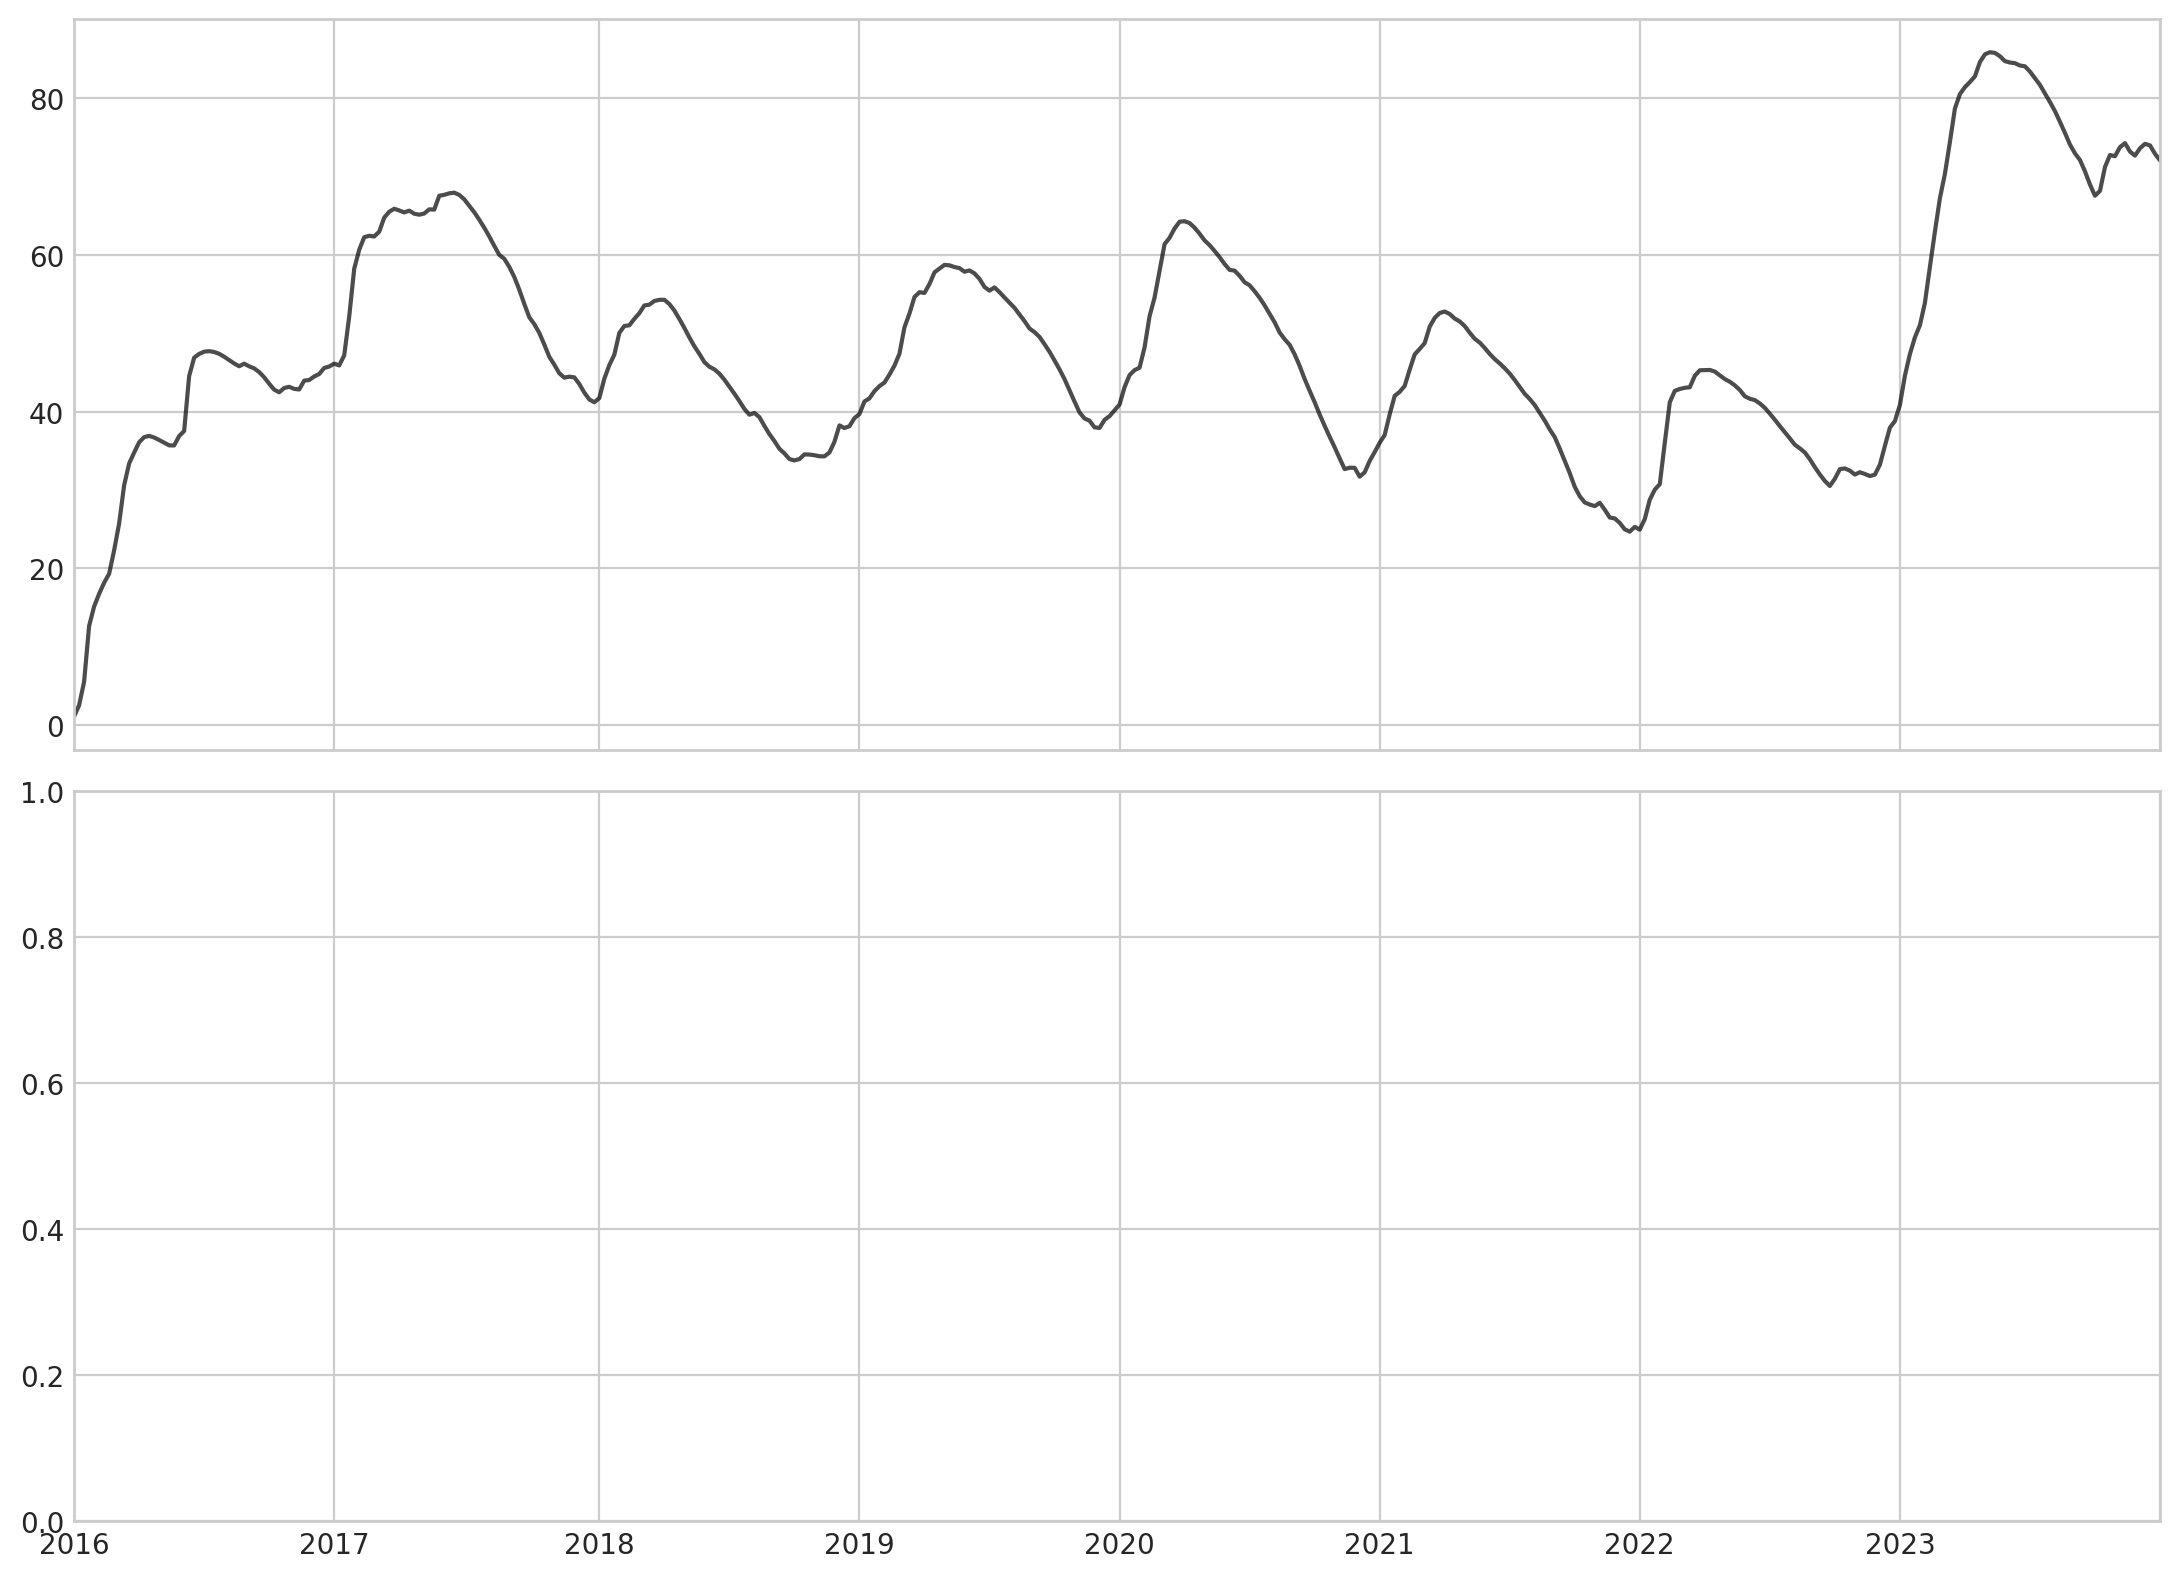

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---

# --- VERSÃO ATUALIZADA de make_lags ---
def make_lags(ts, lags, lead_time=1, name='value'):
    """Cria colunas de lag com lead_time opcional e nome personalizável."""
    if isinstance(ts, pd.DataFrame):
        if name == 'value':
             raise ValueError("Se 'ts' for DataFrame, forneça um 'name' explícito.")
        series_name = name
    elif isinstance(ts, pd.Series):
         series_name = name if name != 'value' else (ts.name if ts.name else 'value')
    else:
        if name == 'value':
             raise ValueError("Tipo de 'ts' não suportado sem 'name' explícito.")
        series_name = name
    return pd.concat(
        {f'{series_name}_lag_{i}': ts.shift(i)
         for i in range(lead_time, lags + lead_time)},
        axis=1)

def make_multistep_target(ts, steps):
    """Cria alvos multi-step (t+1, t+2, ..., t+steps)."""
    return pd.concat(
        {f'y_step_{i+1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)

# --- VERSÃO FINALMENTE CORRIGIDA da plot_multistep ---
def plot_multistep(y, every=1, ax=None, title=None, **kwargs):
    """Plota previsões multi-step (versão corrigida 2)."""
    ax = ax or plt.gca()
    # Remove color E style de kwargs, lida com eles separadamente
    color_kwarg = kwargs.pop('color', None)
    style_kwarg = kwargs.pop('style', '.') # Pega E remove style, default '.'

    for date, preds in y[::every].iterrows():
        plot_color = color_kwarg if color_kwarg else None # Usa cor fornecida ou None

        # Determina linestyle e marker a partir de style_kwarg
        linestyle = '-' # Estilo de linha padrão
        marker = None # Padrão sem marcador
        if isinstance(style_kwarg, str):
            # Tenta encontrar estilo de linha primeiro
            line_chars = ''.join(c for c in style_kwarg if c in ['-',':','.'])
            marker_chars = ''.join(c for c in style_kwarg if c not in ['-',':','.'])
            
            if line_chars: # Se encontrou estilo de linha
                linestyle = line_chars
                marker = marker_chars if marker_chars else None # Usa o resto como marcador
            elif marker_chars: # Se só encontrou marcador
                linestyle = 'None' # Sem linha
                marker = marker_chars
            # Se style_kwarg for só '-', linestyle será '-' e marker None (correto)

        ax.plot(
            pd.period_range(start=date, periods=len(preds)),
            preds,
            color=plot_color,
            linestyle=linestyle, # Usa linestyle extraído
            marker=marker, # Usa marker extraído
            label=f"Preds from {date}" if ax.get_legend() is None and not color_kwarg else None,
            **kwargs # Passa kwargs restantes (como alpha)
        )
    if title:
        ax.set_title(title)
    return ax
# --- FIM DA CORREÇÃO ---


# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base...")
# (Assumindo que df_final já existe)

split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']

N_STEPS = 4 # Número de passos à frente para prever

# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MEDIANA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva mediana...")
# (Código para criar df_chuva_scenario_median)
df_train_para_mediana = df_final.loc[df_final.index < split_date].copy()
df_train_para_mediana['week_of_year'] = df_train_para_mediana.index.isocalendar().week
seasonal_median_rain = df_train_para_mediana.groupby('week_of_year')['Chuva'].median()
if 53 in seasonal_median_rain.index and 52 in seasonal_median_rain.index:
    seasonal_median_rain[53] = seasonal_median_rain[52]

target_cols_scenario = [f'chuva_t+{i}' for i in range(1, N_STEPS + 1)]
df_chuva_scenario_median = pd.DataFrame(index=test_index, columns=target_cols_scenario)
for t in test_index:
    for i in range(1, N_STEPS + 1):
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        median_value = seasonal_median_rain.get(future_week if future_week != 53 else 52, df_train_para_mediana['Chuva'].median())
        df_chuva_scenario_median.loc[t, f'chuva_t+{i}'] = median_value
df_chuva_scenario_median = df_chuva_scenario_median.astype(float)


# --- 3. MODELO 1 (LR MIMO): TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---")
print("Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...")

# --- Sufixo _vol_hybrid_mimo ---
dp_vol_hybrid_mimo = DeterministicProcess(
    index=df_final.index, constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)], drop=True
)
X1_vol_hybrid_mimo = dp_vol_hybrid_mimo.in_sample()
y1_vol_multi_hybrid_mimo = make_multistep_target(df_final['Volume_util'], steps=N_STEPS)
y1_vol_multi_hybrid_mimo, X1_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.align(
    X1_vol_hybrid_mimo, join='inner', axis=0
)

X1_train_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index < split_date]
y1_train_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index < split_date]
X1_test_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index >= split_date]
y1_test_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index >= split_date]

model1_lr_vol_hybrid_mimo = MultiOutputRegressor(LinearRegression())
model1_lr_vol_hybrid_mimo.fit(X1_train_vol_hybrid_mimo, y1_train_vol_hybrid_mimo)

y_pred_train_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_train_vol_hybrid_mimo),
    index=X1_train_vol_hybrid_mimo.index, columns=y1_train_vol_hybrid_mimo.columns
)
y_pred_test_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_test_vol_hybrid_mimo),
    index=X1_test_vol_hybrid_mimo.index, columns=y1_test_vol_hybrid_mimo.columns
)
y_res_train_vol_hybrid_mimo = y1_train_vol_hybrid_mimo - y_pred_train_lr_hybrid_mimo


# --- 4. MODELO 2 (XGB MIMO): RESÍDUOS ---
print("Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...")

# Features X2 (Lags Chuva REAL + Lags Resíduo REAL)
X2_chuva_lags_hybrid_mimo = make_lags(df_final['Chuva'], lags=12, lead_time=1, name='chuva')
y_pred_lr_single_step = pd.Series(
    LinearRegression().fit(X1_train_vol_hybrid_mimo, df_final['Volume_util'].loc[X1_train_vol_hybrid_mimo.index]).predict(X1_vol_hybrid_mimo),
    index = X1_vol_hybrid_mimo.index
)
y_res_single_step = df_final['Volume_util'] - y_pred_lr_single_step
y_res_single_step.name = 'res_vol' # Nomear a série
X2_res_lags_hybrid_mimo = make_lags(y_res_single_step, lags=2, lead_time=1, name='res_vol')
X2_vol_hybrid_mimo = pd.concat([X2_chuva_lags_hybrid_mimo, X2_res_lags_hybrid_mimo], axis=1)

# Alvo Multi-Step dos Resíduos (y2)
y2_res_multi_hybrid_mimo = make_multistep_target(y_res_single_step, steps=N_STEPS)

# Alinhar X2 e y2
y2_res_multi_hybrid_mimo, X2_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.align(
    X2_vol_hybrid_mimo, join='inner', axis=0
)

# Divisão Treino/Teste X2
X2_train_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index < split_date]
y2_train_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.loc[y2_res_multi_hybrid_mimo.index < split_date]
X2_test_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index >= split_date]

# Treinar Modelo 2 (XGB MIMO)
base_xgb_mimo = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_mimo = MultiOutputRegressor(base_xgb_mimo)
model2_xgb_vol_hybrid_mimo.fit(X2_train_vol_hybrid_mimo, y2_train_vol_hybrid_mimo)

# Preparar Features de Teste X2 (com chuva mediana e lags de resíduo reais)
rain_history_median = pd.concat([
    df_final['Chuva'].loc[df_final.index < split_date],
    df_chuva_scenario_median['chuva_t+1'].shift(1).loc[test_index]
])
X2_chuva_lags_test_median = make_lags(rain_history_median, lags=12, lead_time=1, name='chuva')
X2_res_lags_test = X2_res_lags_hybrid_mimo.loc[X2_test_vol_hybrid_mimo.index]
X2_test_vol_hybrid_mimo_final = pd.concat([
    X2_chuva_lags_test_median.loc[X2_test_vol_hybrid_mimo.index],
    X2_res_lags_test
], axis=1).fillna(0.0)

print("Treinamento do Modelo 2 (XGB MIMO) e preparação das features de teste concluídos.")


# --- 5. GERAR PREVISÕES FINAIS HÍBRIDAS MIMO ---
print("Passo 5: Gerando previsões finais (Híbrido MIMO)...")

y_pred_train_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_train_vol_hybrid_mimo),
    index=X2_train_vol_hybrid_mimo.index, columns=y2_train_vol_hybrid_mimo.columns
)
y_pred_test_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_test_vol_hybrid_mimo_final),
    index=X2_test_vol_hybrid_mimo_final.index, columns=y2_train_vol_hybrid_mimo.columns
)

y_final_train_hybrid_mimo = y_pred_train_lr_hybrid_mimo.add(y_pred_train_xgb_hybrid_mimo, fill_value=0)
y_final_test_hybrid_mimo = y_pred_test_lr_hybrid_mimo.add(y_pred_test_xgb_hybrid_mimo, fill_value=0)

# --- 6. AVALIAÇÃO DO MODELO HÍBRIDO MIMO (CORRIGIDO) ---
print("Passo 6: Avaliando o modelo (Híbrido MIMO)...")

y_test_truth_aligned = y1_test_vol_hybrid_mimo.loc[y_final_test_hybrid_mimo.index]
y_test_truth_clean = y_test_truth_aligned.dropna()
y_final_test_clean = y_final_test_hybrid_mimo.loc[y_test_truth_clean.index]

mae_train_mimo = mean_absolute_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo)
rmse_train_mimo = np.sqrt(mean_squared_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo))
mae_test_mimo = mean_absolute_error(y_test_truth_clean, y_final_test_clean)
rmse_test_mimo = np.sqrt(mean_squared_error(y_test_truth_clean, y_final_test_clean))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)")
print("---" * 15)
print(f"TREINO - MAE: {mae_train_mimo:.2f}, RMSE: {rmse_train_mimo:.2f}")
print(f"TESTE  - MAE: {mae_test_mimo:.2f}, RMSE: {rmse_test_mimo:.2f}")
print("---" * 15)

# --- 7. VISUALIZAÇÃO FINAL ---
print("Passo 7: Gerando gráfico de resultados...")

volume_real_plot = df_final['Volume_util'].copy()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Plot Treino
volume_real_plot.loc[y_final_train_hybrid_mimo.index].plot(
    ax=ax1, label='Volume Real (Treino)', color='black', alpha=0.7
)
plot_multistep(y_final_train_hybrid_mimo, ax=ax1, every=4, color='blue', style='.-', alpha=0.5)
ax1.set_title('Previsão Híbrida MIMO - Período de Treino')
ax1.legend()

# Plot Teste
volume_real_plot.loc[y_final_test_hybrid_mimo.index].plot(
    ax=ax2, label='Volume Real (Teste)', color='black', alpha=0.7
)
plot_multistep(y_final_test_hybrid_mimo, ax=ax2, every=4, color='red', style='.-', alpha=0.5)
ax2.set_title('Previsão Híbrida MIMO - Período de Teste')
ax2.legend()

plt.xlabel("Data (Semanas)")
fig.supylabel("Volume Médio Semanal (%)")
plt.tight_layout()
plt.show()

print("--- Fim do Experimento 9 ---")

Passo 1: Preparando dados base...
Passo 2: Criando cenário de chuva mediana...

--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---
Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...
Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...


/home/jefferson_correia/tcc/venv/lib/python3.12/site-packages/statsmodels/tsa/deterministic.py:569: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



Treinamento do Modelo 2 (XGB MIMO) e preparação das features de teste concluídos.
Passo 5: Gerando previsões finais (Híbrido MIMO)...
Passo 6: Avaliando o modelo (Híbrido MIMO)...

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)
---------------------------------------------
TREINO - MAE: 1.21, RMSE: 1.56
TESTE  - MAE: 2.16, RMSE: 2.89
---------------------------------------------
Passo 7: Gerando gráfico de resultados...


/tmp/ipykernel_424148/2402371419.py:86: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter

/tmp/ipykernel_424148/2402371419.py:86: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



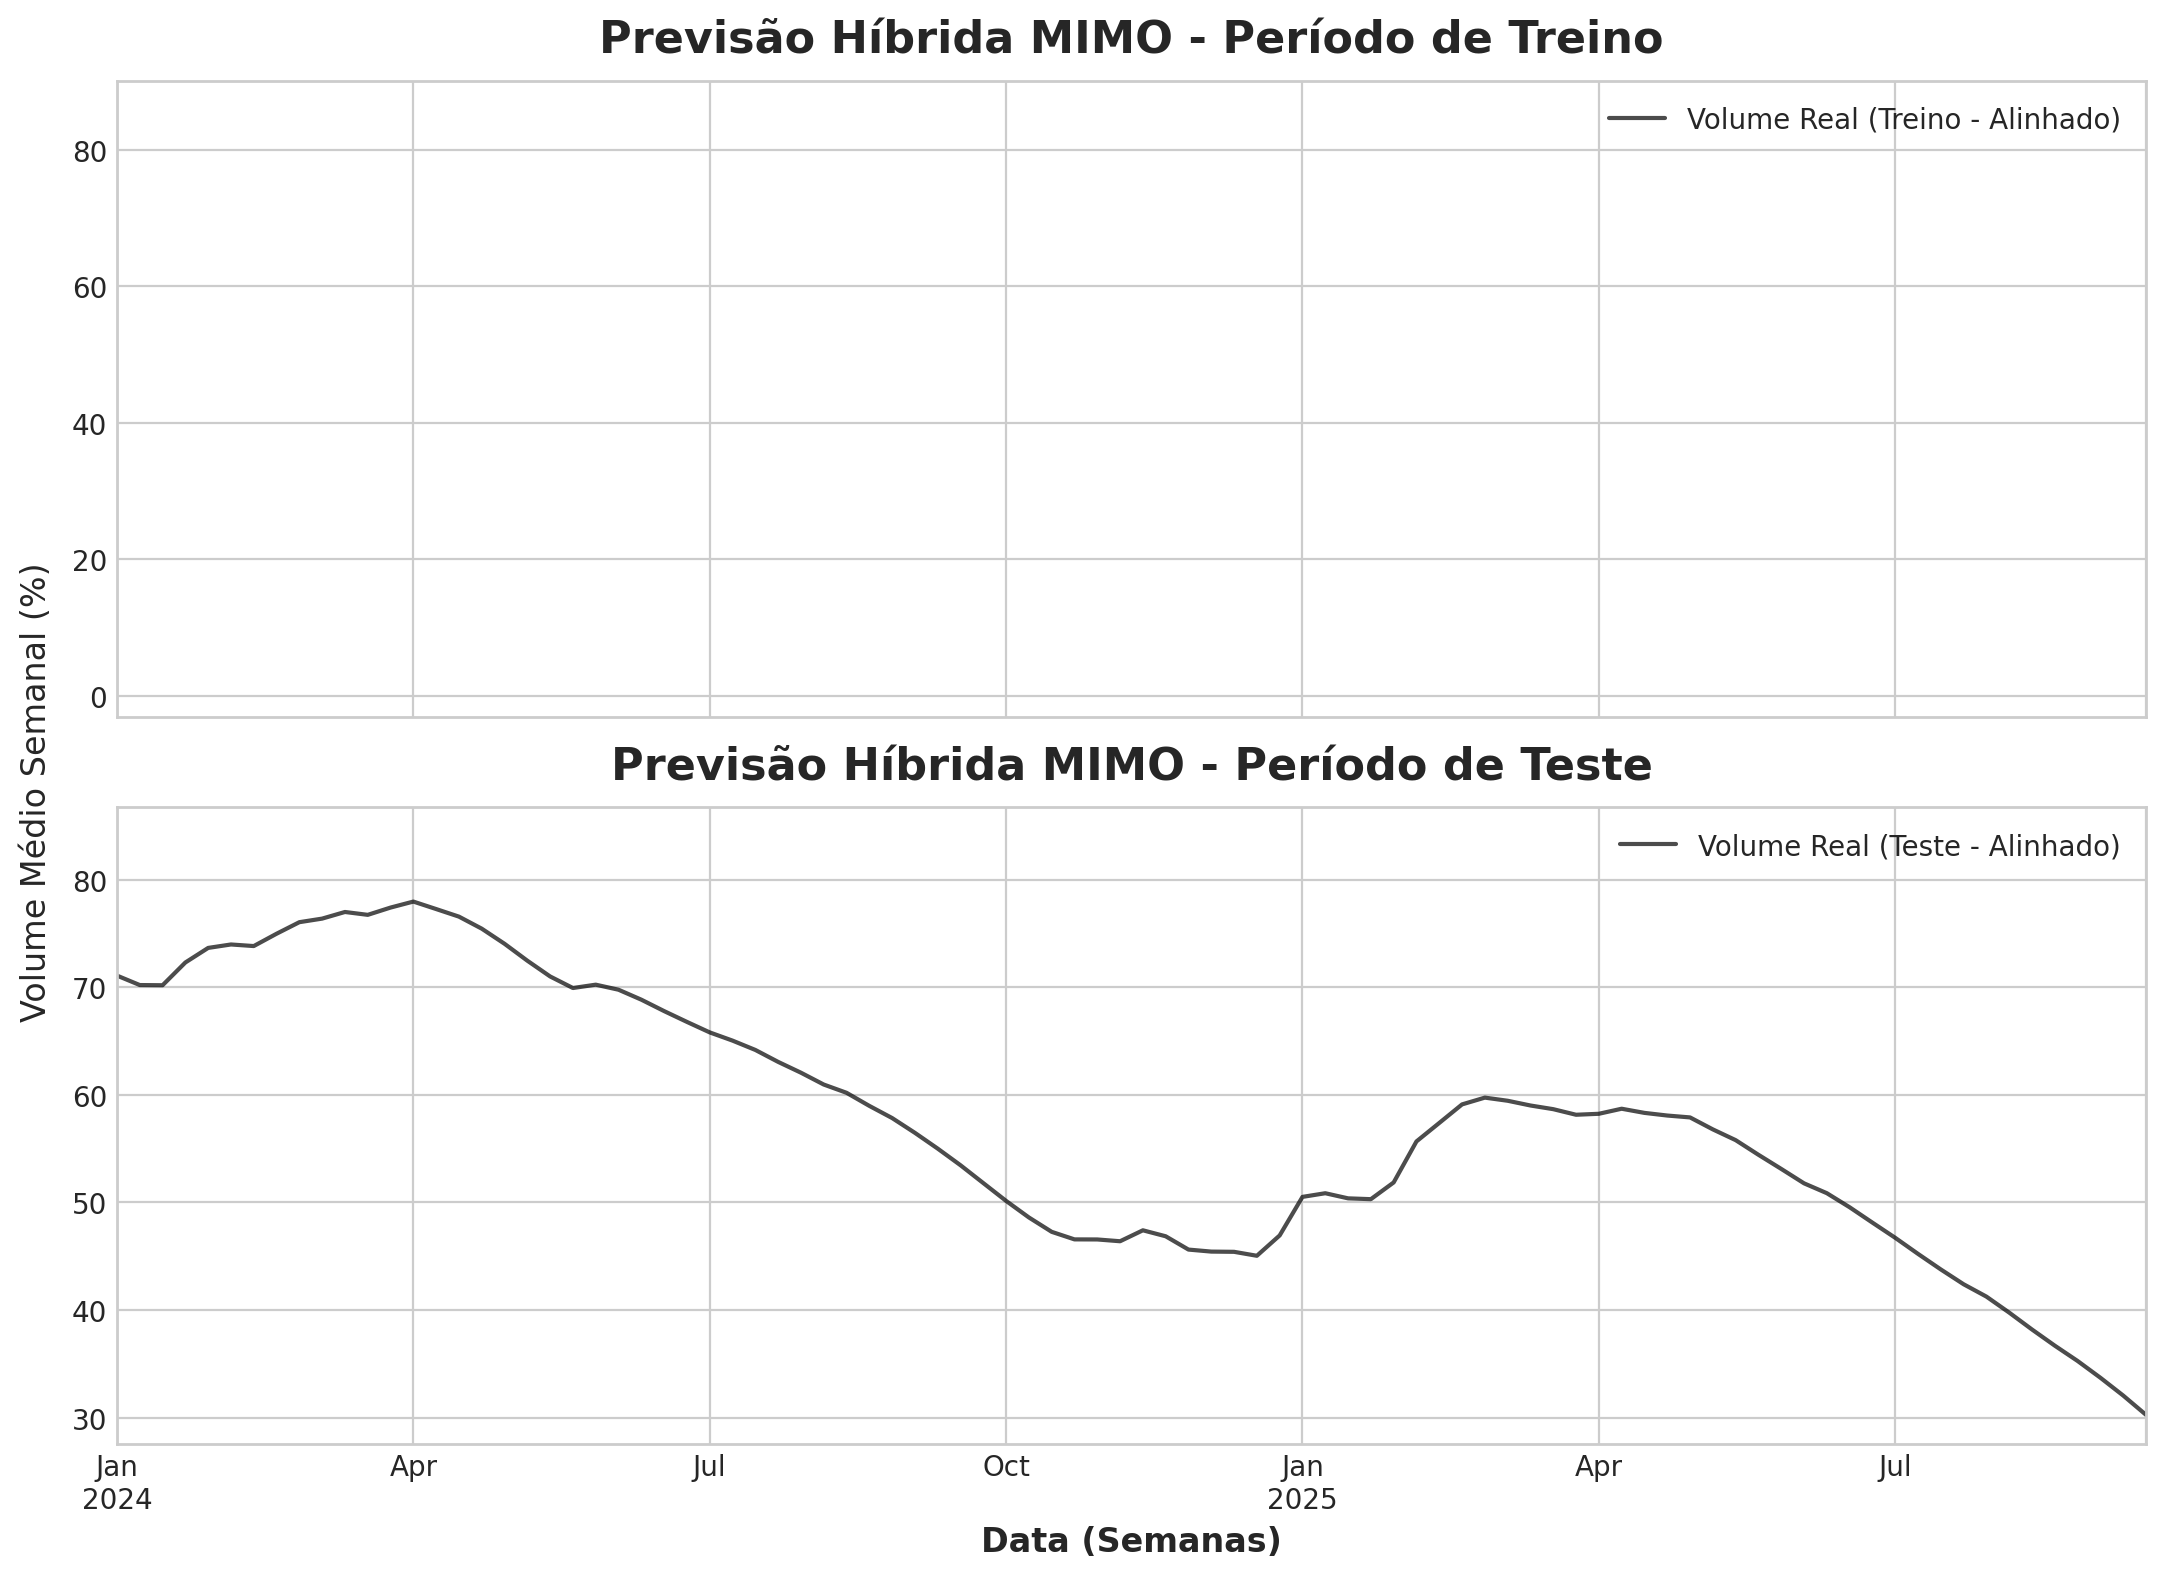

--- Fim do Experimento 9 ---


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# --- 0. FUNÇÕES UTILITÁRIAS ---

# (make_lags e make_multistep_target continuam iguais)
def make_lags(ts, lags, lead_time=1, name='value'):
    """Cria colunas de lag com lead_time opcional e nome personalizável."""
    if isinstance(ts, pd.DataFrame):
        if name == 'value':
             raise ValueError("Se 'ts' for DataFrame, forneça um 'name' explícito.")
        series_name = name
    elif isinstance(ts, pd.Series):
         series_name = name if name != 'value' else (ts.name if ts.name else 'value')
    else:
        if name == 'value':
             raise ValueError("Tipo de 'ts' não suportado sem 'name' explícito.")
        series_name = name
    return pd.concat(
        {f'{series_name}_lag_{i}': ts.shift(i)
         for i in range(lead_time, lags + lead_time)},
        axis=1)

def make_multistep_target(ts, steps):
    """Cria alvos multi-step (t+1, t+2, ..., t+steps)."""
    return pd.concat(
        {f'y_step_{i+1}': ts.shift(-i)
         for i in range(steps)},
        axis=1)

# --- plot_multistep CORRIGIDA PARA USAR date_range ---
def plot_multistep(y, every=1, ax=None, title=None, **kwargs):
    """Plota previsões multi-step (versão corrigida 5 - date_range)."""
    ax = ax or plt.gca()
    color_kwarg = kwargs.pop('color', None)
    style_kwarg = kwargs.pop('style', None)

    linestyle = '-'
    marker = None

    # (Lógica para separar style em linestyle/marker continua a mesma)
    if isinstance(style_kwarg, str):
        valid_linestyles = ['--', '-.', ':', '-']
        valid_markers = ['.', 'o', 'v', '^', '<', '>', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_']
        found_ls = None
        for ls_candidate in valid_linestyles:
            if style_kwarg.startswith(ls_candidate):
                found_ls = ls_candidate
                break
        if found_ls:
            linestyle = found_ls
            marker_part = style_kwarg[len(found_ls):]
            if marker_part in valid_markers:
                marker = marker_part
        elif style_kwarg in valid_markers:
             linestyle = 'None'
             marker = style_kwarg
    elif style_kwarg is None:
        linestyle = '-'
        marker = None

    # --- CORREÇÃO PRINCIPAL ---
    # Obter a frequência do índice ANTES do loop
    try:
        index_freq = y.index.freqstr # Ex: 'W-SUN'
        if not index_freq: # Se freqstr for None, tenta inferir
             index_freq = pd.infer_freq(y.index)
    except AttributeError: # Se o índice não tiver freqstr (raro)
        index_freq = 'W' # Assume semanal como fallback
        print("Aviso: Não foi possível determinar a frequência do índice, assumindo 'W'.")
    # --- FIM DA CORREÇÃO ---
        
    for date, preds in y[::every].iterrows():
        plot_color = color_kwarg if color_kwarg else None

        # --- USA pd.date_range com a frequência do índice ---
        x_dates = pd.date_range(start=date, periods=len(preds), freq=index_freq)
        # --- FIM DA CORREÇÃO ---

        ax.plot(
            x_dates, # Usa o date_range de Timestamps
            preds.values, # Passa apenas os valores
            color=plot_color,
            linestyle=linestyle,
            marker=marker,
            label=f"Preds from {date}" if ax.get_legend() is None and not color_kwarg else None,
            **kwargs
        )
    if title:
        ax.set_title(title)
    return ax
# --- FIM DA CORREÇÃO ---


# --- 1. PREPARAÇÃO DOS DADOS BASE (VOLUME E CHUVA REAL) ---
print("Passo 1: Preparando dados base...")
# (Assumindo que df_final já existe)

split_date = '2024-01-01'
test_index = df_final.loc[df_final.index >= split_date].index
y_test_truth_volume = df_final.loc[test_index, 'Volume_util']

N_STEPS = 4 # Número de passos à frente para prever

# --- 2. CRIAÇÃO DO CENÁRIO DE CHUVA (MEDIANA HISTÓRICA) ---
print("Passo 2: Criando cenário de chuva mediana...")
# (Código para criar df_chuva_scenario_median)
df_train_para_mediana = df_final.loc[df_final.index < split_date].copy()
df_train_para_mediana['week_of_year'] = df_train_para_mediana.index.isocalendar().week
seasonal_median_rain = df_train_para_mediana.groupby('week_of_year')['Chuva'].median()
if 53 in seasonal_median_rain.index and 52 in seasonal_median_rain.index:
    seasonal_median_rain[53] = seasonal_median_rain[52]

target_cols_scenario = [f'chuva_t+{i}' for i in range(1, N_STEPS + 1)]
df_chuva_scenario_median = pd.DataFrame(index=test_index, columns=target_cols_scenario)
for t in test_index:
    for i in range(1, N_STEPS + 1):
        future_date = t + pd.Timedelta(weeks=i)
        future_week = future_date.isocalendar().week
        median_value = seasonal_median_rain.get(future_week if future_week != 53 else 52, df_train_para_mediana['Chuva'].median())
        df_chuva_scenario_median.loc[t, f'chuva_t+{i}'] = median_value
df_chuva_scenario_median = df_chuva_scenario_median.astype(float)


# --- 3. MODELO 1 (LR MIMO): TENDÊNCIA/SAZONALIDADE DO VOLUME ---
print("\n--- Início do Experimento 9: Modelo Híbrido MIMO (Chuva Mediana) ---")
print("Passo 3: Preparando dados e treinando Modelo 1 (LR MIMO)...")

# --- Sufixo _vol_hybrid_mimo ---
dp_vol_hybrid_mimo = DeterministicProcess(
    index=df_final.index, constant=True, order=1,
    additional_terms=[CalendarFourier(freq="A", order=4)], drop=True
)
X1_vol_hybrid_mimo = dp_vol_hybrid_mimo.in_sample()
y1_vol_multi_hybrid_mimo = make_multistep_target(df_final['Volume_util'], steps=N_STEPS)
y1_vol_multi_hybrid_mimo, X1_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.align(
    X1_vol_hybrid_mimo, join='inner', axis=0
)

X1_train_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index < split_date]
y1_train_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index < split_date]
X1_test_vol_hybrid_mimo = X1_vol_hybrid_mimo.loc[X1_vol_hybrid_mimo.index >= split_date]
y1_test_vol_hybrid_mimo = y1_vol_multi_hybrid_mimo.loc[y1_vol_multi_hybrid_mimo.index >= split_date]

model1_lr_vol_hybrid_mimo = MultiOutputRegressor(LinearRegression())
model1_lr_vol_hybrid_mimo.fit(X1_train_vol_hybrid_mimo, y1_train_vol_hybrid_mimo)

y_pred_train_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_train_vol_hybrid_mimo),
    index=X1_train_vol_hybrid_mimo.index, columns=y1_train_vol_hybrid_mimo.columns
)
y_pred_test_lr_hybrid_mimo = pd.DataFrame(
    model1_lr_vol_hybrid_mimo.predict(X1_test_vol_hybrid_mimo),
    index=X1_test_vol_hybrid_mimo.index, columns=y1_test_vol_hybrid_mimo.columns
)
y_res_train_vol_hybrid_mimo = y1_train_vol_hybrid_mimo - y_pred_train_lr_hybrid_mimo


# --- 4. MODELO 2 (XGB MIMO): RESÍDUOS ---
print("Passo 4: Preparando dados e treinando Modelo 2 (XGB MIMO)...")

# Features X2 (Lags Chuva REAL + Lags Resíduo REAL)
X2_chuva_lags_hybrid_mimo = make_lags(df_final['Chuva'], lags=12, lead_time=1, name='chuva')
y_pred_lr_single_step = pd.Series(
    LinearRegression().fit(X1_train_vol_hybrid_mimo, df_final['Volume_util'].loc[X1_train_vol_hybrid_mimo.index]).predict(X1_vol_hybrid_mimo),
    index = X1_vol_hybrid_mimo.index
)
y_res_single_step = df_final['Volume_util'] - y_pred_lr_single_step
y_res_single_step.name = 'res_vol' # Nomear a série
X2_res_lags_hybrid_mimo = make_lags(y_res_single_step, lags=2, lead_time=1, name='res_vol')
X2_vol_hybrid_mimo = pd.concat([X2_chuva_lags_hybrid_mimo, X2_res_lags_hybrid_mimo], axis=1)

# Alvo Multi-Step dos Resíduos (y2)
y2_res_multi_hybrid_mimo = make_multistep_target(y_res_single_step, steps=N_STEPS)

# Alinhar X2 e y2
y2_res_multi_hybrid_mimo, X2_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.align(
    X2_vol_hybrid_mimo, join='inner', axis=0
)

# Divisão Treino/Teste X2
X2_train_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index < split_date]
y2_train_vol_hybrid_mimo = y2_res_multi_hybrid_mimo.loc[y2_res_multi_hybrid_mimo.index < split_date]
X2_test_vol_hybrid_mimo = X2_vol_hybrid_mimo.loc[X2_vol_hybrid_mimo.index >= split_date]

# Treinar Modelo 2 (XGB MIMO)
base_xgb_mimo = XGBRegressor(n_estimators=50, learning_rate=0.05, max_depth=5, random_state=0)
model2_xgb_vol_hybrid_mimo = MultiOutputRegressor(base_xgb_mimo)
model2_xgb_vol_hybrid_mimo.fit(X2_train_vol_hybrid_mimo, y2_train_vol_hybrid_mimo)

# Preparar Features de Teste X2 (com chuva mediana e lags de resíduo reais)
rain_history_median = pd.concat([
    df_final['Chuva'].loc[df_final.index < split_date],
    df_chuva_scenario_median['chuva_t+1'].shift(1).loc[test_index]
])
X2_chuva_lags_test_median = make_lags(rain_history_median, lags=12, lead_time=1, name='chuva')
X2_res_lags_test = X2_res_lags_hybrid_mimo.loc[X2_test_vol_hybrid_mimo.index]
X2_test_vol_hybrid_mimo_final = pd.concat([
    X2_chuva_lags_test_median.loc[X2_test_vol_hybrid_mimo.index],
    X2_res_lags_test
], axis=1).fillna(0.0)

print("Treinamento do Modelo 2 (XGB MIMO) e preparação das features de teste concluídos.")


# --- 5. GERAR PREVISÕES FINAIS HÍBRIDAS MIMO ---
print("Passo 5: Gerando previsões finais (Híbrido MIMO)...")

y_pred_train_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_train_vol_hybrid_mimo),
    index=X2_train_vol_hybrid_mimo.index, columns=y2_train_vol_hybrid_mimo.columns
)
y_pred_test_xgb_hybrid_mimo = pd.DataFrame(
    model2_xgb_vol_hybrid_mimo.predict(X2_test_vol_hybrid_mimo_final),
    index=X2_test_vol_hybrid_mimo_final.index, columns=y2_train_vol_hybrid_mimo.columns
)

y_final_train_hybrid_mimo = y_pred_train_lr_hybrid_mimo.add(y_pred_train_xgb_hybrid_mimo, fill_value=0)
y_final_test_hybrid_mimo = y_pred_test_lr_hybrid_mimo.add(y_pred_test_xgb_hybrid_mimo, fill_value=0)

# --- 6. AVALIAÇÃO DO MODELO HÍBRIDO MIMO (CORRIGIDO) ---
print("Passo 6: Avaliando o modelo (Híbrido MIMO)...")

y_test_truth_aligned = y1_test_vol_hybrid_mimo.loc[y_final_test_hybrid_mimo.index]
y_test_truth_clean = y_test_truth_aligned.dropna()
y_final_test_clean = y_final_test_hybrid_mimo.loc[y_test_truth_clean.index]

mae_train_mimo = mean_absolute_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo)
rmse_train_mimo = np.sqrt(mean_squared_error(y1_train_vol_hybrid_mimo, y_final_train_hybrid_mimo))
mae_test_mimo = mean_absolute_error(y_test_truth_clean, y_final_test_clean)
rmse_test_mimo = np.sqrt(mean_squared_error(y_test_truth_clean, y_final_test_clean))

print("\n---" * 15)
print("   Resultado do Modelo Híbrido MIMO com Chuva Mediana (Experimento 9)")
print("---" * 15)
print(f"TREINO - MAE: {mae_train_mimo:.2f}, RMSE: {rmse_train_mimo:.2f}")
print(f"TESTE  - MAE: {mae_test_mimo:.2f}, RMSE: {rmse_test_mimo:.2f}")
print("---" * 15)

# --- 7. VISUALIZAÇÃO FINAL (CORRIGIDA PARA ALINHAMENTO) ---
print("Passo 7: Gerando gráfico de resultados...")

# (volume_real_plot não é mais necessário aqui)
# volume_real_plot = df_final['Volume_util'].copy() 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# --- Plot Treino ---
# Usamos y1_train_vol_hybrid_mimo['y_step_1'] como a "verdade" alinhada para o treino
# (y_step_1 representa a previsão de 1 passo à frente, que é o mais próximo do real t+1)
try:
    y1_train_truth_plot = y1_train_vol_hybrid_mimo['y_step_1']
    y1_train_truth_plot.plot(
        ax=ax1, label='Volume Real (Treino - Alinhado)', color='black', alpha=0.7
    )
    plot_multistep(y_final_train_hybrid_mimo, ax=ax1, every=4, color='blue', style='.-', alpha=0.5)
except Exception as e:
    print(f"Erro ao plotar dados de treino: {e}")
    # Plota apenas as previsões se a verdade falhar
    plot_multistep(y_final_train_hybrid_mimo, ax=ax1, every=4, color='blue', style='.-', alpha=0.5)
    
ax1.set_title('Previsão Híbrida MIMO - Período de Treino')
ax1.legend()


# --- Plot Teste ---
# Usamos y_test_truth_clean['y_step_1'] como a "verdade" alinhada e limpa para o teste
try:
    y_test_truth_plot = y_test_truth_clean['y_step_1']
    y_test_truth_plot.plot(
        ax=ax2, label='Volume Real (Teste - Alinhado)', color='black', alpha=0.7
    )
    # Usamos y_final_test_clean que também foi limpo de NaNs na avaliação
    plot_multistep(y_final_test_clean, ax=ax2, every=4, color='red', style='.-', alpha=0.5) 
except Exception as e:
    print(f"Erro ao plotar dados de teste: {e}")
    # Plota apenas as previsões se a verdade falhar
    plot_multistep(y_final_test_clean, ax=ax2, every=4, color='red', style='.-', alpha=0.5)

ax2.set_title('Previsão Híbrida MIMO - Período de Teste')
ax2.legend()

plt.xlabel("Data (Semanas)")
fig.supylabel("Volume Médio Semanal (%)")
plt.tight_layout()
plt.show()

print("--- Fim do Experimento 9 ---")